# 3 — Quantum Ising 1D y 2D

El Hamiltoniano de Ising cuántico,

$$
H_S = -J\!\sum_{\langle i,j\rangle}\hat X_i\hat X_j - g\sum_i \hat Z_i,
$$

introduce correlaciones genuinas entre qubits que el modelo no-interactuante no tiene: el Gibbs ya no factoriza, la información mutua entre subsistemas es positiva, y aparecen transiciones de fase. En 1D hay transición cuántica en $|J|=g$ a $T\to 0$ pero no hay transición térmica para $\beta$ finito. En 2D hay transición térmica a $\beta_c \approx 0.44/J$ (Onsager, $g\to 0$) y cuántica a $J_c \approx 0.33g$ ($\beta\to\infty$).

Esto convierte al Ising en el caso donde el protocolo se juega de verdad: tiene que preparar un estado con correlaciones no-triviales, no simplemente un producto de estados independientes.

- **A.** Capa exacta NumPy — convergencia, escalado $\theta^2$, operadores, geometría del baño, resonancias, Mpemba, termodinámica.
- **B.** Qiskit ideal — validación 1D y 2D contra exacto NumPy.
- **C.** Shots ISA en `FakeSherbrooke` — circuitos dinámicos con medida del baño.
- **D.** Ruido calibrado — frontera NISQ Ising 1D vs 2D.

In [1]:
# Add the project source tree to Python's import path
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("Project root:", PROJECT_ROOT)
print("Source:", SRC)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import time

from tfm_shared.core import *
from tfm_shared.plots import *
from tfm_shared.qiskit_impl import *
from tfm_ising.model import *

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.dpi"] = 120

Project root: C:\Users\paula\Desktop\tfm
Funciones Qiskit cargadas.


## Parámetros base

Elegimos parámetros "sweet spot" consistentes con los análisis anteriores (NB01, NB02):

- $g = 1$, fijo como escala.
- $h = \max(2g, 4J)$ para que el filtro gaussiano cubra los gaps típicos del espectro.
- $\theta = 0.25$ (perturbativo pero con convergencia rápida).
- $M_T$ elegido para evitar resonancias: en el análisis de NB02 el valle $T\omega/\pi \approx 1.5$ corresponde a $M_T \approx 60$ con $\delta=\pi/40$. Aquí bajamos un poco para tener runs manejables en Ising 2D ($M_T=40$), sabiendo que introducimos algo más de sesgo del que sería óptimo.
- $\delta = \pi/40$ (pequeño, evita errores de Trotter).

En las celdas específicas de convergencia y escalado $\theta^2$ **usamos valores más pequeños** ($M_T\approx 10$, $n\_cycles\approx 30$) para que los runs acaben rápido; en las celdas de reproducción del paper **subimos** a valores cercanos a los suyos.


In [2]:
# Parámetros base para Ising
BETA_BASE = 1.0
G_BASE = 1.0

def make_params_1d(Lx, J, beta=BETA_BASE, MT=10, n_cycles=30, theta=0.25):
    return dict(
        Lx=int(Lx), Ly=1,
        J=float(J), g=G_BASE,
        h=max(2*G_BASE, 4*J),
        beta=float(beta),
        theta=float(theta),
        delta=np.pi/40,
        MT=int(MT),
        n_cycles=int(n_cycles),
        sys_A="Y", bath_A="Y",
    )

def make_params_2d(Lx, Ly, J, beta=BETA_BASE, MT=10, n_cycles=30, theta=0.25):
    return dict(
        Lx=int(Lx), Ly=int(Ly),
        J=float(J), g=G_BASE,
        h=max(2*G_BASE, 4*J),
        beta=float(beta),
        theta=float(theta),
        delta=np.pi/40,
        MT=int(MT),
        n_cycles=int(n_cycles),
        sys_A="Y", bath_A="Y",
    )

print("ejemplo 1D N=3, J=0.5:")
print(make_params_1d(3, 0.5))
print("\nejemplo 2D 2x2, J=0.5:")
print(make_params_2d(2, 2, 0.5))


ejemplo 1D N=3, J=0.5:
{'Lx': 3, 'Ly': 1, 'J': 0.5, 'g': 1.0, 'h': 2.0, 'beta': 1.0, 'theta': 0.25, 'delta': 0.07853981633974483, 'MT': 10, 'n_cycles': 30, 'sys_A': 'Y', 'bath_A': 'Y'}

ejemplo 2D 2x2, J=0.5:
{'Lx': 2, 'Ly': 2, 'J': 0.5, 'g': 1.0, 'h': 2.0, 'beta': 1.0, 'theta': 0.25, 'delta': 0.07853981633974483, 'MT': 10, 'n_cycles': 30, 'sys_A': 'Y', 'bath_A': 'Y'}


# A. Capa numpy exacta

Con matrices densas y evolución exacta del canal **verificamos que el protocolo converge al Gibbs en Ising 1D y 2D** y caracterizamos el sesgo.

Los cálculos escalan como $\mathrm{dim}(\mathcal{H}_S)^2 = 4^{N_S}$ para el estado del sistema y como $4^{N_S} \times 4^{N_B}$ en las capas intermedias. En este notebook:

- **1D**: $N_S \in \{2, 3, 4\}$ manejable con `fp_mode="superop"`.
- **1D grande**: $N_S=5$ aún cabe pero el superop empieza a costar. Usamos `late_time`.
- **2D**: $2\times 2 = 4$ qubits (cabe), $3\times 3 = 9$ qubits (ya es costoso, usar `late_time`), $4\times 4 = 16$ qubits (no cabe en superop, **late_time** obligatorio con trayectoria larga).


## A.1 Ising 1D — convergencia y caracterización

Empezamos con la cadena 1D, el caso tratable exactamente vía superoperador hasta $N_S \sim 5$. Seguimos el mismo esquema que NB01 y NB02: convergencia desde varios $\rho_0$, escalado $\theta^2$ del sesgo, y colapso de trayectorias reescaladas.

### A.1.1 Convergencia 1D desde varios estados iniciales

Lanzamos el canal desde tres condiciones iniciales muy distintas — $I/d$, $|+\rangle^{\otimes N}$ y $|0\rangle^{\otimes N}$ — y seguimos energía por sitio y distancia traza a Gibbs en función del número de ciclos. Si el protocolo tiene un atractor robusto, las tres trayectorias deben converger al mismo régimen independientemente del punto de partida.

Caso A.1.1: {'Lx': 3, 'Ly': 1, 'J': 0.5, 'g': 1.0, 'h': 2.0, 'beta': 1.0, 'theta': 0.25, 'delta': 0.07853981633974483, 'MT': 10, 'n_cycles': 150, 'sys_A': 'Y', 'bath_A': 'Y'}


,init,E0/N,E_last/N,E_Gibbs/N,"Dtr(ρ0,ρβ)","Dtr(ρR,ρβ)","F(ρR,ρβ)",S(ρR),purity(ρR),Δ_last
0,I/d,0.0000,-0.8006,-0.8188,0.5902,0.0258,0.9992,1.1230,0.4589,0.0000
1,|+>^N,-0.3333,-0.8006,-0.8188,0.8336,0.0259,0.9991,1.1233,0.4588,0.0015
2,|0>^N,-1.0000,-0.8007,-0.8188,0.3823,0.0256,0.9992,1.1227,0.4591,0.0000


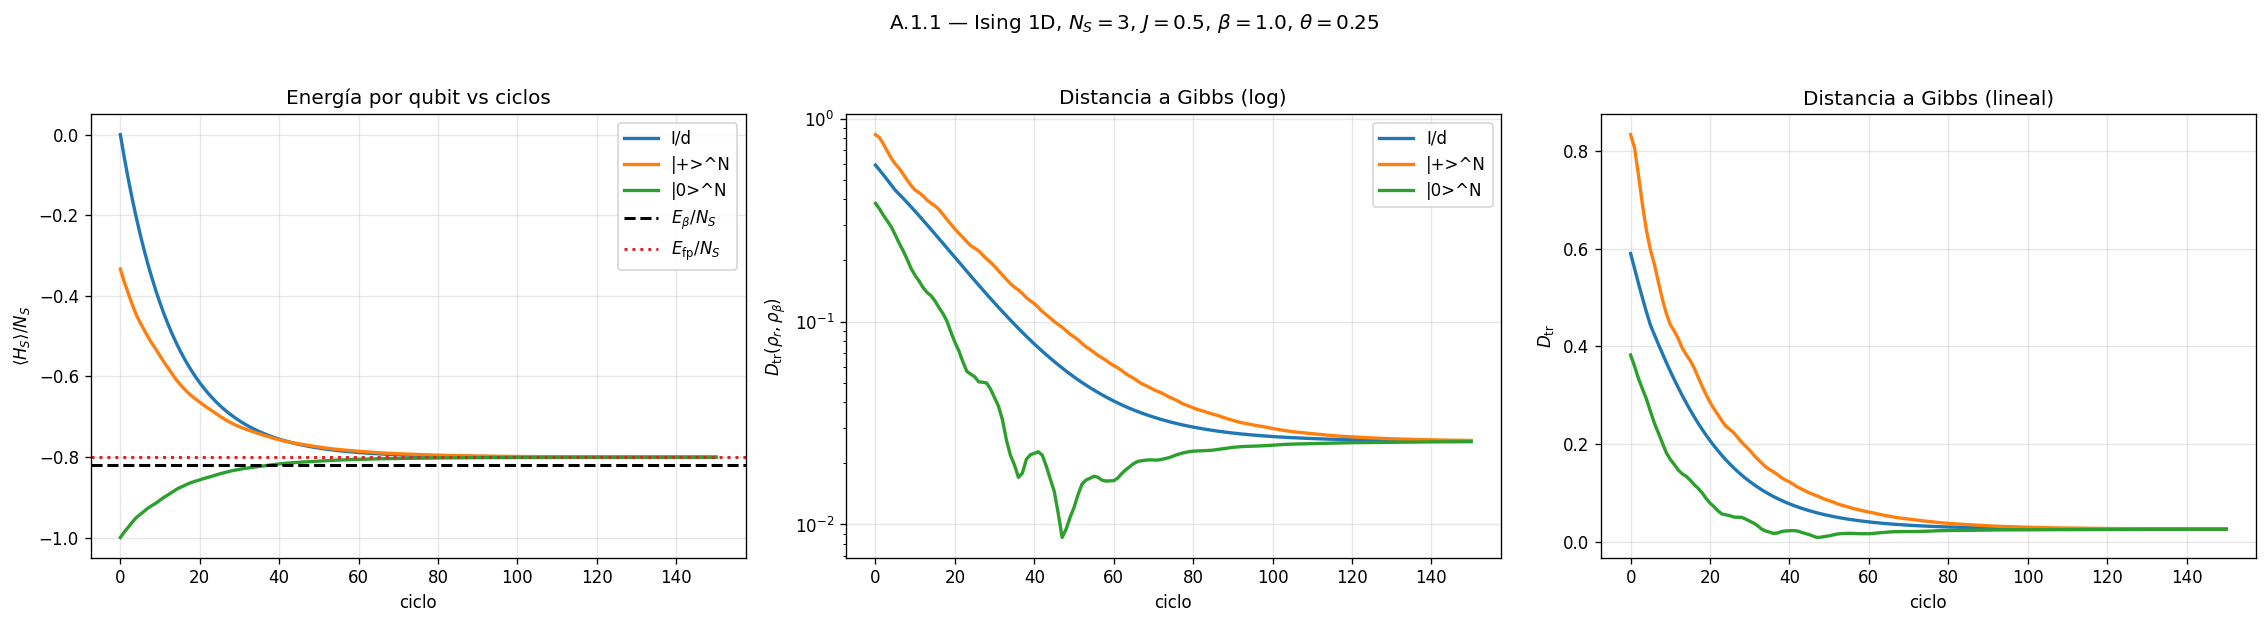

In [4]:
# A.1.1 — Convergencia 1D desde varios estados iniciales

case_A11 = make_params_1d(Lx=3, J=0.5, beta=1.0, MT=10, n_cycles=150, theta=0.25)
print("Caso A.1.1:", case_A11)

states_A11 = {
    "I/d": maximally_mixed(3),
    "|+>^N": all_plus(3),
    "|0>^N": product_basis_dm("000"),
}

runs_A11, df_A11 = run_multistart_ising(
    case_A11,
    states_A11,
    fp_mode="superop",
)

display(df_A11.round(4))

out_ref_A11 = runs_A11["I/d"]["out"]
n_sys_A11 = case_A11["Lx"] * case_A11["Ly"]

plot_multistart_convergence(
    runs_A11,
    title=fr"A.1.1 — Ising 1D, $N_S={n_sys_A11}$, $J={case_A11['J']}$, $\beta={case_A11['beta']}$, $\theta={case_A11['theta']}$",
    E_gibbs_per_site=float(out_ref_A11["Eg"]) / n_sys_A11,
    E_fp_per_site=float(out_ref_A11["Efp"]) / n_sys_A11,
)

Los tres estados iniciales caen al mismo régimen estacionario: energía por sitio y $D_{\rm tr}(\rho_r, \rho_\beta)$ convergen hacia el mismo valor independientemente del punto de partida. El atractor es robusto y la convergencia no es un artefacto de haber arrancado cerca del Gibbs.

### A.1.2 Escalado del sesgo con $\theta^2$

Barremos $\theta \in [0.1, 0.4]$ y medimos el bias energético $|E_{\rm fp} - E_\beta|$ y la distancia traza $D_{\rm tr}(\rho_{\rm fp}, \sigma_\beta)$. Si el régimen es perturbativo, ambos deben escalar linealmente en $\theta^2$.

,theta,theta2,bias_E,Dtr
0,0.10,0.0100,0.00056,0.00056
1,0.15,0.0225,0.00125,0.00127
2,0.20,0.0400,0.00220,0.00227
3,0.25,0.0625,0.00340,0.00357
4,0.30,0.0900,0.00482,0.00518
5,0.35,0.1225,0.00643,0.00710
6,0.40,0.1600,0.00818,0.00935


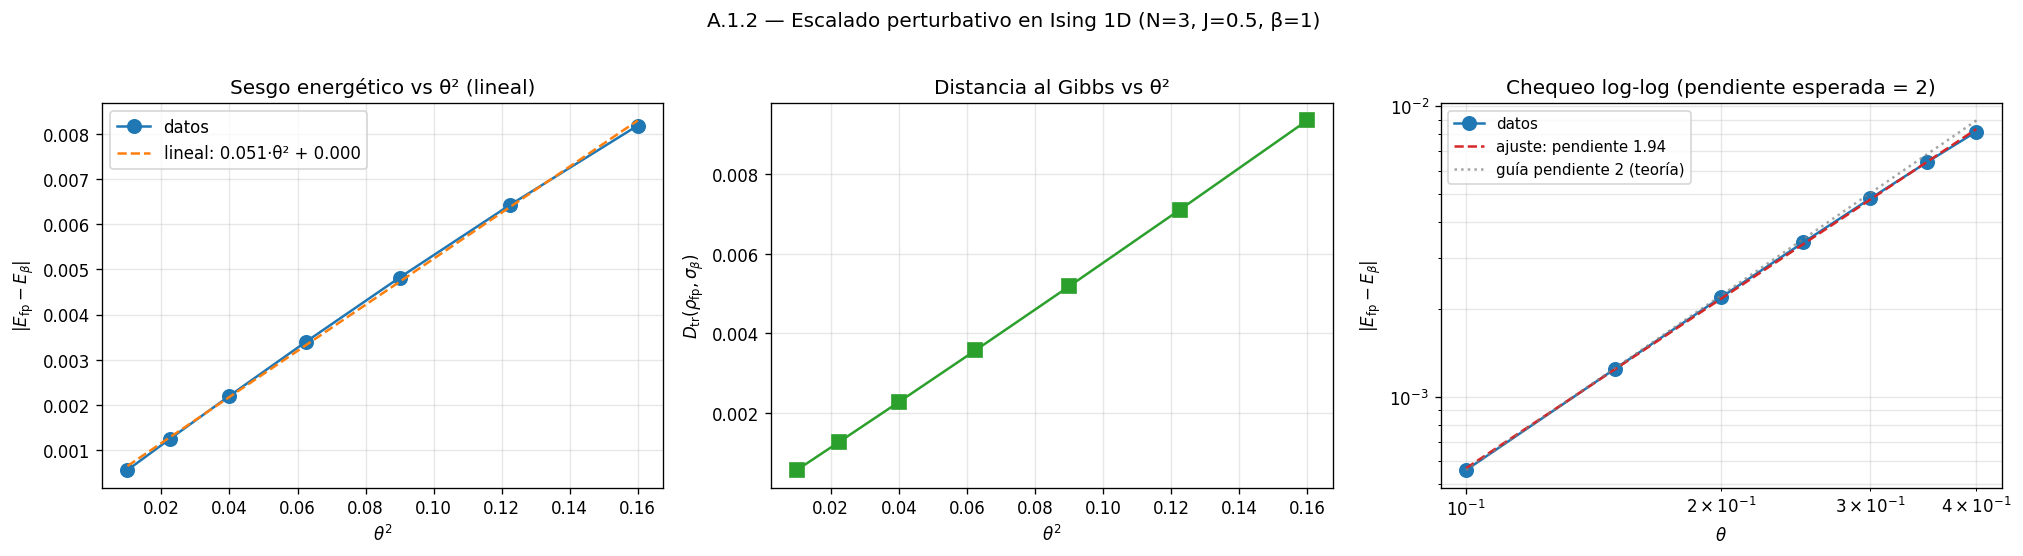


Pendiente log-log ajustada: 1.940  (esperada ~ 2.0)
Intercepto lineal en θ²:    0.0001  (esperado ~ 0)


In [ ]:
# A.1.2 — Sesgo vs theta^2 en Ising 1D N=3

theta_list = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
rows_A12 = []

for theta in theta_list:
    p = make_params_1d(Lx=3, J=0.5, beta=1.0, MT=30, n_cycles=50, theta=theta)
    out = run_ising_case(p, rho0=maximally_mixed(3), compute_fp=True, fp_mode='superop')
    rho_fp = out['rho_fp']
    rho_g  = out['rho_g']
    rows_A12.append({
        'theta':  theta,
        'theta2': theta**2,
        'bias_E': abs(out['Efp'] - out['Eg']),
        'Dtr':    trace_distance_dm(rho_fp, rho_g),
    })

df_A12 = pd.DataFrame(rows_A12)
display(df_A12.round(5))

# --- Ajustes ---
# (1) Lineal en theta^2 para el bias energético
p_lin = np.polyfit(df_A12['theta2'], df_A12['bias_E'], 1)

# (2) Log-log en theta para verificar la pendiente ~ 2
slope, intercept = np.polyfit(
    np.log(df_A12['theta']),
    np.log(df_A12['bias_E']),
    1,
)

# --- Plot 1x3: bias lineal en theta^2, Dtr lineal en theta^2, log-log en theta ---
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Panel 1: bias_E vs theta^2 (lineal)
axes[0].plot(df_A12['theta2'], df_A12['bias_E'], 'o-', ms=8, color='tab:blue', label='datos')
x_fit = np.linspace(df_A12['theta2'].min(), df_A12['theta2'].max(), 50)
axes[0].plot(x_fit, np.polyval(p_lin, x_fit), '--', color='tab:orange',
             label=f'lineal: {p_lin[0]:.3f}·θ² + {p_lin[1]:.3f}')
axes[0].set_xlabel(r'$\theta^2$')
axes[0].set_ylabel(r'$|E_{\rm fp} - E_\beta|$')
axes[0].set_title('Sesgo energético vs θ² (lineal)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2: Dtr vs theta^2 (lineal)
axes[1].plot(df_A12['theta2'], df_A12['Dtr'], 's-', ms=8, color='tab:green')
axes[1].set_xlabel(r'$\theta^2$')
axes[1].set_ylabel(r'$D_{\rm tr}(\rho_{\rm fp}, \sigma_\beta)$')
axes[1].set_title('Distancia al Gibbs vs θ²')
axes[1].grid(alpha=0.3)

# Panel 3: log-log de bias_E vs theta, con guía de pendiente 2
axes[2].loglog(df_A12['theta'], df_A12['bias_E'], 'o-', ms=8, color='tab:blue', label='datos')
theta_fine = np.linspace(df_A12['theta'].min(), df_A12['theta'].max(), 100)
axes[2].loglog(
    theta_fine,
    np.exp(intercept) * theta_fine**slope,
    '--', color='tab:red',
    label=f'ajuste: pendiente {slope:.2f}',
)
# Guía visual de pendiente exactamente 2 anclada al primer punto
theta0 = df_A12['theta'].iloc[0]
bias0  = df_A12['bias_E'].iloc[0]
axes[2].loglog(
    theta_fine,
    bias0 * (theta_fine / theta0)**2,
    ':', color='gray', alpha=0.7,
    label='guía pendiente 2 (teoría)',
)
axes[2].set_xlabel(r'$\theta$')
axes[2].set_ylabel(r'$|E_{\rm fp} - E_\beta|$')
axes[2].set_title(f'Chequeo log-log (pendiente esperada = 2)')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3, which='both')

plt.suptitle('A.1.2 — Escalado perturbativo en Ising 1D (N=3, J=0.5, β=1)', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nPendiente log-log ajustada: {slope:.3f}  (esperada ~ 2.0)')
print(f'Intercepto lineal en θ²:    {p_lin[1]:.4f}  (esperado ~ 0)')

El ajuste lineal en $\theta^2$ da $|E_{\rm fp}-E_\beta| \approx 0.051\,\theta^2$ con intercepto compatible con cero, y el log-log da pendiente $1.94$ frente a la predicción teórica $2$ de la Ec. 42. El sesgo es perturbativo en todo el rango $\theta\in[0.1,0.4]$. El coeficiente $0.051$ es específico del punto $(N=3,\,J=0.5,\,\beta=1)$ y depende de los gaps del Hamiltoniano y del filtro; otros puntos del plano $(\beta,J)$ dan constantes distintas.

### A.1.3 Convergencia en ciclos: tiempo de equilibrio

El paper argumenta que el tiempo de equilibrio escala como $\theta^{-2}$ (Sec. III A). Lo comprobamos directamente: si reescalamos el eje horizontal por $\theta^2 \cdot n_{\rm ciclos}$, las curvas de distinto $\theta$ deberían colapsar.

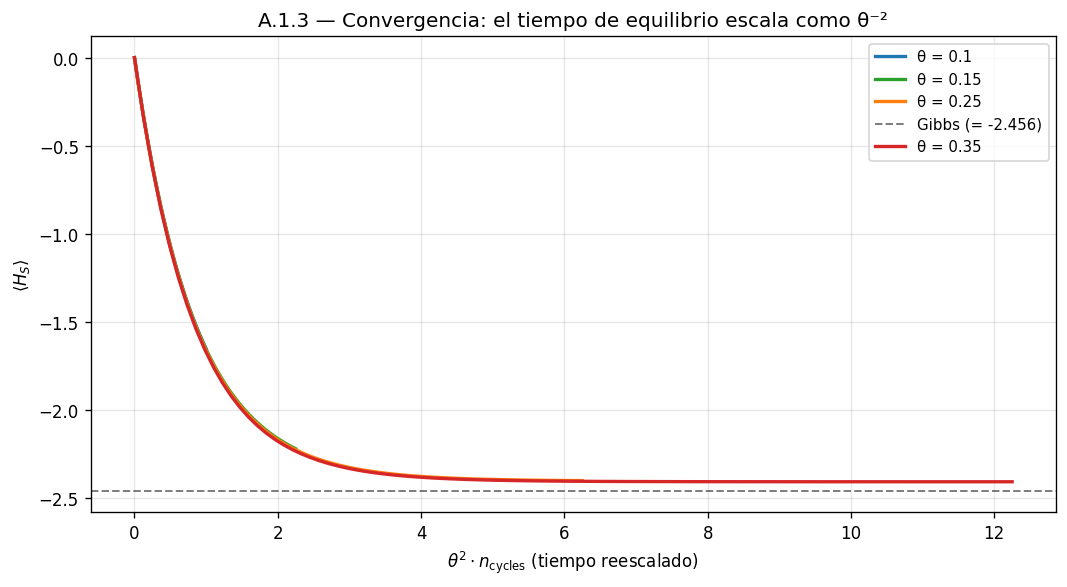

In [ ]:
# A.1.3 — Convergencia en n_cycles para varios theta

fig, ax = plt.subplots(figsize=(9, 5))
colors = {0.10: 'tab:blue', 0.15: 'tab:green', 0.25: 'tab:orange', 0.35: 'tab:red'}

for theta in [0.10, 0.15, 0.25, 0.35]:
    p = make_params_1d(Lx=3, J=0.5, beta=1.0, MT=10, n_cycles=100, theta=theta)
    out = run_ising_case(p, rho0=maximally_mixed(3), compute_fp=False)
    E = out['res']['energies']
    E_g = out['Eg']
    # escalamos el eje x con theta^2 · n_cycles (teoría)
    cycles = np.arange(len(E))
    ax.plot(theta**2 * cycles, E, '-', lw=2, color=colors[theta], label=f'θ = {theta}')
    if theta == 0.25:
        ax.axhline(E_g, ls='--', color='k', alpha=0.5, lw=1.2, label=f'Gibbs (= {E_g:.3f})')

ax.set_xlabel(r'$\theta^2 \cdot n_{\rm cycles}$ (tiempo reescalado)')
ax.set_ylabel(r'$\langle H_S \rangle$')
ax.set_title('A.1.3 — Convergencia: el tiempo de equilibrio es consistente con θ⁻²')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


Las curvas de $\theta \in \{0.10, 0.15, 0.25, 0.35\}$ colapsan sobre la misma trayectoria universal en el eje reescalado $\theta^2 \cdot n_{\rm ciclos}$, confirmando el escalado del tiempo de equilibrio. La única diferencia entre curvas es el nivel asintótico — el sesgo $\sim\theta^2$, que ya vimos en A.1.2. En la práctica, $\theta \in [0.25, 0.30]$ es el punto operativo razonable: converge en pocos ciclos con sesgo controlado.

## A.2 Ising 2D — caracterización exacta

El Ising 2D es el caso central del paper (Sec. IV.B). Trabajamos con retículos $2\times 2$ y $3\times 3$, donde el superoperador es tratable. A diferencia del 1D, aquí aparece correlación cuántica genuina y un precursor de transición de fase, que el protocolo tiene que reproducir.

### A.2.1 Convergencia 2D $2\times 2$ desde varios estados iniciales

Cuatro estados iniciales: $I/d$, $|+\rangle^{\otimes 4}$, $|0000\rangle$ y $|0101\rangle$. Además de energía por sitio y $D_{\rm tr}$, seguimos la información mutua para dos particiones geométricas del retículo — arriba/abajo $\{0,1\}\,|\,\{2,3\}$ e izquierda/derecha $\{0,2\}\,|\,\{1,3\}$ — para ver si el fp reproduce también las correlaciones del Gibbs, no solo la energía.

Caso A.2.1: {'Lx': 2, 'Ly': 2, 'J': 0.5, 'g': 1.0, 'h': 2.0, 'beta': 1.0, 'theta': 0.25, 'delta': 0.07853981633974483, 'MT': 8, 'n_cycles': 150, 'sys_A': 'Y', 'bath_A': 'Y'}


,init,E0/N,E_last/N,E_Gibbs/N,"Dtr(ρ0,ρβ)","Dtr(ρR,ρβ)","F(ρR,ρβ)",S(ρR),purity(ρR),Δ_last
0,I/d,0.0,-0.7864,-0.8587,0.6583,0.0946,0.9874,1.6470,0.2971,0.0000
1,|+>^N,-0.5,-0.7861,-0.8587,0.8513,0.0958,0.9872,1.6479,0.2965,0.0004
2,|0000>,-1.0,-0.7866,-0.8587,0.5025,0.0940,0.9875,1.6466,0.2975,0.0000
3,|0101>,0.0,-0.7864,-0.8587,0.9841,0.0945,0.9874,1.6470,0.2972,0.0000


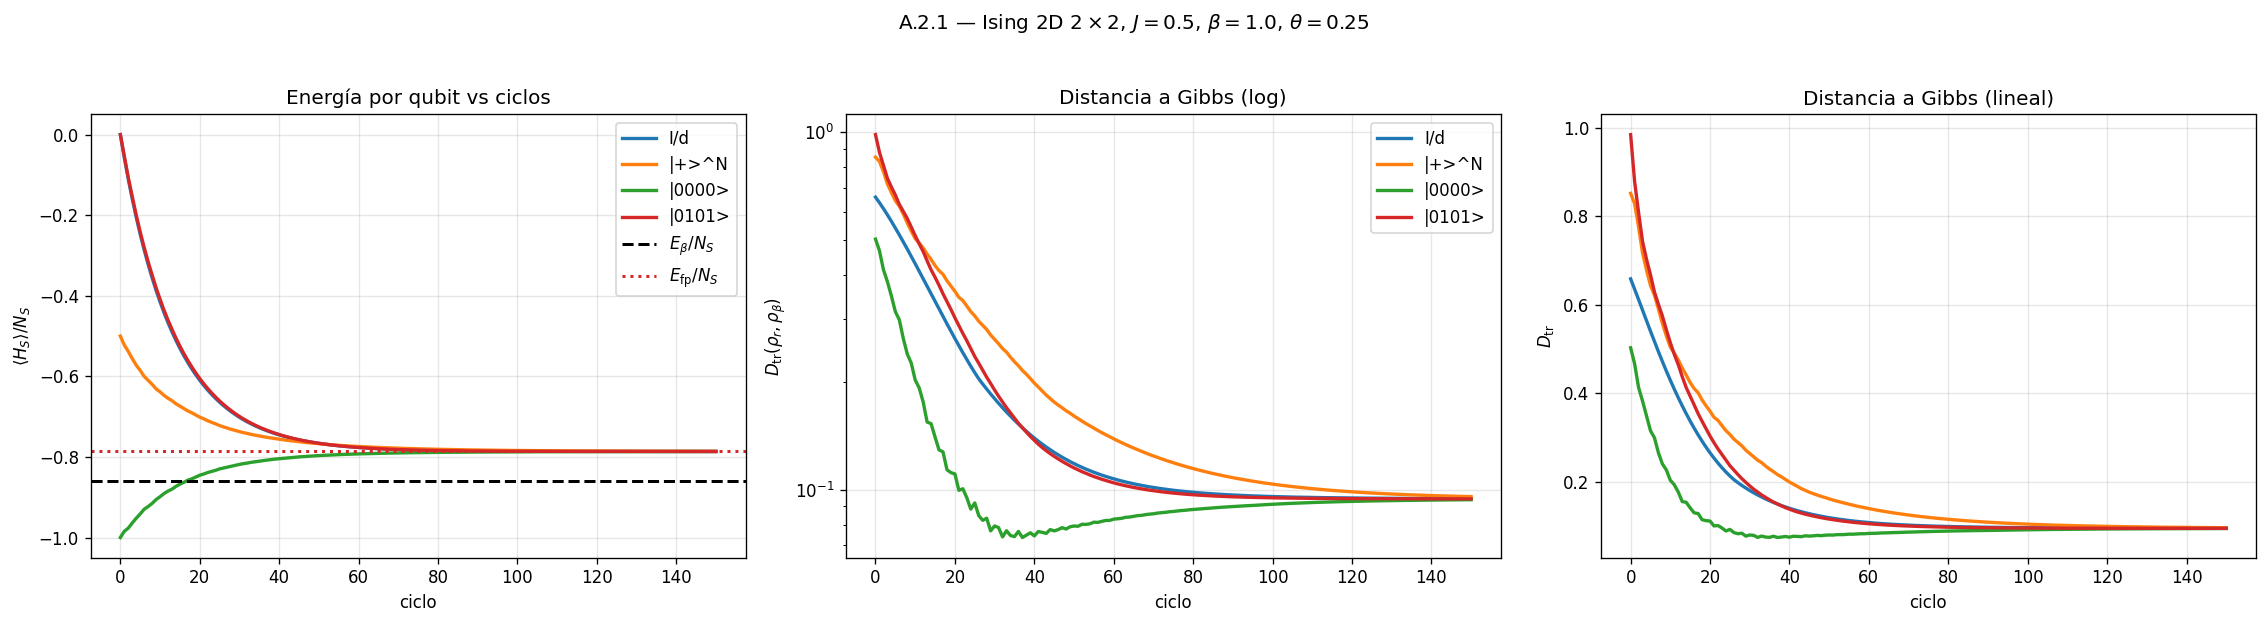

,estado,I_arriba_abajo,I_izquierda_derecha
0,fp protocolo,0.1291,0.1291
1,Gibbs exacto,0.1515,0.1515


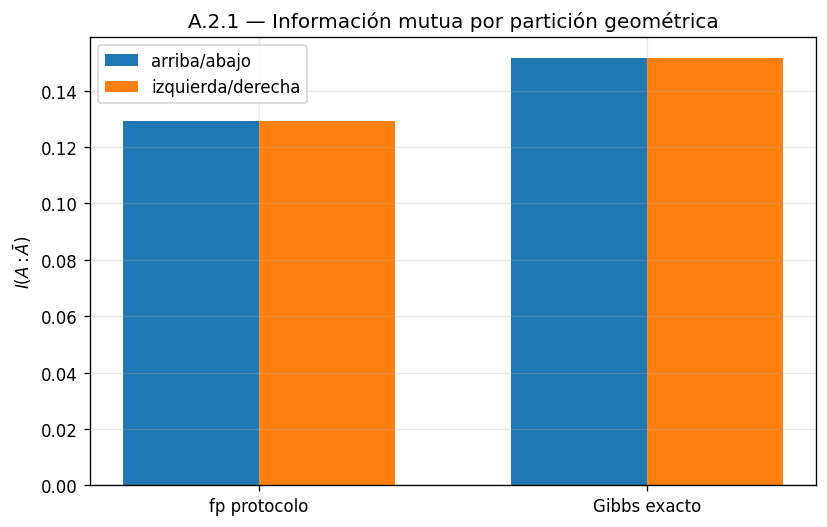

In [4]:
# A.2.1 — Convergencia 2D 2x2 desde varios estados iniciales

case_A21 = make_params_2d(Lx=2, Ly=2, J=0.5, beta=1.0, MT=8, n_cycles=150, theta=0.25)
print("Caso A.2.1:", case_A21)

states_A21 = {
    "I/d": maximally_mixed(4),
    "|+>^N": all_plus(4),
    "|0000>": product_basis_dm("0000"),
    "|0101>": product_basis_dm("0101"),
}

runs_A21, df_A21 = run_multistart_ising(
    case_A21,
    states_A21,
    fp_mode="late_time",
    late_fp_burn=120,
    late_fp_keep=30,
)

display(df_A21.round(4))

out_ref_A21 = runs_A21["I/d"]["out"]
n_sys_A21 = case_A21["Lx"] * case_A21["Ly"]

plot_multistart_convergence(
    runs_A21,
    title=fr"A.2.1 — Ising 2D $2\times 2$, $J={case_A21['J']}$, $\beta={case_A21['beta']}$, $\theta={case_A21['theta']}$",
    E_gibbs_per_site=float(out_ref_A21["Eg"]) / n_sys_A21,
    E_fp_per_site=float(out_ref_A21["Efp"]) / n_sys_A21,
)

# --- Información mutua por particiones geométricas ---
rho_fp_A21 = out_ref_A21["rho_fp"]
rho_g_A21 = out_ref_A21["rho_g"]

df_A21_MI = pd.DataFrame([
    {
        "estado": "fp protocolo",
        "I_arriba_abajo": mutual_information_partition(rho_fp_A21, [0, 1], 4),
        "I_izquierda_derecha": mutual_information_partition(rho_fp_A21, [0, 2], 4),
    },
    {
        "estado": "Gibbs exacto",
        "I_arriba_abajo": mutual_information_partition(rho_g_A21, [0, 1], 4),
        "I_izquierda_derecha": mutual_information_partition(rho_g_A21, [0, 2], 4),
    },
])

display(df_A21_MI.round(4))

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(2)
w = 0.35

ax.bar(x - w/2, df_A21_MI["I_arriba_abajo"], width=w, label="arriba/abajo")
ax.bar(x + w/2, df_A21_MI["I_izquierda_derecha"], width=w, label="izquierda/derecha")

ax.set_xticks(x)
ax.set_xticklabels(df_A21_MI["estado"])
ax.set_ylabel(r"$I(A:\bar A)$")
ax.set_title("A.2.1 — Información mutua por partición geométrica")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Los cuatro estados iniciales convergen al mismo régimen: energía y $D_{\rm tr}$ caen hacia los valores del Gibbs y la información mutua del fp es compatible con la del Gibbs exacto. La lectura clave en 2D no es solo que la energía baje, sino que el estado estacionario reproduzca la estructura de correlaciones — en 2D eso no está garantizado por la energía sola.

### A.2.2 Barrido en $\beta$: energía y calor específico en $2×2$

Fijamos $J = 1$ (valor del paper) y barremos $\beta \in [0.1, 1.5]$. Comparamos:
- **energía** del fp vs Gibbs exacto;
- **calor específico** $C_V = \beta^2 \mathrm{Var}_\rho(H_S)$.




,beta,E_fp,E_g,C_fp,C_g,Dtr,I_halves
0,0.10,-0.8040,-0.7959,0.0787,0.0788,0.0014,0.0102
1,0.25,-1.9459,-1.9336,0.4475,0.4488,0.0038,0.0618
2,0.50,-3.4533,-3.4521,1.1954,1.1993,0.0061,0.2136
3,0.75,-4.3258,-4.3371,1.3778,1.3666,0.0089,0.3665
4,1.00,-4.7423,-4.7561,1.1089,1.0860,0.0151,0.4731
5,1.25,-4.9268,-4.9416,0.7717,0.7542,0.0267,0.5380
6,1.50,-5.0049,-5.0259,0.5437,0.5127,0.0422,0.5748


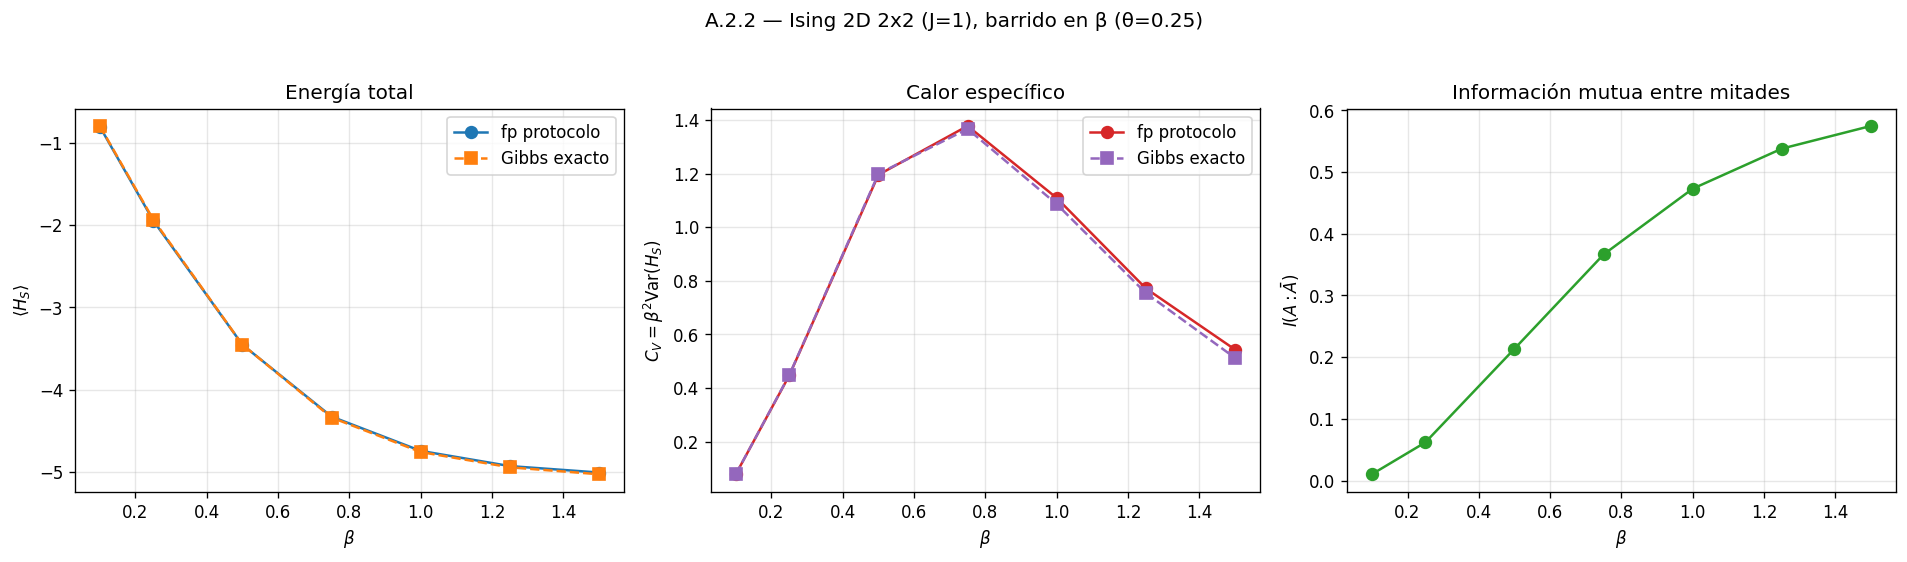

In [8]:
# A.2.2 — Barrido en beta a J=1 en 2D 2x2

beta_list_A22 = [0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
rows_A22 = []

for b in beta_list_A22:
    p = make_params_2d(Lx=2, Ly=2, J=1.0, beta=b, MT=8, n_cycles=40, theta=0.25)
    out = run_ising_case(p, rho0=maximally_mixed(4), compute_fp=True,
                         fp_mode='late_time', late_fp_burn=80, late_fp_keep=20)
    rho_fp = out['rho_fp']
    rho_g = out['rho_g']
    Hs = out['Hs']
    rows_A22.append({
        'beta':     b,
        'E_fp':     float(expect(Hs, rho_fp)),
        'E_g':      float(expect(Hs, rho_g)),
        'C_fp':     heat_capacity_ising(rho_fp, Hs, b),
        'C_g':      heat_capacity_ising(rho_g, Hs, b),
        'Dtr':      trace_distance_dm(rho_fp, rho_g),
        'I_halves': mutual_information_halves(rho_fp, 4),
    })

df_A22 = pd.DataFrame(rows_A22)
display(df_A22.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(df_A22['beta'], df_A22['E_fp'], 'o-', ms=7, color='tab:blue', label='fp protocolo')
axes[0].plot(df_A22['beta'], df_A22['E_g'], 's--', ms=7, color='tab:orange', label='Gibbs exacto')
axes[0].set_xlabel(r'$\beta$'); axes[0].set_ylabel(r'$\langle H_S \rangle$')
axes[0].set_title('Energía total')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df_A22['beta'], df_A22['C_fp'], 'o-', ms=7, color='tab:red', label='fp protocolo')
axes[1].plot(df_A22['beta'], df_A22['C_g'], 's--', ms=7, color='tab:purple', label='Gibbs exacto')
axes[1].set_xlabel(r'$\beta$'); axes[1].set_ylabel(r'$C_V = \beta^2 \mathrm{Var}(H_S)$')
axes[1].set_title('Calor específico')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(df_A22['beta'], df_A22['I_halves'], 'o-', ms=7, color='tab:green')
axes[2].set_xlabel(r'$\beta$'); axes[2].set_ylabel(r'$I(A:\bar A)$')
axes[2].set_title('Información mutua entre mitades')
axes[2].grid(alpha=0.3)

plt.suptitle(f'A.2.2 — Ising 2D 2x2 (J=1), barrido en β (θ={case_A21["theta"]})', y=1.03)
plt.tight_layout(); plt.show()


El fp sigue bien la curva del Gibbs en energía y $C_V$ a lo largo del barrido. El pico ancho de $C_V$ en $\beta\sim 0.5$ es un crossover finito, no una transición de fase: en $2\times 2$ todos los observables son analíticos. Lo que muestra el barrido es que el protocolo captura correctamente la región donde la respuesta térmica del sistema es más intensa.

### A.2.3 Carácter clásico vs cuántico de las correlaciones

La información mutua $I(A:\bar A) = S(\rho_A)+S(\rho_{\bar A})-S(\rho)$ mezcla contribuciones clásicas y cuánticas. Añadimos dos diagnósticos para separarlas: un proxy clásico en base $Z$ (desfasamos el estado en base computacional y recalculamos $I$; la diferencia $I - I_{\rm diag}$ captura la correlación de fase en esa base), y la negatividad de pares vecinos como certificador de entrelazamiento bipartito. Aplicamos ambos en el punto único de A.2.1 y a lo largo del barrido en $\beta$ de A.2.2.

A.2.3.a — Diagnóstico clásico/cuántico en el punto de A.2.1 (J=0.5, β=1)


,estado,I_total,I_diag(Z),I − I_diag,"Neg(0,1)","Neg(0,2)"
0,fp protocolo,0.1291,0.0005,0.1286,0.0,0.0
1,Gibbs exacto,0.1515,0.0021,0.1493,0.0,0.0


A.2.3.b — Evolución con β del carácter clásico/cuántico (J=1)


,beta,I_total,I_diag(Z),I − I_diag,"Neg(0,1)","Neg(0,2)"
0,0.10,0.0102,0.0000,0.0102,0.0000,0.0000
1,0.25,0.0619,0.0000,0.0619,0.0000,0.0000
2,0.50,0.2129,0.0002,0.2127,0.0000,0.0000
3,0.75,0.3643,0.0019,0.3624,0.0000,0.0000
4,1.00,0.4687,0.0055,0.4632,0.0156,0.0156
5,1.25,0.5312,0.0090,0.5222,0.0344,0.0344
6,1.50,0.5666,0.0113,0.5553,0.0433,0.0433


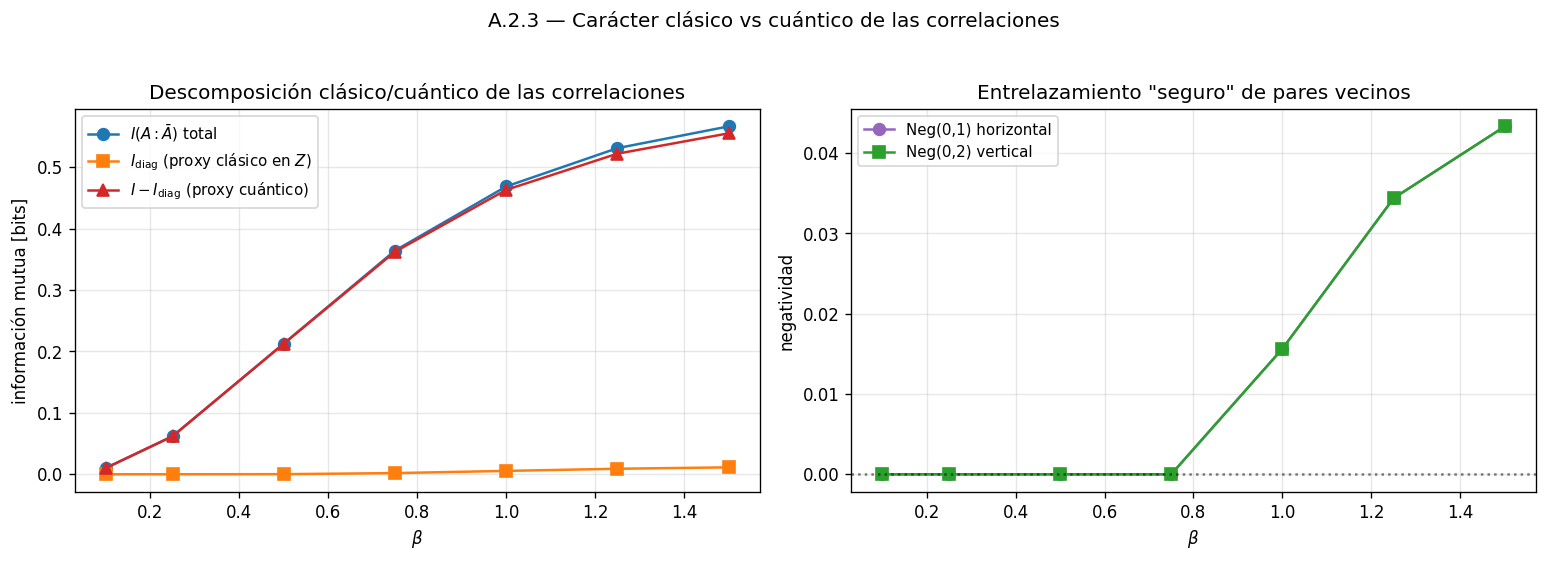

In [7]:
# A.2.3 — Carácter clásico vs cuántico de las correlaciones
# Integra:
#   (i) diagnóstico puntual en el caso de A.2.1  (J=0.5, beta=1)
#   (ii) barrido en beta del caso de A.2.2       (J=1 fijo)

def twoqubit_dm(rho, i, j, n_sys=4):
    return reduced_dm_keep(rho, [i, j], n_sys)

# ============================================================
# A.2.3.a — Diagnóstico en el punto único de A.2.1
# ============================================================
rows_A23_point = []

for label, rho in [("fp protocolo", rho_fp_A21), ("Gibbs exacto", rho_g_A21)]:
    rho_diag = dephase_computational_basis(rho)
    I_total = mutual_information_partition(rho, [0, 1], 4)
    I_diag  = mutual_information_partition(rho_diag, [0, 1], 4)

    rows_A23_point.append({
        "estado":      label,
        "I_total":     I_total,
        "I_diag(Z)":   I_diag,
        "I − I_diag":  I_total - I_diag,
        "Neg(0,1)":    negativity_twoqubit(twoqubit_dm(rho, 0, 1, 4)),
        "Neg(0,2)":    negativity_twoqubit(twoqubit_dm(rho, 0, 2, 4)),
    })

df_A23_point = pd.DataFrame(rows_A23_point)

print("A.2.3.a — Diagnóstico clásico/cuántico en el punto de A.2.1 (J=0.5, β=1)")
display(df_A23_point.round(4))


# ============================================================
# A.2.3.b — Barrido en β (heredado de A.2.2, con J=1 fijo)
# ============================================================
beta_list_A23 = beta_list_A22  # mismas beta que en A.2.2
rows_A23_beta = []

for b in beta_list_A23:
    p = make_params_2d(Lx=2, Ly=2, J=1.0, beta=b, n_cycles=40, theta=0.25)
    out = run_ising_case(
        p,
        rho0=maximally_mixed(4),
        compute_fp=True,
        fp_mode="late_time",
        late_fp_burn=80,
        late_fp_keep=20,
    )

    rho_fp = out["rho_fp"]
    rho_diag = dephase_computational_basis(rho_fp)

    I_total = mutual_information_partition(rho_fp,   [0, 1], 4)
    I_diag  = mutual_information_partition(rho_diag, [0, 1], 4)

    rows_A23_beta.append({
        "beta":       b,
        "I_total":    I_total,
        "I_diag(Z)":  I_diag,
        "I − I_diag": I_total - I_diag,
        "Neg(0,1)":   negativity_twoqubit(twoqubit_dm(rho_fp, 0, 1, 4)),
        "Neg(0,2)":   negativity_twoqubit(twoqubit_dm(rho_fp, 0, 2, 4)),
    })

df_A23_beta = pd.DataFrame(rows_A23_beta)

print("A.2.3.b — Evolución con β del carácter clásico/cuántico (J=1)")
display(df_A23_beta.round(4))


# ============================================================
# Figura resumen A.2.3
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel 1: I_total, I_diag y diferencia
axes[0].plot(
    df_A23_beta["beta"], df_A23_beta["I_total"],
    "o-", ms=7, color="tab:blue", label=r"$I(A:\bar A)$ total"
)
axes[0].plot(
    df_A23_beta["beta"], df_A23_beta["I_diag(Z)"],
    "s-", ms=7, color="tab:orange", label=r"$I_{\rm diag}$ (proxy clásico en $Z$)"
)
axes[0].plot(
    df_A23_beta["beta"], df_A23_beta["I − I_diag"],
    "^-", ms=7, color="tab:red", label=r"$I - I_{\rm diag}$ (proxy cuántico)"
)
axes[0].set_xlabel(r"$\beta$")
axes[0].set_ylabel("información mutua [bits]")
axes[0].set_title("Descomposición clásico/cuántico de las correlaciones")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Panel 2: negatividad de pares vecinos
axes[1].plot(
    df_A23_beta["beta"], df_A23_beta["Neg(0,1)"],
    "o-", ms=7, color="tab:purple", label="Neg(0,1) horizontal"
)
axes[1].plot(
    df_A23_beta["beta"], df_A23_beta["Neg(0,2)"],
    "s-", ms=7, color="tab:green", label="Neg(0,2) vertical"
)
axes[1].axhline(0.0, ls=":", color="k", alpha=0.5)
axes[1].set_xlabel(r"$\beta$")
axes[1].set_ylabel("negatividad")
axes[1].set_title('Entrelazamiento "seguro" de pares vecinos')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("A.2.3 — Carácter clásico vs cuántico de las correlaciones", y=1.03)
plt.tight_layout()
plt.show()

La correlación es esencialmente cuántica: $I_{\rm diag}/I_{\rm total} \lesssim 1\%$ tanto en el fp del protocolo como en el Gibbs exacto, y a lo largo de todo el barrido en $\beta$ con $J=1$. Deshacer las coherencias en base $Z$ destruye casi toda la información mutua — los términos $-JX_iX_j$ del Hamiltoniano acoplan autoestados de $Z$ y cargan la correlación en las coherencias entre ellos.

La negatividad muestra un umbral claro: es nula hasta $\beta\approx 1$ (con $J=1$) y crece a partir de ahí, confirmando entrelazamiento bipartito en los enlaces en el régimen de baja temperatura. Las dos curvas — horizontal y vertical — son idénticas en todo el barrido, coherente con las PBC del retículo $2\times 2$ donde todos los enlaces son equivalentes.

Respecto al fp: la información mutua se subestima un ~15% frente al Gibbs exacto, frente a ~5% en la energía. La $I(A:\bar A)$ es no-lineal en el estado, así que el sesgo $O(\theta^2)$ en las coherencias se amplifica al calcular las entropías de von Neumann. Para reproducir correlaciones con la misma precisión que la energía habría que reducir $\theta$.

## A.3 Operadores de acoplo

El paper usa $A_S = (Y_i+Z_i)/\sqrt{2}$ sin justificar la elección frente a $Y_i$ o $Z_i$ solos. Aquí verificamos la jerarquía empíricamente y evaluamos la sensibilidad del resultado a los hiperparámetros $(h, M_T, \theta)$.

### A.3.1 Elección de $A_S$: $Y$, $Z$ y $(Y+Z)/\sqrt{2}$

Comparamos los tres operadores en tres regímenes — no-óptimo ($h=1$), paper ($h=2=\max(2g,4J)$) y óptimo ($h=3$, identificado en A.3.2) — manteniendo $M_T$ y $\theta$ fijos al pasar de paper a óptimo para aislar el efecto del operador.


Régimen: no-óptimo
  h=1.0, MT=15, θ=0.15, δ=0.1500
  [126.1s] Y             : bias/sitio=0.1943, Dtr=0.2259
  [118.5s] Z             : bias/sitio=0.6885, Dtr=0.5720
  [125.3s] (Y+Z)/sqrt2   : bias/sitio=0.3196, Dtr=0.3264

Régimen: paper (h=2)
  h=2.0, MT=9, θ=0.2, δ=0.0785
  [ 91.2s] Y             : bias/sitio=0.0457, Dtr=0.0665
  [ 71.4s] Z             : bias/sitio=0.4689, Dtr=0.4003
  [ 71.5s] (Y+Z)/sqrt2   : bias/sitio=0.1054, Dtr=0.1427

Régimen: óptimo A.2.4 (h=3)
  h=3.0, MT=9, θ=0.2, δ=0.0785
  [ 63.4s] Y             : bias/sitio=0.0185, Dtr=0.0369
  [ 63.2s] Z             : bias/sitio=0.4033, Dtr=0.3573
  [ 64.7s] (Y+Z)/sqrt2   : bias/sitio=0.0814, Dtr=0.1271


,regime,label,bias_per_site,dtr
0,no-óptimo,Y,0.1943,0.2259
1,no-óptimo,Z,0.6885,0.5720
2,no-óptimo,(Y+Z)/sqrt2,0.3196,0.3264
3,paper (h=2),Y,0.0457,0.0665
4,paper (h=2),Z,0.4689,0.4003
5,paper (h=2),(Y+Z)/sqrt2,0.1054,0.1427
6,óptimo A.2.4 (h=3),Y,0.0185,0.0369
7,óptimo A.2.4 (h=3),Z,0.4033,0.3573
8,óptimo A.2.4 (h=3),(Y+Z)/sqrt2,0.0814,0.1271


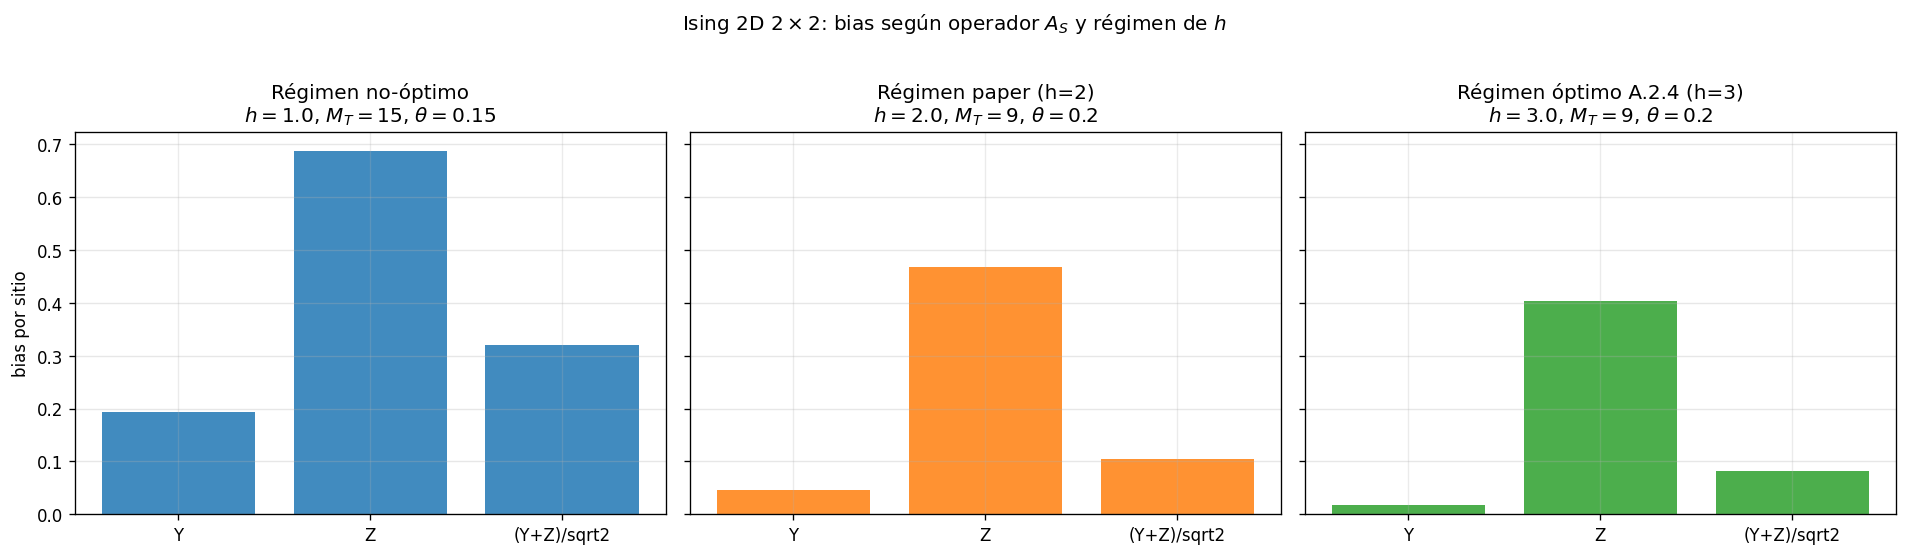

In [ ]:
# — Comparación de operadores de acoplo en Ising 2D 2×2
# Tres operadores × tres regímenes de h = 9 ejecuciones.

import time
import numpy as np

Lx, Ly = 2, 2
n_sys = Lx * Ly
inv_sqrt2 = 1.0 / np.sqrt(2.0)

operators = [
    ("Y",            "Y"),
    ("Z",            "Z"),
    ("(Y+Z)/sqrt2",  [(inv_sqrt2, "Y"), (inv_sqrt2, "Z")]),
]

regimes = [
    ("no-óptimo",
     dict(J=0.5, g=1.0, h=1.0, beta=1.0,
          theta=0.15, delta=0.15, MT=15, n_cycles=1)),
    ("paper (h=2)",
     dict(J=0.5, g=1.0, h=2.0, beta=1.0,
          theta=0.2,  delta=np.pi/40, MT=9, n_cycles=1)),
    ("óptimo A.2.4 (h=3)",
     dict(J=0.5, g=1.0, h=3.0, beta=1.0,
          theta=0.2,  delta=np.pi/40, MT=9, n_cycles=1)),
]

results = {}
for regime_name, params in regimes:
    print(f"\nRégimen: {regime_name}")
    print(f"  h={params['h']}, MT={params['MT']}, "
          f"θ={params['theta']}, δ={params['delta']:.4f}")
    rows = []
    for label, sys_spec in operators:
        t0 = time.time()
        cfg = build_ising_2d_cfg_mix(
            Lx=Lx, Ly=Ly, sys_op_spec=sys_spec, bath_op_spec="Y",
            **params,
        )
        out = run_protocol_case(
            cfg, rho0=maximally_mixed(n_sys),
            compute_fp=True, fp_mode='late_time',
            late_fp_burn=80, late_fp_keep=40,
        )
        E_fp = float(np.real(out["Efp"]))
        E_g  = float(np.real(out["Eg"]))
        bias = abs(E_fp - E_g)
        dtr  = trace_distance_dm(out["rho_fp"], out["rho_g"])
        rows.append(dict(
            label=label,
            bias_per_site=bias / n_sys,
            dtr=dtr,
        ))
        print(f"  [{time.time()-t0:5.1f}s] {label:14s}: "
              f"bias/sitio={bias/n_sys:.4f}, Dtr={dtr:.4f}")
    results[regime_name] = rows

# Tabla resumen
import pandas as pd
df_summary = pd.DataFrame([
    dict(regime=regime_name, **row)
    for regime_name, rows in results.items()
    for row in rows
])
display(df_summary.round(4))

# Plot: 3 paneles compartiendo eje Y
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
colors = {"no-óptimo": "tab:blue",
          "paper (h=2)": "tab:orange",
          "óptimo A.2.4 (h=3)": "tab:green"}

for ax, (regime_name, rows) in zip(axes, results.items()):
    labels = [r["label"] for r in rows]
    bias_per_site = [r["bias_per_site"] for r in rows]
    ax.bar(np.arange(len(labels)), bias_per_site,
           color=colors[regime_name], alpha=0.85)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    p = dict(regimes)[regime_name]
    ax.set_title(f"Régimen {regime_name}\n"
                 f"$h={p['h']}$, $M_T={p['MT']}$, $\\theta={p['theta']}$")
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel("bias por sitio")
plt.suptitle(
    r"Ising 2D $2\times 2$: bias según operador $A_S$ y régimen de $h$",
    y=1.02,
)
plt.tight_layout()
plt.show()

$Z$ es sistemáticamente el peor operador en los tres regímenes — bias 5–10× mayor que $Y$ o que la combinación — porque $Z_i$ casi conmuta con $H_S = -g\sum Z_i$, suprimiendo los elementos de matriz entre autoestados de distinta energía. No puede mediar las transiciones de cooling.

$Y$ y $(Y+Z)/\sqrt{2}$ son comparables, con $Y$ marginalmente mejor en los regímenes optimizados. La elección del paper no es estrictamente óptima, pero la diferencia es pequeña. Lo que sí mueve el sesgo de forma significativa es el valor de $h$: pasar de no-óptimo a óptimo reduce el bias en todos los operadores mucho más que cambiar entre $Y$ y $(Y+Z)/\sqrt{2}$.

## A.4 Geometría del baño

Cuando $N_S > N_B$, hay que decidir qué sitios del sistema se acoplan a los qubits baño en cada ciclo. Esta elección introduce una geometría efectiva del protocolo: si siempre acoplamos el mismo sitio, ese sitio se enfría preferentemente y el resto del sistema solo se relaja de forma indirecta mediante la evolución unitaria interna.

Por tanto, la geometría del baño afecta a dos preguntas distintas:

1. **simetría espacial:** si el protocolo introduce perfiles artificialmente no uniformes;
2. **calidad del estado final:** si el estado estacionario se acerca realmente al Gibbs exacto.

En esta sección separamos ambas cuestiones. Primero estudiamos schedules con $N_B=1$ para ver cómo se reparte espacialmente el enfriamiento. Después barremos $N_B$ para cuantificar cuánto mejora el sesgo al aumentar el número de baños.

### A.4.1 Simetría rota con $N_B=1$

Con un único qubit baño, cada ciclo solo puede acoplar un sitio del sistema. Si el sitio es fijo, el protocolo rompe la simetría espacial del Hamiltoniano: el sitio acoplado se enfría directamente y los demás solo se relajan por propagación interna.

Para medir este efecto comparamos el perfil local $<Z_i>$ del estado estacionario con el perfil del Gibbs exacto. Usamos dos métricas:

- la desviación espacial $\sigma(<Z_i>)$, que mide cuán uniforme es el perfil;
- la distancia de perfil $\Delta_{\rm perfil}$, que mide cuán cerca está el perfil final del perfil Gibbs.

Probamos cuatro schedules con $N_B=1$ en Ising $2\times3$:

- acoplo fijo a un sitio de esquina;
- acoplo fijo a un sitio de borde;
- alternancia determinista entre dos esquinas opuestas;
- rotación aleatoria, sorteando el sitio acoplado en cada ciclo.

La rotación aleatoria implementa la idea del paper: si no hay un baño por sitio, se puede restaurar la simetría en promedio temporal cambiando la geometría de acoplo entre ciclos.


Condiciones de contorno: OBC
Gibbs <Z_i>: ['+0.694', '+0.694', '+0.660', '+0.660', '+0.694', '+0.694']
σ(Gibbs)   = 0.0161

  [396.5s] fijo sitio 0      : σ(perfil)=0.0308, Δ_perfil=0.2481
  [343.4s] fijo sitio 2      : σ(perfil)=0.0362, Δ_perfil=0.2899
  [152.2s] alterna 0↔5       : σ(perfil)=0.0313, Δ_perfil=0.2444
  [130.8s] aleatorio         : σ(perfil)=0.0106, Δ_perfil=0.2398

Condiciones de contorno: PBC
Gibbs <Z_i>: ['+0.631', '+0.631', '+0.631', '+0.631', '+0.631', '+0.631']
σ(Gibbs)   = 0.0000

  [127.3s] fijo sitio 0      : σ(perfil)=0.0373, Δ_perfil=0.2517
  [125.6s] fijo sitio 2      : σ(perfil)=0.0373, Δ_perfil=0.2517
  [113.7s] alterna 0↔5       : σ(perfil)=0.0196, Δ_perfil=0.2372
  [126.3s] aleatorio         : σ(perfil)=0.0038, Δ_perfil=0.2290


,BC,geometria,sigma_perfil,delta_perfil
0,OBC,fijo sitio 0,0.0308,0.2481
1,OBC,fijo sitio 2,0.0362,0.2899
2,OBC,alterna 0↔5,0.0313,0.2444
3,OBC,aleatorio,0.0106,0.2398
4,PBC,fijo sitio 0,0.0373,0.2517
5,PBC,fijo sitio 2,0.0373,0.2517
6,PBC,alterna 0↔5,0.0196,0.2372
7,PBC,aleatorio,0.0038,0.2290


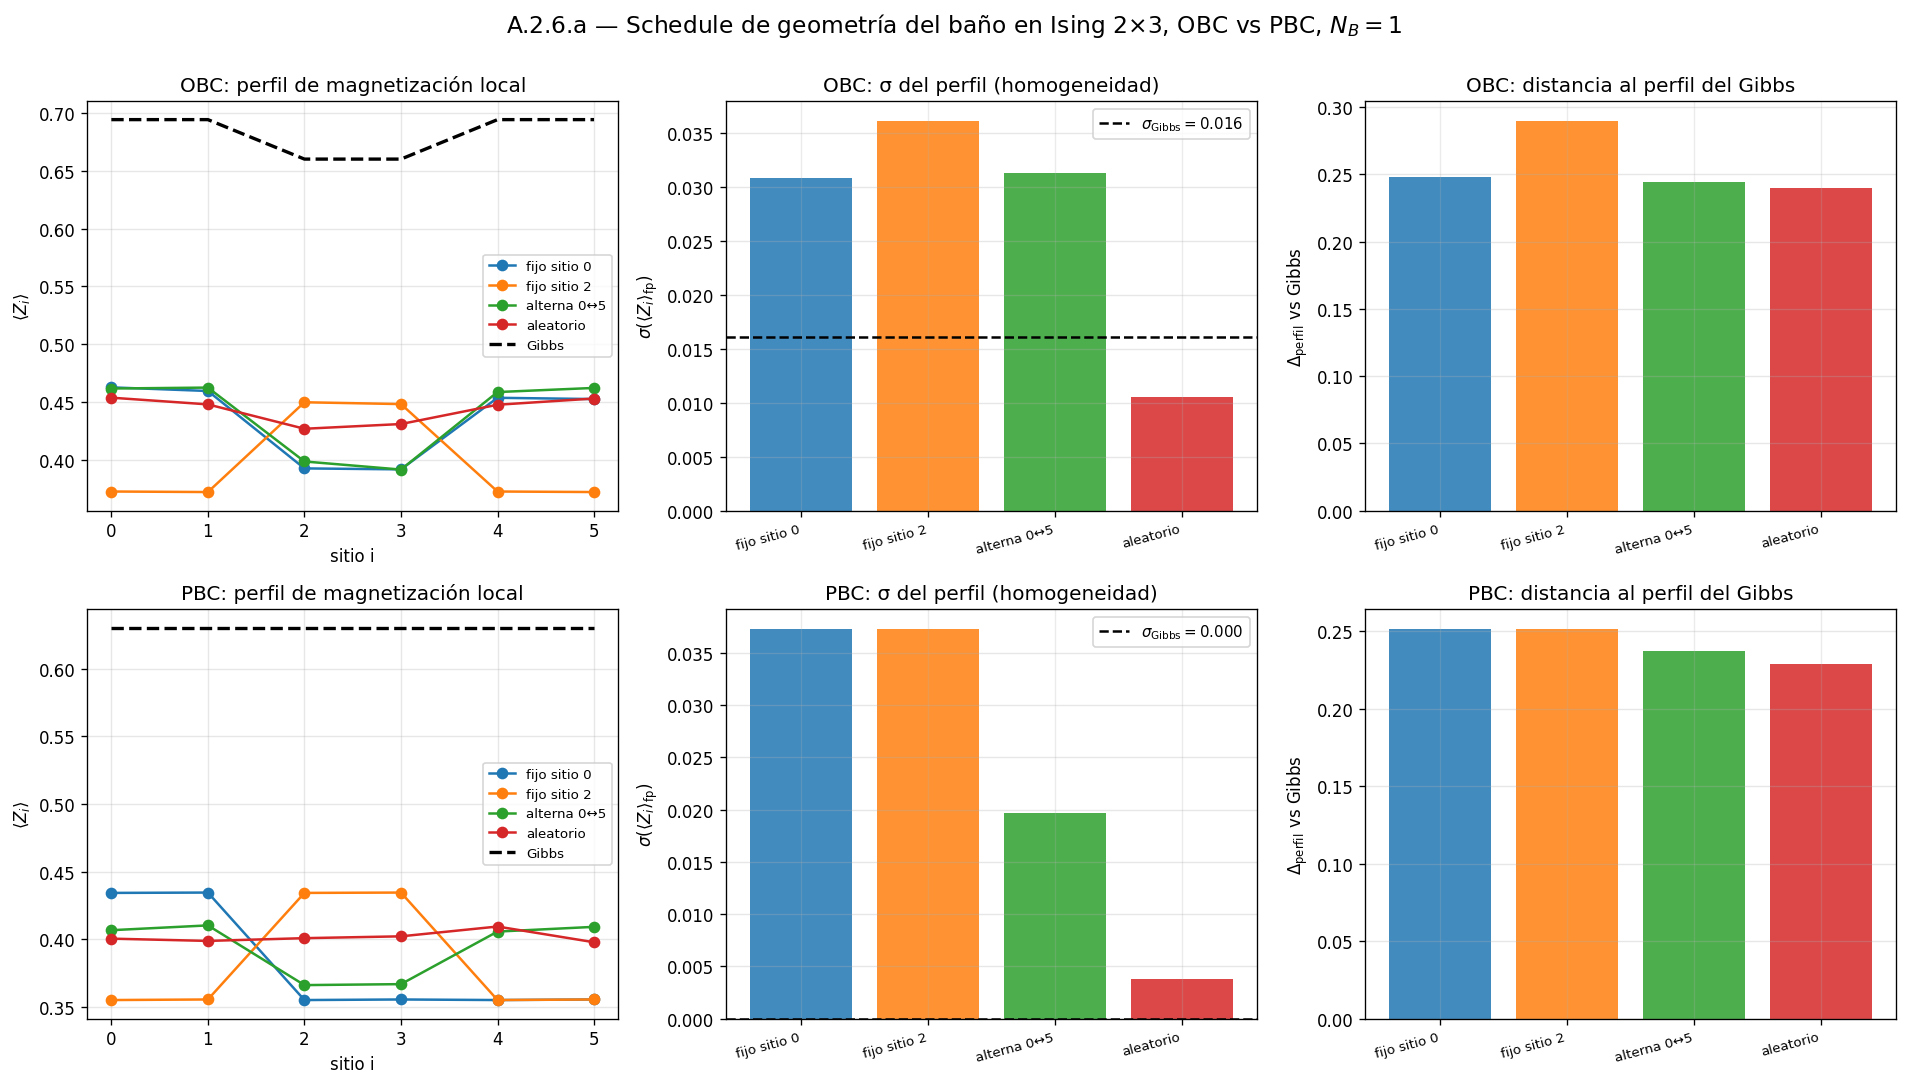

In [ ]:
# Configuración
Lx, Ly = 2, 3
n_sys = Lx * Ly
common = dict(J=0.5, g=1.0, h=1.0, beta=1.0,
              theta=0.15, delta=0.15, MT=25, n_cycles=400)

Z_mats = [local_Z_matrix(n_sys, i) for i in range(n_sys)]

schedules = [
    ("fijo sitio 0",  lambda c, rng: 0),
    ("fijo sitio 2",  lambda c, rng: 2),
    ("alterna 0↔5",   lambda c, rng: 0 if c % 2 == 0 else 5),
    ("aleatorio",     lambda c, rng: int(rng.integers(0, n_sys))),
]

# Ejecutamos para OBC y para PBC
all_results = {}
for periodic, bc_label in [(False, "OBC"), (True, "PBC")]:
    print(f"\n{'='*60}")
    print(f"Condiciones de contorno: {bc_label}")
    print(f"{'='*60}")

    # Gibbs de referencia para esta BC
    cfg_ref = build_ising_cfg_single_bath(
        Lx=Lx, Ly=Ly, target_site=0,
        **{**common, "n_cycles": 1, "periodic": periodic},
    )
    compiled_ref = compile_protocol(cfg_ref)
    rho_g = gibbs_state(compiled_ref["Hs_mat"], common["beta"])
    mz_gibbs = np.array([float(np.real(np.trace(rho_g @ Zi))) for Zi in Z_mats])
    sigma_gibbs = float(np.std(mz_gibbs))

    print(f"Gibbs <Z_i>: {[f'{x:+.3f}' for x in mz_gibbs]}")
    print(f"σ(Gibbs)   = {sigma_gibbs:.4f}\n")

    rows = []
    for label, schedule_fn in schedules:
        t0 = time.time()
        rho_fp, Hs = run_with_geometry_schedule(
            Lx=Lx, Ly=Ly, schedule_fn=schedule_fn,
            periodic=periodic, **common,
        )
        mz_profile = np.array([
            float(np.real(np.trace(rho_fp @ Zi))) for Zi in Z_mats
        ])
        sigma_fp = float(np.std(mz_profile))
        delta_perfil = float(np.sqrt(np.mean((mz_profile - mz_gibbs) ** 2)))
        rows.append(dict(
            label=label,
            mz_profile=mz_profile.tolist(),
            sigma=sigma_fp,
            delta_perfil=delta_perfil,
        ))
        print(f"  [{time.time()-t0:5.1f}s] {label:18s}: "
              f"σ(perfil)={sigma_fp:.4f}, "
              f"Δ_perfil={delta_perfil:.4f}")

    all_results[bc_label] = dict(
        rows=rows,
        mz_gibbs=mz_gibbs.tolist(),
        sigma_gibbs=sigma_gibbs,
    )

# Tabla resumen
df_summary = pd.DataFrame([
    dict(BC=bc, geometria=r["label"],
         sigma_perfil=round(r["sigma"], 4),
         delta_perfil=round(r["delta_perfil"], 4))
    for bc, data in all_results.items()
    for r in data["rows"]
])
display(df_summary)

# Plots: 2 filas (OBC, PBC) × 3 columnas (perfil, σ, Δ_perfil)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
sites_x = np.arange(n_sys)
colors_g = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for row_idx, (bc_label, data) in enumerate(all_results.items()):
    rows = data["rows"]
    mz_gibbs = data["mz_gibbs"]
    sigma_gibbs = data["sigma_gibbs"]

    # Panel 1: perfiles superpuestos
    ax = axes[row_idx, 0]
    for r, color in zip(rows, colors_g):
        ax.plot(sites_x, r["mz_profile"], 'o-', color=color, label=r["label"])
    ax.plot(sites_x, mz_gibbs, 'k--', lw=2, label="Gibbs")
    ax.set_xlabel("sitio i")
    ax.set_ylabel(r"$\langle Z_i\rangle$")
    ax.set_title(f"{bc_label}: perfil de magnetización local")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Panel 2: σ del perfil
    ax = axes[row_idx, 1]
    labels = [r["label"] for r in rows]
    sigmas = [r["sigma"] for r in rows]
    ax.bar(np.arange(len(labels)), sigmas, color=colors_g, alpha=0.85)
    ax.axhline(sigma_gibbs, ls='--', color='k', lw=1.5,
               label=f"$\\sigma_{{\\rm Gibbs}}={sigma_gibbs:.3f}$")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
    ax.set_ylabel(r"$\sigma(\langle Z_i\rangle_{\rm fp})$")
    ax.set_title(f"{bc_label}: σ del perfil (homogeneidad)")
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Panel 3: Δ_perfil (la métrica correcta)
    ax = axes[row_idx, 2]
    deltas = [r["delta_perfil"] for r in rows]
    ax.bar(np.arange(len(labels)), deltas, color=colors_g, alpha=0.85)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
    ax.set_ylabel(r"$\Delta_{\rm perfil}$ vs Gibbs")
    ax.set_title(f"{bc_label}: distancia al perfil del Gibbs")
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    f"A.2.6.a — Schedule de geometría del baño en Ising {Lx}×{Ly}, "
    "OBC vs PBC, $N_B=1$",
    fontsize=14, y=1.00,
)
plt.tight_layout()
plt.show()



El experimento separa claramente **homogeneidad espacial** y **calidad del Gibbs**.

1. **La métrica de simetría depende de las condiciones de contorno.**  
   Con PBC, el Hamiltoniano respeta simetría traslacional y el Gibbs tiene $\sigma_{\rm Gibbs}\simeq0$. En OBC, esquinas, bordes y sitios centrales no son equivalentes, de modo que el propio Gibbs ya presenta una pequeña asimetría espacial. Por eso $\sigma(<Z_i>)$ solo debe interpretarse como métrica de calidad cuando el Hamiltoniano tiene la simetría que se quiere preservar.

2. **La rotación aleatoria homogeneiza el perfil, pero no necesariamente acerca el estado al Gibbs.**  
   Los schedules fijos concentran el residuo en sitios concretos, mientras que la rotación aleatoria reparte el error de forma más uniforme. Sin embargo, la distancia de perfil al Gibbs cambia poco entre schedules. Es decir, rotar el sitio mejora la simetría visual del perfil, pero no resuelve por sí sola el sesgo del estado estacionario.

3. **La palanca dominante no es el schedule, sino el número de baños.**  
   La calidad global del estado preparado depende más de $N_B$, $h$, $M_T$ y $\theta$ que de elegir un sitio fijo o aleatorio cuando $N_B=1$. Por eso el siguiente bloque estudia directamente cómo mejora el resultado al aumentar $N_B$.

En resumen, la receta de rotación aleatoria es útil para no introducir una asimetría artificial, especialmente con PBC. Pero para reducir de verdad el bias frente al Gibbs, la variable relevante es cuántos qubits baño están disponibles.

### A.4.2 Escalado con el número de baños $N_B$

Después de estudiar cómo el schedule afecta a la simetría espacial con $N_B=1$, fijamos el schedule a rotación aleatoria y variamos el número de qubits baño.

Usamos Ising $2\times2$, donde $N_S=4$, porque permite barrer todo el rango $N_B=1,2,3,4$ sin construir un problema demasiado grande. En cada ciclo sorteamos $N_B$ sitios distintos del sistema y los acoplamos a los $N_B$ qubits baño.

El caso $N_B=4=N_S$ corresponde al límite saturado: todos los sitios pueden estar acoplados directamente a un baño en cada ciclo. Los casos $N_B< N_S$ miden cuánto se degrada el protocolo cuando el baño es más pequeño que el sistema.

Las métricas son:

- bias energético $|E_{\rm fp}-E_\beta|$;
- distancia traza $D_{\rm tr}(\rho_{\rm fp},\rho_\beta)$;
- perfil local $<Z_i>$, para comprobar si el estado final reproduce el patrón espacial del Gibbs.

El objetivo es identificar si el beneficio de aumentar $N_B$ es aproximadamente lineal o si satura al acercarse a $N_B=N_S$.

Ising 2×2, N_S=4, schedule = rotación aleatoria
Gibbs: E = -3.4346, σ(<Z_i>) = 0.0000

  [ 18.0s] N_B=1: bias=0.7741, Dtr=0.2259, σ=0.0047
  [104.5s] N_B=2: bias=0.1835, Dtr=0.0608, σ=0.0033
  [843.0s] N_B=3: bias=0.0440, Dtr=0.0176, σ=0.0023
  [1758.6s] N_B=4: bias=0.0089, Dtr=0.0042, σ=0.0000


,NB,bias,dtr,sigma_fp,time_s
0,1,0.774127,0.225897,4.664835e-03,18.0
1,2,0.183473,0.060799,3.286708e-03,104.5
2,3,0.043956,0.017573,2.303423e-03,843.0
3,4,0.008887,0.004150,7.075440e-15,1758.6


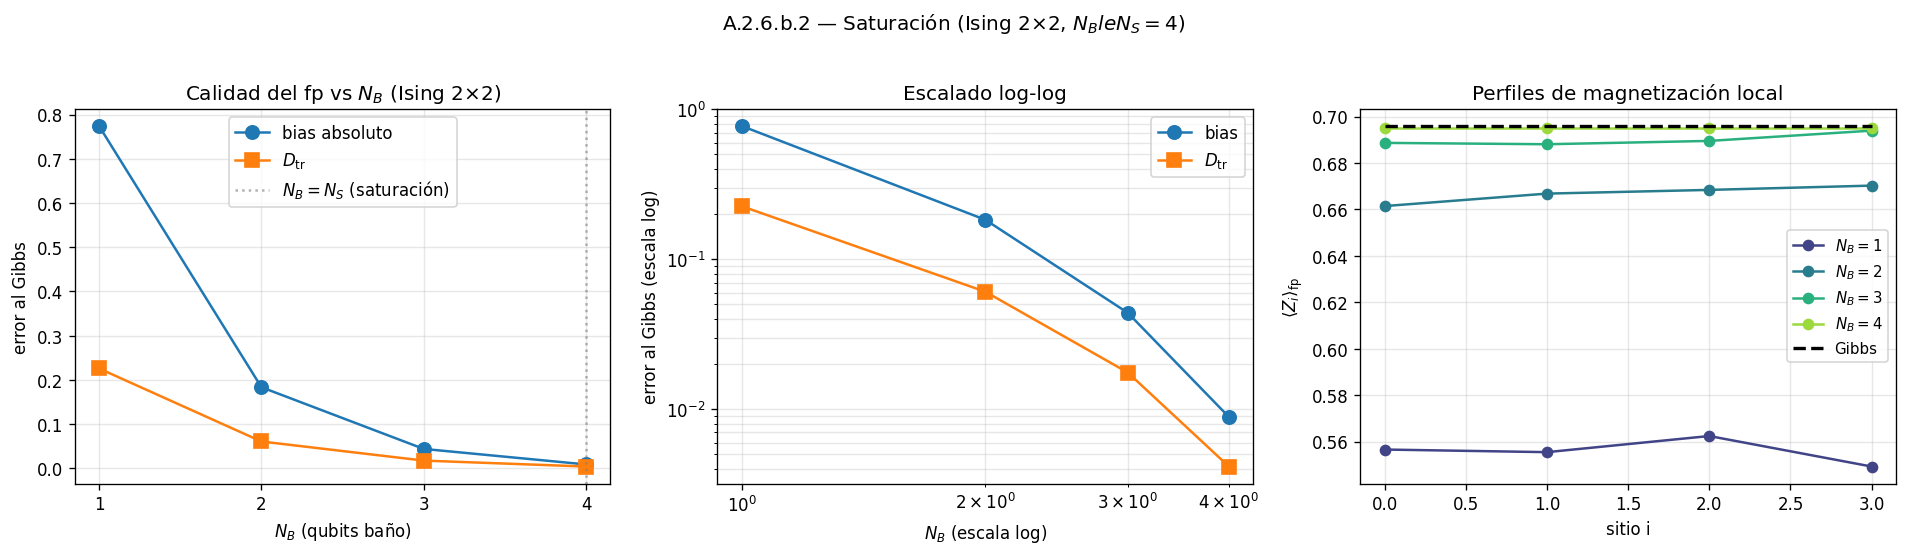

In [ ]:
# Barrido completo en N_B hasta N_B = N_S, en Ising 2×2
# --- Configuración del experimento ---
Lx, Ly = 2, 2
n_sys = Lx * Ly
NB_list = [1, 2, 3, 4]
common = dict(J=0.5, g=1.0, h=1.0, beta=1.0,
              theta=0.15, delta=0.15, MT=25, n_cycles=400)

# Gibbs de referencia (2×2). Usamos build_ising_cfg_multi_bath con un solo
# sitio target porque build_ising_cfg_single_bath puede no existir.
cfg_ref = build_ising_cfg_multi_bath(
    Lx=Lx, Ly=Ly, target_sites=[0],
    **{**common, "n_cycles": 1},
)
compiled_ref = compile_protocol(cfg_ref)
Hs_ref = compiled_ref["Hs_mat"]
rho_g = gibbs_state(Hs_ref, common["beta"])
E_g = float(np.real(np.trace(rho_g @ Hs_ref)))
Z_mats = [mat(make_op(n_sys, [(1.0, {i: "Z"})])) for i in range(n_sys)]
mz_gibbs = [float(np.real(np.trace(rho_g @ Zi))) for Zi in Z_mats]
sigma_gibbs = float(np.std(mz_gibbs))

print(f"Ising {Lx}×{Ly}, N_S={n_sys}, schedule = rotación aleatoria")
print(f"Gibbs: E = {E_g:.4f}, σ(<Z_i>) = {sigma_gibbs:.4f}\n")

# --- Barrido en N_B ---
rows_NB_2x2 = []
for NB in NB_list:
    t0 = time.time()
    rho_fp, Hs = run_with_random_geometry_NB(
        Lx=Lx, Ly=Ly, NB=NB, **common,
    )
    dt = time.time() - t0

    E_fp = float(np.real(np.trace(rho_fp @ Hs)))
    bias = abs(E_fp - E_g)
    dtr = trace_distance_dm(rho_fp, rho_g)
    mz_profile = [float(np.real(np.trace(rho_fp @ Zi))) for Zi in Z_mats]
    sigma_fp = float(np.std(mz_profile))

    rows_NB_2x2.append(dict(
        NB=NB, bias=bias, dtr=dtr, sigma_fp=sigma_fp,
        time_s=round(dt, 1), mz_profile=mz_profile,
    ))
    print(f"  [{dt:5.1f}s] N_B={NB}: bias={bias:.4f}, "
          f"Dtr={dtr:.4f}, σ={sigma_fp:.4f}")

df_NB_2x2 = pd.DataFrame([
    {k: v for k, v in r.items() if k != "mz_profile"}
    for r in rows_NB_2x2
])
display(df_NB_2x2)

# --- Plot: 3 paneles ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: bias y Dtr vs N_B
ax = axes[0]
NB_arr = [r["NB"] for r in rows_NB_2x2]
ax.plot(NB_arr, [r["bias"] for r in rows_NB_2x2],
        'o-', ms=8, color="tab:blue", label="bias absoluto")
ax.plot(NB_arr, [r["dtr"] for r in rows_NB_2x2],
        's-', ms=8, color="tab:orange", label=r"$D_{\rm tr}$")
ax.axvline(n_sys, ls=':', color='gray', alpha=0.6,
           label=r"$N_B = N_S$ (saturación)")
ax.set_xlabel(r"$N_B$ (qubits baño)")
ax.set_ylabel("error al Gibbs")
ax.set_title("Calidad del fp vs $N_B$ (Ising 2×2)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(NB_arr)

# Panel 2: log-log
ax = axes[1]
ax.loglog(NB_arr, [r["bias"] for r in rows_NB_2x2],
          'o-', ms=8, color="tab:blue", label="bias")
ax.loglog(NB_arr, [r["dtr"] for r in rows_NB_2x2],
          's-', ms=8, color="tab:orange", label=r"$D_{\rm tr}$")
ax.set_xlabel(r"$N_B$ (escala log)")
ax.set_ylabel("error al Gibbs (escala log)")
ax.set_title("Escalado log-log")
ax.legend()
ax.grid(alpha=0.3, which='both')

# Panel 3: perfiles superpuestos
ax = axes[2]
sites_x = np.arange(n_sys)
colors_NB = plt.cm.viridis(np.linspace(0.2, 0.85, len(NB_list)))
for row, color in zip(rows_NB_2x2, colors_NB):
    ax.plot(sites_x, row["mz_profile"], 'o-', color=color,
            label=f"$N_B = {row['NB']}$")
ax.plot(sites_x, mz_gibbs, 'k--', lw=2, label="Gibbs")
ax.set_xlabel("sitio i")
ax.set_ylabel(r"$\langle Z_i\rangle_{\rm fp}$")
ax.set_title("Perfiles de magnetización local")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle(
    f"A.2.6.b.2 — Saturación (Ising 2×2, $N_B le N_S = 4$)",
    y=1.02,
)
plt.tight_layout()
plt.show()

El barrido completo en Ising $2\times2$ muestra que $N_B$ es la variable geométrica que más controla la calidad del estado estacionario.

1. **El bias decrece al aumentar $N_B$.**  
   Al pasar de pocos baños al límite $N_B=N_S$, el bias energético y la distancia traza frente al Gibbs disminuyen. Esto confirma que la rotación aleatoria reparte el acoplo en promedio, pero la calidad del estado mejora de verdad cuando hay más canales de enfriamiento activos por ciclo.

2. **La mejora satura cerca de $N_B=N_S$.**  
   Añadir baños es más útil cuando $N_B$ es pequeño. Al acercarse a $N_B=4$, el beneficio marginal disminuye, porque casi todos los sitios ya reciben acoplamiento directo con frecuencia alta.

3. **El perfil $<Z_i>$ se aproxima al Gibbs en el límite saturado.**  
   Para $N_B$ pequeño pueden quedar residuos espaciales visibles. Al aumentar $N_B$, el perfil final se acerca al perfil térmico de referencia, lo que indica que el protocolo no solo mejora la energía global, sino también los observables locales.

La conclusión práctica es que la rotación aleatoria es una buena forma de no privilegiar siempre el mismo sitio, pero no sustituye a tener suficientes baños. En este tamaño, $N_B\sim N_S/2$ ya ofrece un compromiso razonable, mientras que $N_B=N_S$ actúa como referencia saturada.

## A.5 Comparación 1D vs 2D y límite NI → Ising

###  A.5.1  Puntos críticos 1D vs 2D a igual N_S (a $T\to 0$)


La física que distingue 1D y 2D es la naturaleza y la localización de las transiciones de fase:

| Dimensión | Transición | Tipo | Localización |
|---|---|---|---|
| 1D | No térmica | — | ninguna para $\beta$ finito |
| 1D | Cuántica | paramagnético ↔ ferromagnético | $\|J\|=g$ a $T\to 0$ |
| 2D | Térmica | paramagnético ↔ ferromagnético | $\beta_c \approx 0.44/J$ para $g=0$ |
| 2D | Cuántica | paramagnético ↔ ferromagnético | $J_c \approx 0.33 g$ a $T\to 0$ |

Con los tamaños accesibles ($N_S \le 9$) no vemos transiciones reales (son infinitas solo en el límite termodinámico), pero sí **signos cualitativos**: máximos del calor específico, pendientes de la información mutua, perfiles de energía.

En esta subsección comparamos directamente **1D vs 2D** barriendo $J$ a $\beta=1$ fijo.


,dim,geom,N_S,MT,h,J,E_per_site,C_fp,I_halves
0,1D,cadena,4,10,2.0,0.10,-0.7393,1.8256,0.0020
1,2D,2x2,4,10,2.0,0.10,-0.7402,1.8215,0.0053
2,1D,cadena,4,10,2.0,0.30,-0.7623,1.7576,0.0257
3,2D,2x2,4,10,2.0,0.30,-0.7724,1.7341,0.0535
4,1D,cadena,4,10,2.0,0.50,-0.8073,1.6384,0.0697
5,2D,2x2,4,10,2.0,0.50,-0.8417,1.5916,0.1501
6,1D,cadena,4,10,3.0,0.75,-0.9024,1.3878,0.1490
7,2D,2x2,4,10,3.0,0.75,-0.9930,1.3229,0.3192
8,1D,cadena,4,10,4.0,1.00,-1.0083,1.2576,0.2384
9,2D,2x2,4,10,4.0,1.00,-1.1823,1.1621,0.4687


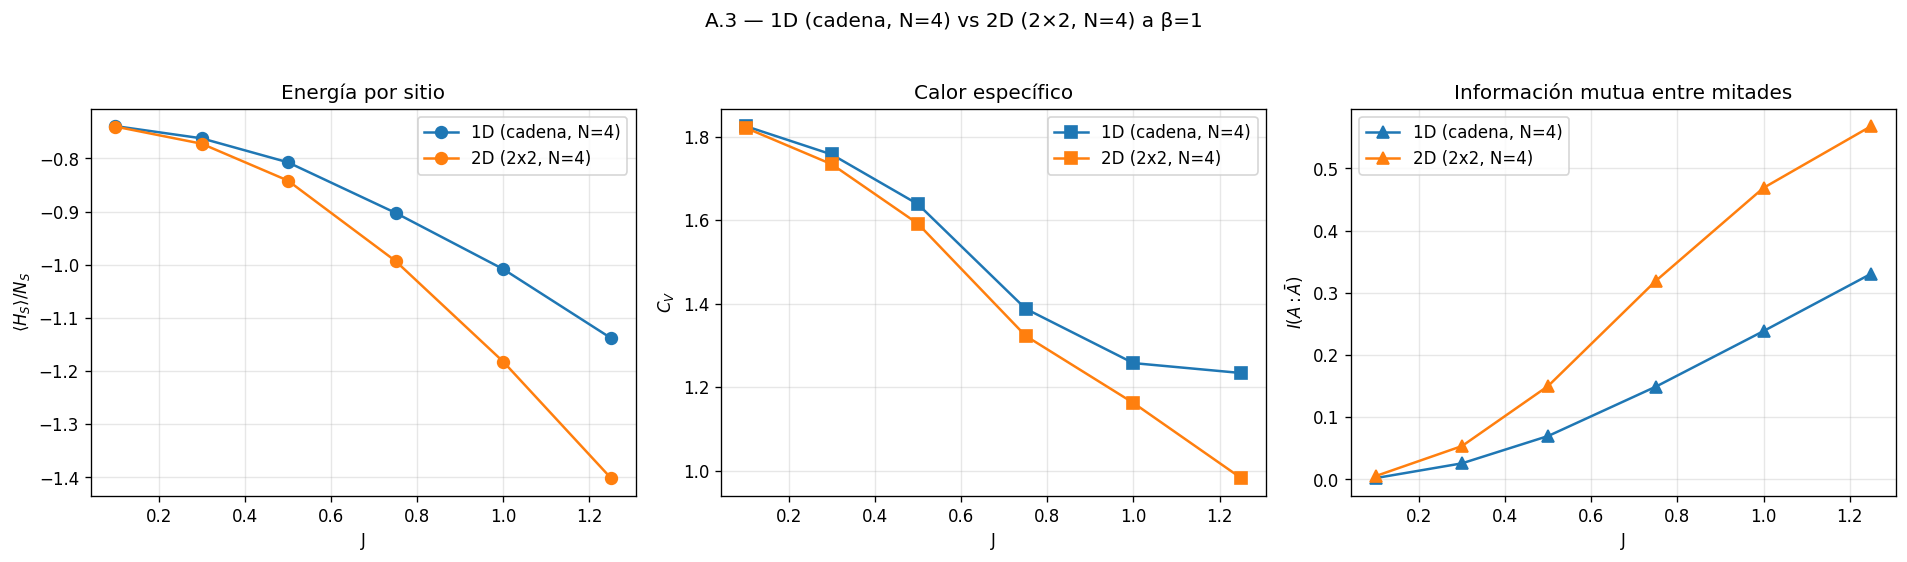

In [ ]:
#  — Comparación J-sweep en 1D vs 2D

J_list_A3 = [0.1, 0.3, 0.5, 0.75, 1.0, 1.25]
rows_A3 = []

for J in J_list_A3:
    # 1D Lx=4 (cadena) — MT auto vía make_params_1d
    p1 = make_params_1d(Lx=4, J=J, beta=1.0, n_cycles=60, theta=0.25)
    out1 = run_ising_case(p1, rho0=maximally_mixed(4), compute_fp=True,
                          fp_mode='late_time', late_fp_burn=80, late_fp_keep=20)
    Hs1 = out1['Hs']; r1 = out1['rho_fp']
    rows_A3.append({
        'dim':        '1D',
        'geom':       'cadena',
        'N_S':        4,
        'MT':         p1['MT'],
        'h':          p1['h'],
        'J':          J,
        'E_per_site': float(expect(Hs1, r1)) / 4,
        'C_fp':       heat_capacity_ising(r1, Hs1, 1.0),
        'I_halves':   mutual_information_halves(r1, 4),
    })

    # 2D 2x2 — MT auto vía make_params_2d
    p2 = make_params_2d(Lx=2, Ly=2, J=J, beta=1.0, n_cycles=60, theta=0.25)
    out2 = run_ising_case(p2, rho0=maximally_mixed(4), compute_fp=True,
                          fp_mode='late_time', late_fp_burn=80, late_fp_keep=20)
    Hs2 = out2['Hs']; r2 = out2['rho_fp']
    rows_A3.append({
        'dim':        '2D',
        'geom':       '2x2',
        'N_S':        4,
        'MT':         p2['MT'],
        'h':          p2['h'],
        'J':          J,
        'E_per_site': float(expect(Hs2, r2)) / 4,
        'C_fp':       heat_capacity_ising(r2, Hs2, 1.0),
        'I_halves':   mutual_information_halves(r2, 4),
    })

df_A3 = pd.DataFrame(rows_A3)
display(df_A3.round(4))

# Etiqueta combinada para los plots, derivada de las columnas estructuradas
df_A3['label'] = df_A3['dim'] + ' (' + df_A3['geom'] + ', N=' + df_A3['N_S'].astype(str) + ')'

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for label in df_A3['label'].unique():
    sub = df_A3[df_A3['label'] == label]
    axes[0].plot(sub['J'], sub['E_per_site'], 'o-', ms=7, label=label)
    axes[1].plot(sub['J'], sub['C_fp'],       's-', ms=7, label=label)
    axes[2].plot(sub['J'], sub['I_halves'],   '^-', ms=7, label=label)

axes[0].set_xlabel('J'); axes[0].set_ylabel(r'$\langle H_S \rangle / N_S$')
axes[0].set_title('Energía por sitio')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('J'); axes[1].set_ylabel(r'$C_V$')
axes[1].set_title('Calor específico')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].set_xlabel('J'); axes[2].set_ylabel(r'$I(A:\bar A)$')
axes[2].set_title('Información mutua entre mitades')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('A.3 — 1D (cadena, N=4) vs 2D (2×2, N=4) a β=1', y=1.03)
plt.tight_layout(); plt.show()


La comparación a igual tamaño $N_S=4$ y $\beta=1$ separa el efecto de la geometría del protocolo del efecto físico del Hamiltoniano.

1. **Las energías coinciden en el límite no interactuante.**  
   Para $J=0$, 1D y 2D describen el mismo sistema no interactuante. Al aumentar $J$, las curvas se separan: el retículo $2\times2$ alcanza energías por sitio más bajas porque tiene más enlaces por sitio y, por tanto, mayor contribución de interacción.

2. **El calor específico depende del punto del barrido.**  
   A $\beta=1$ fijo, la curva 2D queda por debajo de la 1D para $J$ moderado-grande. Esto no significa que 2D tenga menos física térmica, sino que entra antes en el régimen ordenado y la varianza de energía cae antes. Para ver el pico térmico hay que barrer $\beta$ a $J$ fijo, como en A.2.2.

3. **La información mutua distingue claramente las geometrías.**  
   La 2D genera más correlación entre mitades porque la partición corta más enlaces que en la cadena 1D. La diferencia entre curvas es física, no algorítmica.

El mensaje de control es que el protocolo no necesita una modificación especial para pasar de 1D a 2D. Las diferencias observadas vienen del Hamiltoniano y de su conectividad, no de un fallo de la receta de preparación.

### A.5.2  Del límite NI al Ising 1D


Antes de entrar en diagnósticos más finos, conviene fijar un control físico muy claro: qué cambia al pasar del límite **no interactuante** ($J=0$) al caso **interactuante** ($J>0$).

Aquí usamos el mismo protocolo y el mismo tamaño de sistema, y barrimos $J$ desde 0. De este modo separamos dos preguntas:

1. **física del modelo**: qué correlaciones aparecen al encender la interacción;
2. **calidad del protocolo**: con qué precisión aproxima el estado Gibbs en cada punto.

Las magnitudes que seguimos son:

- **bias energético por sitio**,
- **distancia traza a Gibbs**,
- **información mutua entre mitades**.

La lectura de esta sección debe ser comparativa: no se trata de demostrar criticidad, sino de ver con claridad qué observables son sensibles a la interacción.

,dim,geom,N_S,MT,h,J,E_per_site,bias_per_site,Dtr,F_gibbs,I_halves
0,1D,cadena,4,10,2.0,0.00,-0.7365,0.0251,0.0336,0.9986,0.0000
1,1D,cadena,4,10,2.0,0.10,-0.7393,0.0249,0.0347,0.9984,0.0020
2,1D,cadena,4,10,2.0,0.30,-0.7623,0.0227,0.0324,0.9987,0.0257
3,1D,cadena,4,10,2.0,0.50,-0.8073,0.0191,0.0309,0.9988,0.0697
4,1D,cadena,4,10,3.0,0.75,-0.9024,0.0044,0.0181,0.9996,0.1490
5,1D,cadena,4,10,4.0,1.00,-1.0083,0.0084,0.0335,0.9987,0.2384
6,1D,cadena,4,10,5.0,1.25,-1.1379,0.0136,0.0494,0.9973,0.3307


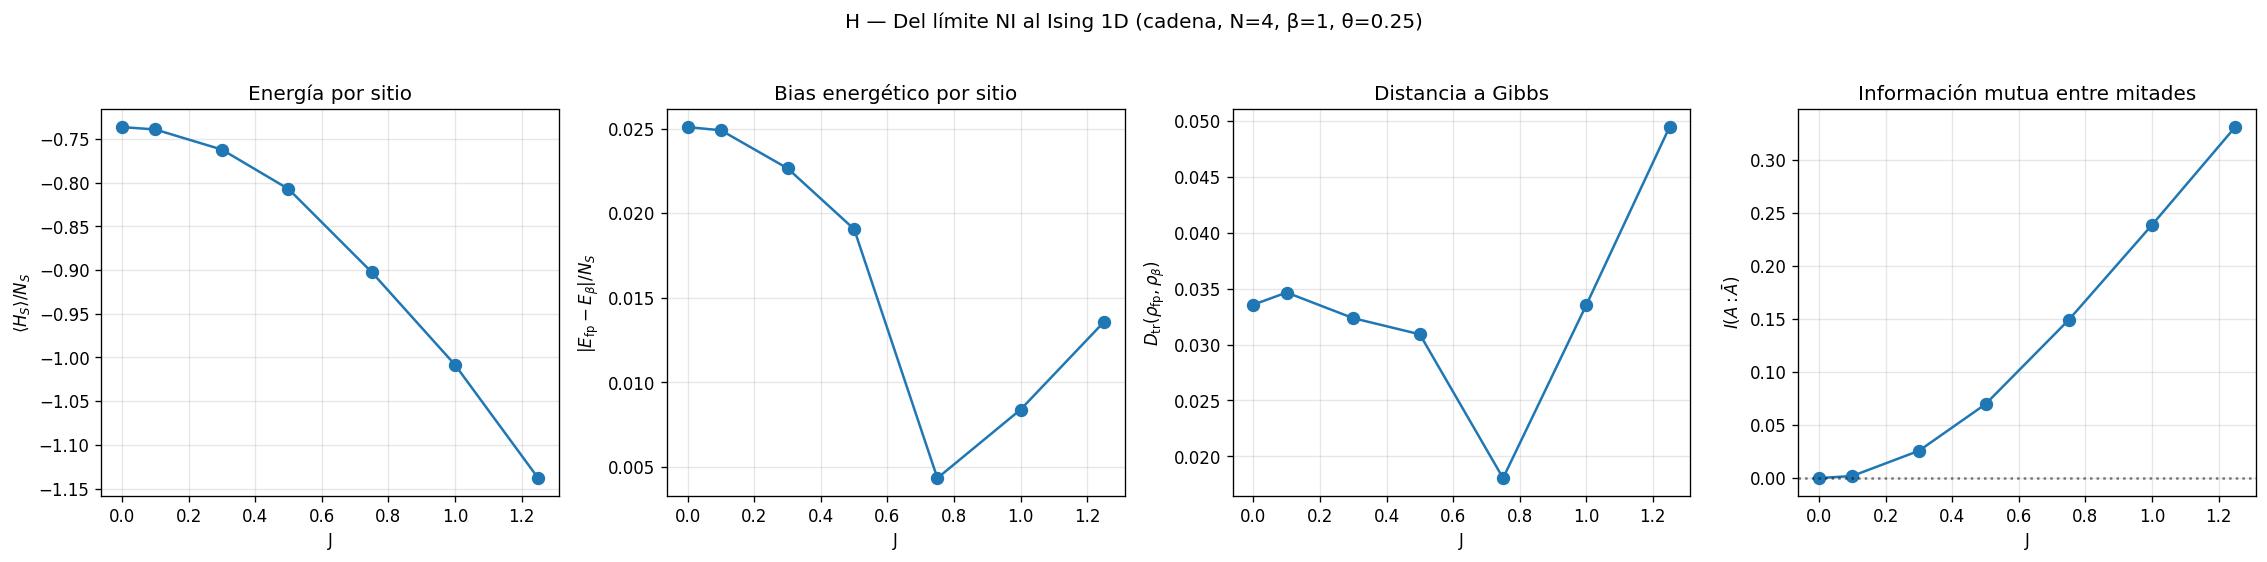

In [ ]:
# Del límite NI (J=0) al Ising 1D

J_list_H = [0.0, 0.1, 0.3, 0.5, 0.75, 1.0, 1.25]
rows_H = []

N_S = 4
for J in J_list_H:
    # MT auto vía make_params_1d (h depende de J ⇒ MT varía con J)
    p = make_params_1d(Lx=N_S, J=J, beta=1.0, n_cycles=120, theta=0.25)

    out = run_ising_case(
        p,
        rho0=maximally_mixed(N_S),
        compute_fp=True,
        fp_mode='late_time',
        late_fp_burn=80,
        late_fp_keep=20,
    )

    rho_fp = out['rho_fp']
    rho_g  = out['rho_g']
    Hs     = out['Hs']

    E_fp = float(expect(Hs, rho_fp))
    E_g  = float(expect(Hs, rho_g))

    rows_H.append({
        'dim':           '1D',
        'geom':          'cadena',
        'N_S':           N_S,
        'MT':            p['MT'],
        'h':             p['h'],
        'J':             J,
        'E_per_site':    E_fp / N_S,
        'bias_per_site': abs(E_fp - E_g) / N_S,
        'Dtr':           trace_distance_dm(rho_fp, rho_g),
        'F_gibbs':       fidelity_dm(rho_fp, rho_g),
        'I_halves':      mutual_information_partition(rho_fp, list(range(N_S // 2)), N_S),
    })

df_H = pd.DataFrame(rows_H)
display(df_H.round(4))

fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))

axes[0].plot(df_H['J'], df_H['E_per_site'], 'o-', ms=7)
axes[0].set_title('Energía por sitio')
axes[0].set_xlabel('J')
axes[0].set_ylabel(r'$\langle H_S\rangle/N_S$')
axes[0].grid(alpha=0.3)

axes[1].plot(df_H['J'], df_H['bias_per_site'], 'o-', ms=7)
axes[1].set_title('Bias energético por sitio')
axes[1].set_xlabel('J')
axes[1].set_ylabel(r'$|E_{\rm fp}-E_\beta|/N_S$')
axes[1].grid(alpha=0.3)

axes[2].plot(df_H['J'], df_H['Dtr'], 'o-', ms=7)
axes[2].set_title('Distancia a Gibbs')
axes[2].set_xlabel('J')
axes[2].set_ylabel(r'$D_{\rm tr}(\rho_{\rm fp},\rho_\beta)$')
axes[2].grid(alpha=0.3)

axes[3].plot(df_H['J'], df_H['I_halves'], 'o-', ms=7)
axes[3].axhline(0.0, ls=':', color='k', alpha=0.5)
axes[3].set_title('Información mutua entre mitades')
axes[3].set_xlabel('J')
axes[3].set_ylabel(r'$I(A:\bar A)$')
axes[3].grid(alpha=0.3)

plt.suptitle('H — Del límite NI al Ising 1D (cadena, N=4, β=1, θ=0.25)', y=1.03)
plt.tight_layout()
plt.show()

 
El barrido en $J$ conecta el límite no interactuante con el régimen Ising 1D correlacionado. Al aumentar $J$, la energía por sitio disminuye y la mutual information entre mitades crece desde prácticamente cero, mostrando que el estado térmico desarrolla correlaciones reales.

El bias energético y la distancia traza no crecen de forma monótona: ambos presentan un mínimo en una región intermedia, alrededor de $J\simeq0.5$–$0.75$. Esto indica que la calidad del protocolo no depende solo de la intensidad de la interacción, sino del alineamiento entre el filtro y las frecuencias relevantes del Hamiltoniano.

[A.5.2.b] N=2, J=0.00
[A.5.2.b] N=2, J=0.30
[A.5.2.b] N=2, J=0.50
[A.5.2.b] N=2, J=0.70
[A.5.2.b] N=2, J=1.00
[A.5.2.b] N=3, J=0.00
[A.5.2.b] N=3, J=0.30
[A.5.2.b] N=3, J=0.50
[A.5.2.b] N=3, J=0.70
[A.5.2.b] N=3, J=1.00
[A.5.2.b] N=4, J=0.00
[A.5.2.b] N=4, J=0.30
[A.5.2.b] N=4, J=0.50
[A.5.2.b] N=4, J=0.70
[A.5.2.b] N=4, J=1.00


,N_S,J,bias_per_qubit,Dtr_gibbs,I_halves,equilibration_cycles
0,2,0.0,0.024011,0.021005,-0.000000,NaN
1,2,0.3,0.021936,0.020705,0.022713,NaN
2,2,0.5,0.018597,0.019532,0.062815,NaN
3,2,0.7,0.000384,0.006956,0.122056,93.0
4,2,1.0,0.000987,0.004600,0.219408,NaN
5,3,0.0,0.024011,0.027563,0.000000,NaN
6,3,0.3,0.021873,0.028135,0.026154,NaN
7,3,0.5,0.018069,0.025657,0.069626,NaN
8,3,0.7,0.000401,0.007080,0.127237,111.0
9,3,1.0,0.001785,0.008677,0.225050,NaN


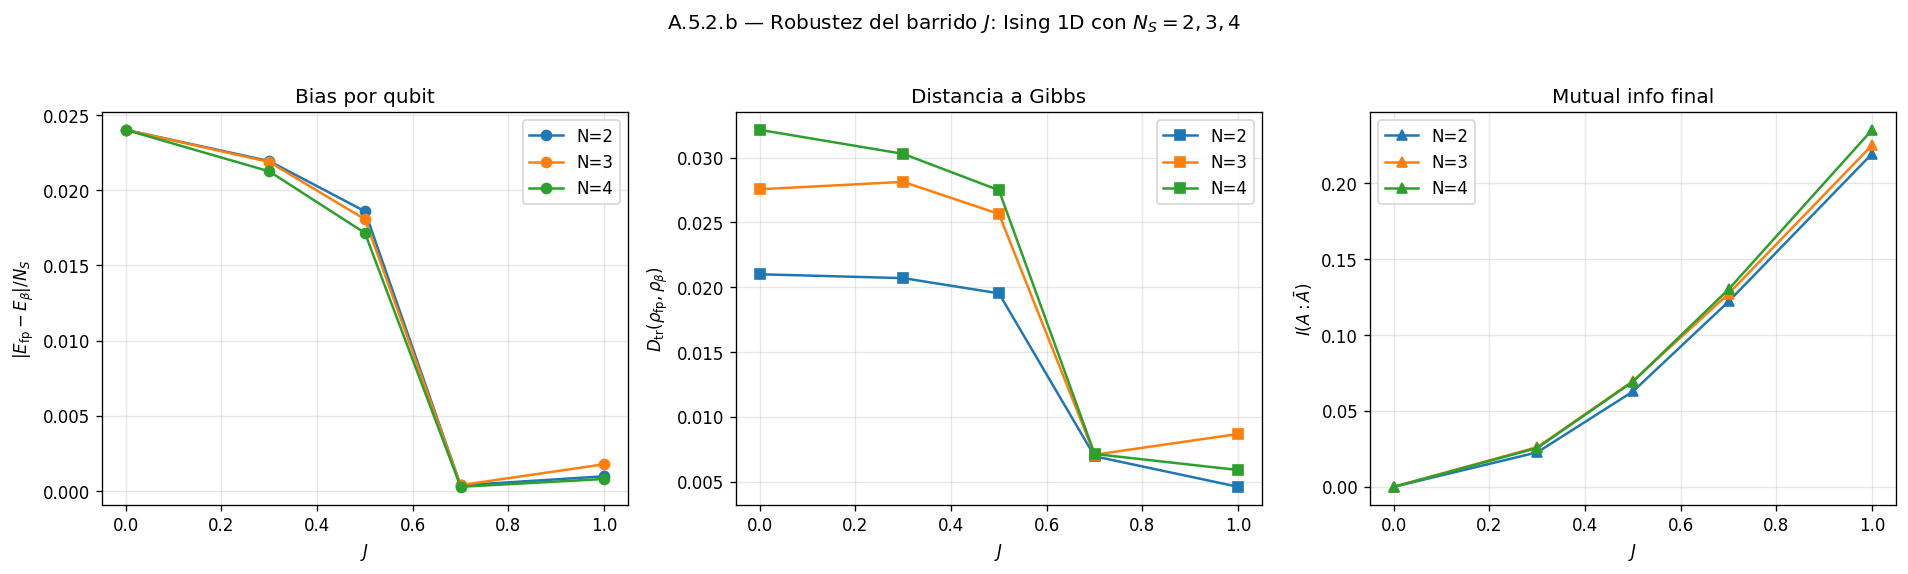

In [ ]:
# A.5.2.b — Robustez con tamaño: barrido en J para Ising 1D N_S=2,3,4
# Versión fiel a scripts/run_NB03_Afinal.py, sin pickle.

def make_params_Afinal_1d(Lx, J, beta=1.0, MT=10, n_cycles=120, theta=0.25):
    g = 1.0
    return dict(
        Lx=int(Lx),
        Ly=1,
        J=float(J),
        g=g,
        h=max(2.0 * g, 4.0 * float(J)),
        beta=float(beta),
        theta=float(theta),
        delta=np.pi / 40.0,
        MT=int(MT),
        n_cycles=int(n_cycles),
        sys_A="Y",
        bath_A="Y",
        periodic=False,              # IMPORTANTE: reproduce el script original
        randomize=False,
        randomization_lambda=0.0,
        seed=1234,
        rewind=False,
    )

N_list_Afinal = [2, 3, 4]
J_list_Afinal = [0.0, 0.3, 0.5, 0.7, 1.0]

epsilon_Afinal = 1e-2
rows_Afinal = []

for n_sys in N_list_Afinal:
    for J in J_list_Afinal:
        print(f"[A.5.2.b] N={n_sys}, J={J:.2f}")

        params = make_params_Afinal_1d(
            Lx=n_sys,
            J=J,
            beta=1.0,
            MT=10,
            n_cycles=120,
            theta=0.25,
        )

        out = run_ising_case(
            params,
            rho0=maximally_mixed(n_sys),
            compute_fp=True,
            fp_mode="superop",        # IMPORTANTE: reproduce el script original
        )

        rho_ref = out["rho_fp"] if out["rho_fp"] is not None else out["res"]["rhos"][-1]

        D_traj = np.array(
            [trace_distance_dm(rho, out["rho_g"]) for rho in out["res"]["rhos"]],
            dtype=float,
        )
        below = np.where(D_traj <= epsilon_Afinal)[0]
        n_star = int(below[0]) if len(below) > 0 else None

        rows_Afinal.append({
            "N_S": int(n_sys),
            "J": float(J),
            "bias_per_qubit": abs(float(out["Efp"]) - float(out["Eg"])) / n_sys,
            "Dtr_gibbs": float(trace_distance_dm(rho_ref, out["rho_g"])),
            "I_halves": float(mutual_information_halves(rho_ref, n_sys)),
            "equilibration_cycles": n_star,
        })

df_Afinal = pd.DataFrame(rows_Afinal)
display(df_Afinal.round(6))


fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

for n_sys in sorted(df_Afinal["N_S"].unique()):
    sub = df_Afinal[df_Afinal["N_S"] == n_sys].sort_values("J")

    axes[0].plot(
        sub["J"],
        sub["bias_per_qubit"],
        "o-",
        label=f"N={n_sys}",
    )

    axes[1].plot(
        sub["J"],
        sub["Dtr_gibbs"],
        "s-",
        label=f"N={n_sys}",
    )

    axes[2].plot(
        sub["J"],
        sub["I_halves"],
        "^-",
        label=f"N={n_sys}",
    )

axes[0].set_xlabel(r"$J$")
axes[0].set_ylabel(r"$|E_{\rm fp}-E_\beta|/N_S$")
axes[0].set_title("Bias por qubit")

axes[1].set_xlabel(r"$J$")
axes[1].set_ylabel(r"$D_{\rm tr}(\rho_{\rm fp},\rho_\beta)$")
axes[1].set_title("Distancia a Gibbs")

axes[2].set_xlabel(r"$J$")
axes[2].set_ylabel(r"$I(A:\bar A)$")
axes[2].set_title("Mutual info final")

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(
    r"A.5.2.b — Robustez del barrido $J$: Ising 1D con $N_S=2,3,4$",
    y=1.03,
)

plt.tight_layout()
plt.show()

 
El barrido con $N_S=2,3,4$ muestra que la tendencia anterior no es exclusiva del caso $N_S=4$. Para los tres tamaños, el bias por qubit y la distancia a Gibbs disminuyen al entrar en el régimen interactuante intermedio, mientras que la mutual information final crece con $J$.

Por tanto, introducir interacción no deteriora el protocolo en estos parámetros. Al contrario, el régimen Ising correlacionado resulta más favorable que el límite no interactuante para la aproximación al Gibbs, al menos en los tamaños pequeños estudiados.

## A.6 Resonancias, randomización y rewind

### A.6.1 Análisis espectral y elección óptima de h para A_S = Y

Aunque el paper usa (Y+Z)/√2 en sus simulaciones 2D con pocos auxiliares y geometría aleatorizada, aquí tomamos A_S=Y como operador base porque:
(i) es una elección permitida explícitamente por el argumento general del paper,
(ii) coincide con el protocolo base del notebook,
(iii) en nuestros barridos 2×2 da menor bias y menor Dtr que la mezcla YZ.

Fracción del peso espectral capturada por cada filtro:
  h=1                                 captura 70.4% del peso
  h=2 (paper, $\max(2g, 4J)$)         captura 90.3% del peso
  h=3 (óptimo según barrido)          captura 91.1% del peso


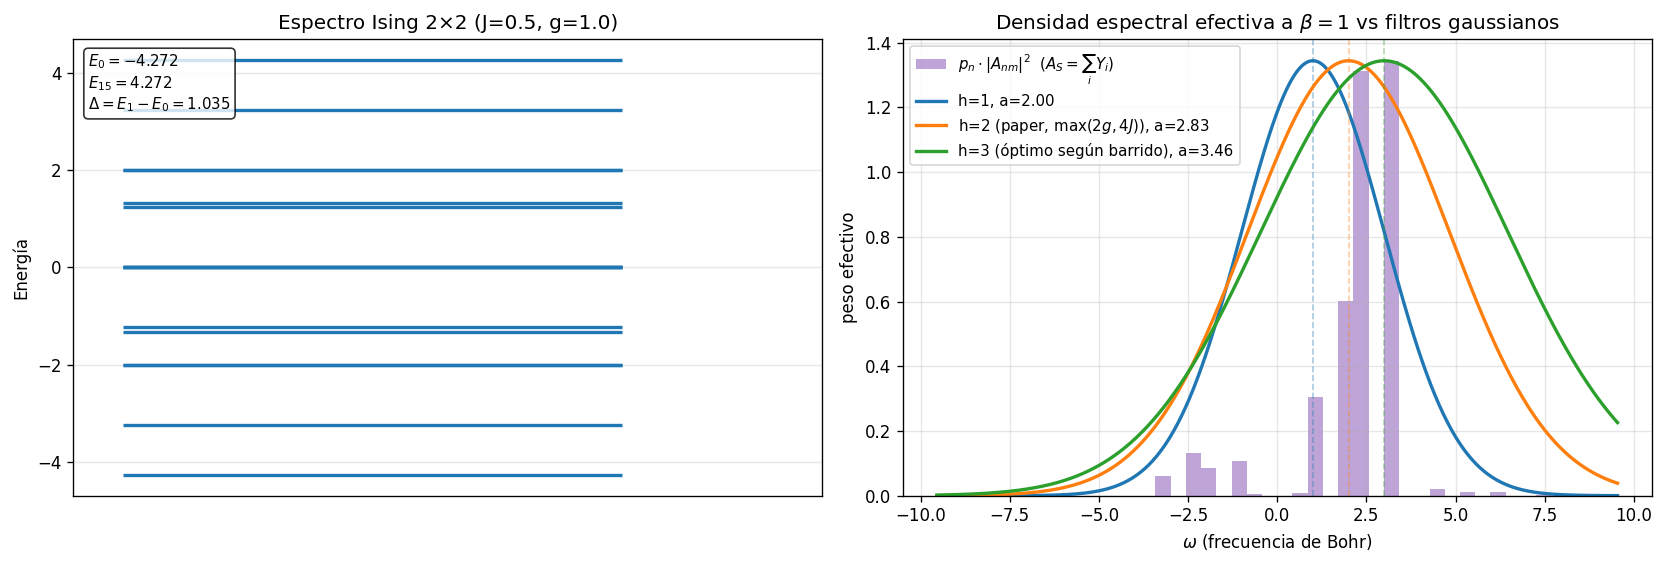

In [ ]:
# Análisis espectral del Ising 2×2 y elección de h
# 
# Pregunta: ¿es óptima la prescripción h = max(2g, 4J) del paper?
# Estrategia: pesar las transiciones de Bohr ω_nm = E_n - E_m por su
# relevancia física (probabilidad de origen × elemento de matriz del
# operador de acoplo), y comparar con la posición y anchura del filtro
# gaussiano para distintos valores de h.

# --- Hamiltoniano Ising 2×2 (mismos parámetros físicos del paper) ---
J, g, beta = 0.5, 1.0, 1.0

cfg_spec = build_ising_2d_cfg_mix(
    Lx=2, Ly=2, sys_op_spec="Y", bath_op_spec="Y",
    J=J, g=g, h=2.0, beta=beta,           # h aquí es solo nominal, no afecta al espectro
    theta=0.15, delta=np.pi/40, MT=10, n_cycles=1,
)
compiled_spec = compile_protocol(cfg_spec)
Hs = compiled_spec["Hs_mat"]

# Diagonalización
evals, evecs = np.linalg.eigh(Hs)
idx = np.argsort(evals)
evals, evecs = evals[idx], evecs[:, idx]
n = len(evals)

# Poblaciones de Boltzmann
pops = np.exp(-beta * (evals - evals[0]))
pops /= pops.sum()

# Operador de acoplo A_S = sum_i Y_i (suma sobre sitios, lo que el protocolo aplica)
A_mat_energy_basis = np.zeros((n, n), dtype=float)
for i in range(4):
    A_i = mat(make_op(4, [(1.0, {i: "Y"})]))
    A_ij = evecs.conj().T @ A_i @ evecs
    A_mat_energy_basis += np.abs(A_ij) ** 2

# Densidad espectral efectiva: cada transición n → m pesada por p_n · |A_nm|²
freqs, weights = [], []
for i in range(n):
    for j in range(n):
        if i != j:
            freqs.append(evals[j] - evals[i])
            weights.append(pops[i] * float(A_mat_energy_basis[j, i]))
freqs = np.array(freqs)
weights = np.array(weights)

# --- Plot: dos paneles ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Panel 1: niveles de energía
ax = axes[0]
for i, e in enumerate(evals):
    ax.hlines(e, 0, 1, color="tab:blue", lw=2)
ax.set_xlim(-0.1, 1.4)
ax.set_xticks([])
ax.set_ylabel("Energía")
ax.set_title(f"Espectro Ising 2×2 (J={J}, g={g})")
ax.grid(alpha=0.3)
ax.text(0.02, 0.97,
        f"$E_0 = {evals[0]:.3f}$\n"
        f"$E_{{15}} = {evals[-1]:.3f}$\n"
        f"$\\Delta = E_1 - E_0 = {evals[1]-evals[0]:.3f}$",
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel 2: densidad espectral efectiva con filtros gaussianos encima
ax = axes[1]
counts, bin_edges, _ = ax.hist(
    freqs, bins=40, weights=weights,
    alpha=0.6, color="tab:purple",
    label=r"$p_n \cdot |A_{nm}|^2$  ($A_S = \sum_i Y_i$)",
)
y_max = counts.max() if counts.max() > 0 else 1.0
omega_grid = np.linspace(freqs.min() - 1, freqs.max() + 1, 500)

h_values_compare = [
    (1.0, "tab:blue",   "h=1"),
    (2.0, "tab:orange", "h=2 (paper, $\\max(2g, 4J)$)"),
    (3.0, "tab:green",  "h=3 (óptimo según barrido)"),
]

# Calcular fracción de peso capturada por cada filtro
print("Fracción del peso espectral capturada por cada filtro:")
total_w = weights.sum()
for h_val, color, lbl in h_values_compare:
    a_val = np.sqrt(4 * h_val / beta)
    gauss = np.exp(-(omega_grid - h_val) ** 2 / (2 * a_val ** 2))
    ax.plot(omega_grid, gauss * y_max, color=color, lw=2,
            label=f"{lbl}, a={a_val:.2f}")
    ax.axvline(h_val, color=color, ls="--", lw=1, alpha=0.4)

    # Fracción capturada (integral discreta del histograma · filtro)
    captured = sum(w * np.exp(-(f - h_val)**2 / (2*a_val**2))
                   for f, w in zip(freqs, weights))
    print(f"  {lbl:35s} captura {captured/total_w:.1%} del peso")

ax.set_xlabel(r"$\omega$ (frecuencia de Bohr)")
ax.set_ylabel("peso efectivo")
ax.set_title(r"Densidad espectral efectiva a $\beta=1$ vs filtros gaussianos")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Barrido en h con A_S = (Y+Z)/sqrt(2), Ising 2×2, J=0.5, g=1, β=1

  [71.3s] h=0.5: bias=1.6272, Dtr=0.3986
  [77.6s] h=1.0: bias=0.7371, Dtr=0.2042
  [77.6s] h=1.5: bias=0.3394, Dtr=0.1102
  [120.8s] h=2.0: bias=0.1575, Dtr=0.0584
  [129.9s] h=3.0: bias=0.0427, Dtr=0.0242
  [124.6s] h=4.0: bias=0.0459, Dtr=0.0301
  [134.1s] h=4.5: bias=0.0643, Dtr=0.0382
  [121.4s] h=5.0: bias=0.0896, Dtr=0.0493


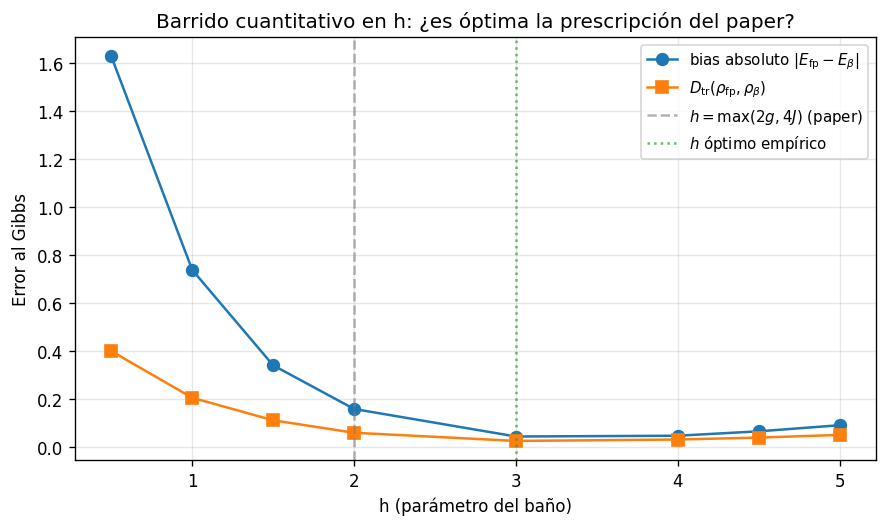

In [ ]:
#  Barrido en h: confirmación cuantitativa
# Para cada h, ejecutamos el protocolo completo y medimos el bias al Gibbs.
# Esperamos ver el mínimo cerca de h ~ 3, según el análisis espectral.
# usa As=Y

h_values = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 4.5, 5.0]
inv_sqrt2 = 1.0 / np.sqrt(2.0)
rows_h = []

print("Barrido en h con A_S = Y, Ising 2×2, J=0.5, g=1, β=1\n")
for h_val in h_values:
    t0 = time.time()
    cfg = build_ising_2d_cfg_mix(
        Lx=2, Ly=2,
        sys_op_spec="Y",
        bath_op_spec="Y",
        J=0.5, g=1.0, h=h_val, beta=1.0,
        theta=0.2, delta=np.pi/40, MT=9, n_cycles=1,
    )
    out = run_protocol_case(
        cfg, rho0=maximally_mixed(4),
        compute_fp=True, fp_mode="late_time",
        late_fp_burn=100, late_fp_keep=50,
    )
    bias = abs(float(np.real(out["Efp"])) - float(np.real(out["Eg"])))
    dtr  = trace_distance_dm(out["rho_fp"], out["rho_g"])
    rows_h.append(dict(h=h_val, bias=bias, dtr=dtr))
    print(f"  [{time.time()-t0:4.1f}s] h={h_val}: bias={bias:.4f}, Dtr={dtr:.4f}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
hs   = [r["h"]    for r in rows_h]
bias = [r["bias"] for r in rows_h]
dtr  = [r["dtr"]  for r in rows_h]
ax.plot(hs, bias, "o-", ms=7, color="tab:blue",   label="bias absoluto $|E_{\\rm fp}-E_\\beta|$")
ax.plot(hs, dtr,  "s-", ms=7, color="tab:orange", label=r"$D_{\rm tr}(\rho_{\rm fp}, \rho_\beta)$")
ax.axvline(2.0, ls="--", color="tab:gray",  alpha=0.6, label=r"$h = \max(2g, 4J)$ (paper)")
ax.axvline(3.0, ls=":",  color="tab:green", alpha=0.7, label=r"$h$ óptimo empírico")
ax.set_xlabel("h (parámetro del baño)")
ax.set_ylabel("Error al Gibbs")
ax.set_title("Barrido cuantitativo en h: ¿es óptima la prescripción del paper?")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### A.6.2 — Mapa $(θ, M_T)$: valles y resonancias del filtro

theta=0.050, MT=  8 -> |Efp-Eg|/Ns=7.392e-02
theta=0.050, MT= 15 -> |Efp-Eg|/Ns=2.348e-04
theta=0.050, MT= 25 -> |Efp-Eg|/Ns=4.574e-05
theta=0.050, MT= 35 -> |Efp-Eg|/Ns=2.320e-05
theta=0.050, MT= 45 -> |Efp-Eg|/Ns=4.278e-05
theta=0.050, MT= 55 -> |Efp-Eg|/Ns=4.110e-05
theta=0.050, MT= 65 -> |Efp-Eg|/Ns=4.973e-05
theta=0.050, MT= 75 -> |Efp-Eg|/Ns=4.107e-05
theta=0.050, MT= 85 -> |Efp-Eg|/Ns=2.623e-05
theta=0.050, MT= 95 -> |Efp-Eg|/Ns=4.160e-05
theta=0.050, MT=110 -> |Efp-Eg|/Ns=3.808e-05
theta=0.080, MT=  8 -> |Efp-Eg|/Ns=7.379e-02
theta=0.080, MT= 15 -> |Efp-Eg|/Ns=3.070e-04
theta=0.080, MT= 25 -> |Efp-Eg|/Ns=1.166e-04
theta=0.080, MT= 35 -> |Efp-Eg|/Ns=5.245e-05
theta=0.080, MT= 45 -> |Efp-Eg|/Ns=1.093e-04
theta=0.080, MT= 55 -> |Efp-Eg|/Ns=1.051e-04
theta=0.080, MT= 65 -> |Efp-Eg|/Ns=1.269e-04
theta=0.080, MT= 75 -> |Efp-Eg|/Ns=8.298e-05
theta=0.080, MT= 85 -> |Efp-Eg|/Ns=6.281e-05
theta=0.080, MT= 95 -> |Efp-Eg|/Ns=1.057e-04
theta=0.080, MT=110 -> |Efp-Eg|/Ns=9.738e-05
theta=0.12

,omega,weight
0,2.000000,20.000000
1,3.236068,8.683282
2,2.271558,8.356698
3,2.560375,7.010826
4,3.035490,5.597374
5,1.911761,5.062382
6,1.236068,3.316718
7,3.324307,3.072088
8,1.035490,1.896473
9,0.675693,0.502555


omega_ref dominante ≈ 2.000000
Primera guía resonante Tω=π   -> MT≈20.0
Segunda guía resonante Tω=2π  -> MT≈40.0
Valle guía Tω=1.5π            -> MT≈30.0


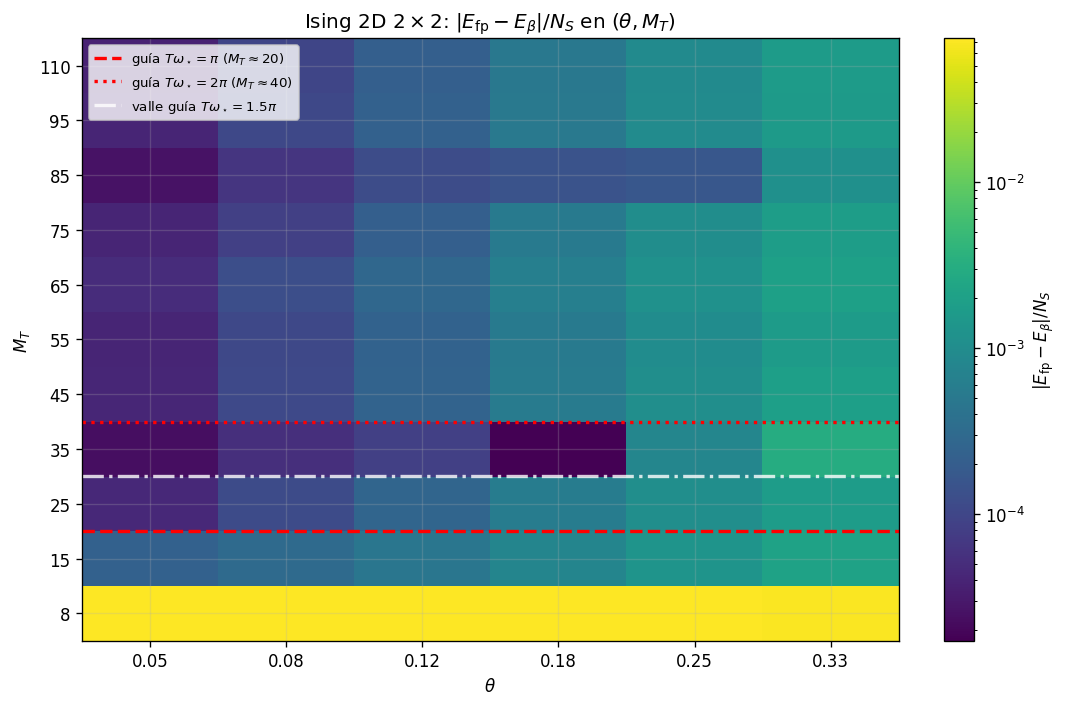

In [10]:
# ============================================================
# NB03 — Heatmap |E_fp - E_beta|/N_S en (theta, MT)
# ============================================================

# Caso interactuante base: Ising 2D 2x2
# Si va lento, baja theta_grid o MT_grid, pero mantén 2x2 para correlaciones genuinas.
base_ising_regime = make_params_2d(
    Lx=2, Ly=2,
    J=0.5,
    beta=1.0,
    MT=40,
    n_cycles=1,      # no se usa para fp por Kraus, pero lo dejamos definido
    theta=0.10,
)

# Recomendado para el diagnóstico: sin randomización y sin rewind
base_ising_regime.update(
    sys_A="Y",
    bath_A="Y",
    randomize=False,
    rewind=False,
)

MT_grid_ising = np.array([8, 15, 25, 35, 45, 55, 65, 75, 85, 95, 110])
theta_grid_ising = np.array([0.05, 0.08, 0.12, 0.18, 0.25, 0.33])

Z_ising = np.full((len(MT_grid_ising), len(theta_grid_ising)), np.nan)

t0 = time.time()

for j, th in enumerate(theta_grid_ising):
    for i, MT_v in enumerate(MT_grid_ising):
        p = dict(
            base_ising_regime,
            theta=float(th),
            MT=int(MT_v),
        )

        bias, rho_fp, rho_g, compiled, evals = ising_bias_fp_fast(p)
        Z_ising[i, j] = bias

        print(
            f"theta={th:.3f}, MT={MT_v:3d} "
            f"-> |Efp-Eg|/Ns={bias:.3e}"
        )

print(f"\nTiempo total: {(time.time()-t0)/60:.2f} min")

# Frecuencia de Bohr dominante para dibujar guías de resonancia
cfg_ref = build_ising_cfg(**base_ising_regime)
compiled_ref = compile_protocol(cfg_ref)
A_ops_ref = system_A_ops_from_cfg(cfg_ref)

omega_ref_ising, df_bohr_ising = dominant_bohr_frequency(
    compiled_ref["Hs_mat"],
    A_ops_ref,
)

display(df_bohr_ising.head(10).round(6))

delta_used = base_ising_regime["delta"]
MT_res1 = np.pi / (delta_used * omega_ref_ising)
MT_res2 = 2 * np.pi / (delta_used * omega_ref_ising)
MT_valley = 1.5 * np.pi / (delta_used * omega_ref_ising)

print(f"omega_ref dominante ≈ {omega_ref_ising:.6f}")
print(f"Primera guía resonante Tω=π   -> MT≈{MT_res1:.1f}")
print(f"Segunda guía resonante Tω=2π  -> MT≈{MT_res2:.1f}")
print(f"Valle guía Tω=1.5π            -> MT≈{MT_valley:.1f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

vmin = max(np.nanmin(Z_ising), 1e-8)
vmax = np.nanmax(Z_ising)

im = ax.imshow(
    Z_ising,
    aspect="auto",
    origin="lower",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    cmap="viridis",
    extent=[-0.5, len(theta_grid_ising)-0.5, -0.5, len(MT_grid_ising)-0.5],
)

ax.set_xticks(range(len(theta_grid_ising)))
ax.set_xticklabels([f"{x:.2f}" for x in theta_grid_ising])
ax.set_yticks(range(len(MT_grid_ising)))
ax.set_yticklabels(MT_grid_ising)

ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$M_T$")
ax.set_title(
    r"Ising 2D $2\times2$: $|E_{\rm fp}-E_\beta|/N_S$ "
    r"en $(\theta,M_T)$"
)

def mt_to_index(mt_val, mt_grid):
    return interp(mt_val, mt_grid, np.arange(len(mt_grid)))

y_res1 = mt_to_index(MT_res1, MT_grid_ising)
y_res2 = mt_to_index(MT_res2, MT_grid_ising)
y_valley = mt_to_index(MT_valley, MT_grid_ising)

ax.axhline(
    y_res1,
    color="red",
    lw=2,
    ls="--",
    label=rf"guía $T\omega_\star=\pi$ ($M_T\approx {MT_res1:.0f}$)",
)
ax.axhline(
    y_res2,
    color="red",
    lw=2,
    ls=":",
    label=rf"guía $T\omega_\star=2\pi$ ($M_T\approx {MT_res2:.0f}$)",
)
ax.axhline(
    y_valley,
    color="white",
    lw=2,
    ls="-.",
    alpha=0.8,
    label=rf"valle guía $T\omega_\star=1.5\pi$",
)

ax.legend(loc="upper left", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.04, label=r"$|E_{\rm fp}-E_\beta|/N_S$")
plt.tight_layout()
plt.show()

### A.6.3 Corte fino en $M_T$ y elección operativa

MT= 10 -> |Efp-Eg|/Ns=1.621e-02
MT= 12 -> |Efp-Eg|/Ns=1.627e-03
MT= 14 -> |Efp-Eg|/Ns=2.802e-04
MT= 16 -> |Efp-Eg|/Ns=1.490e-04
MT= 18 -> |Efp-Eg|/Ns=6.070e-05
MT= 20 -> |Efp-Eg|/Ns=3.440e-05
MT= 22 -> |Efp-Eg|/Ns=4.833e-05
MT= 24 -> |Efp-Eg|/Ns=4.589e-05
MT= 26 -> |Efp-Eg|/Ns=4.641e-05
MT= 28 -> |Efp-Eg|/Ns=1.613e-05
MT= 30 -> |Efp-Eg|/Ns=3.834e-05
MT= 32 -> |Efp-Eg|/Ns=4.325e-05
MT= 34 -> |Efp-Eg|/Ns=4.105e-05
MT= 36 -> |Efp-Eg|/Ns=5.183e-05
MT= 38 -> |Efp-Eg|/Ns=4.839e-05
MT= 40 -> |Efp-Eg|/Ns=4.559e-05
MT= 42 -> |Efp-Eg|/Ns=3.000e-05
MT= 44 -> |Efp-Eg|/Ns=4.640e-05
MT= 46 -> |Efp-Eg|/Ns=4.481e-05
MT= 48 -> |Efp-Eg|/Ns=4.399e-05
MT= 50 -> |Efp-Eg|/Ns=4.936e-05
MT= 52 -> |Efp-Eg|/Ns=4.604e-05
MT= 54 -> |Efp-Eg|/Ns=3.303e-05
MT= 56 -> |Efp-Eg|/Ns=3.751e-05
MT= 58 -> |Efp-Eg|/Ns=4.998e-05
MT= 60 -> |Efp-Eg|/Ns=3.251e-05
MT= 62 -> |Efp-Eg|/Ns=3.808e-05
MT= 64 -> |Efp-Eg|/Ns=7.211e-05
MT= 66 -> |Efp-Eg|/Ns=4.826e-05
MT= 68 -> |Efp-Eg|/Ns=4.286e-05
MT= 70 -> |Efp-Eg|/Ns=3.337e-05
MT= 72 -

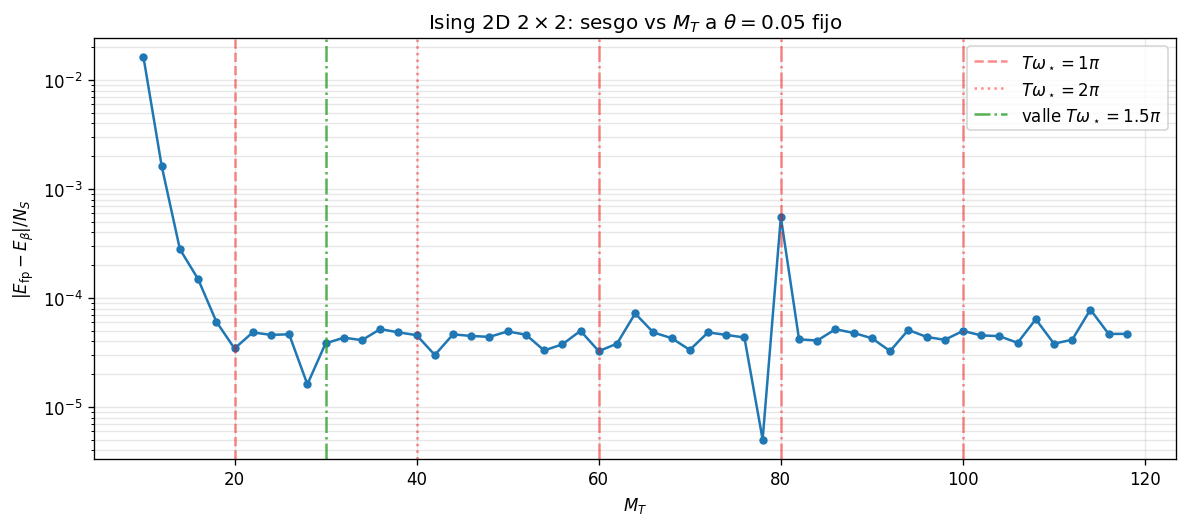

In [11]:
# ============================================================
# NB03 — Corte fino: sesgo vs MT a theta fijo
# ============================================================

theta_fixed_ising = 0.05
MT_fine_ising = np.arange(10, 120, 2)

bias_mt_ising = []

t0 = time.time()

for MT_v in MT_fine_ising:
    p = dict(
        base_ising_regime,
        theta=float(theta_fixed_ising),
        MT=int(MT_v),
    )

    bias, rho_fp, rho_g, compiled, evals = ising_bias_fp_fast(p)
    bias_mt_ising.append(bias)

    print(f"MT={MT_v:3d} -> |Efp-Eg|/Ns={bias:.3e}")

bias_mt_ising = np.array(bias_mt_ising)

print(f"\nTiempo total: {(time.time()-t0)/60:.2f} min")

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.semilogy(MT_fine_ising, bias_mt_ising, "o-", ms=4)

add_harmonic_guides(
    ax,
    omega_ref=omega_ref_ising,
    delta=base_ising_regime["delta"],
    kmax=5,
    color="red",
)

ax.axvline(
    MT_valley,
    color="tab:green",
    ls="-.",
    alpha=0.8,
    label=rf"valle $T\omega_\star=1.5\pi$",
)

ax.set_xlabel(r"$M_T$")
ax.set_ylabel(r"$|E_{\rm fp}-E_\beta|/N_S$")
ax.set_title(
    rf"Ising 2D $2\times2$: sesgo vs $M_T$ "
    rf"a $\theta={theta_fixed_ising}$ fijo"
)

ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### A.6.4 Rewind en sistemas interactuantes

En Ising interactuante, el rewind no solo empeora la distancia global a Gibbs, sino que deforma de manera clara la estructura de correlaciones del punto fijo. El estado queda con coherencias energéticas residuales y con información mutua/correladores distintos a los térmicos.

En no interactuante el error era factorizado y no aparecían correlaciones espurias. Ahora el Hamiltoniano ya no factoriza y la dinámica libre contiene términos interactuantes. Entonces, el rewind ya no es una rotación local independiente en cada qubit. Es una evolución global interactuante. Puede mezclar coherencias, fases y correlaciones del sistema completo.

,variante,"Dtr(fp,Gibbs)",E/N,I_halves,ΔI vs Gibbs,Dcorr_total,ΔDcorr,corr_RMSE,coh_energy
0,Gibbs exacto,0.000000,-1.016684,0.236314,0.000000,0.454668,0.000000,0.000000,0.000000
1,sin nada,0.006467,-1.016363,0.236107,-0.000208,0.454803,0.000135,0.000911,0.019185
2,solo random,0.002428,-1.016502,0.236224,-0.000090,0.454893,0.000225,0.000366,0.006315
3,solo rewind,0.210791,-1.007840,0.350032,0.113718,0.459079,0.004411,0.051098,0.623119
4,ambos,0.003354,-1.016146,0.237724,0.001410,0.455502,0.000834,0.001160,0.009434


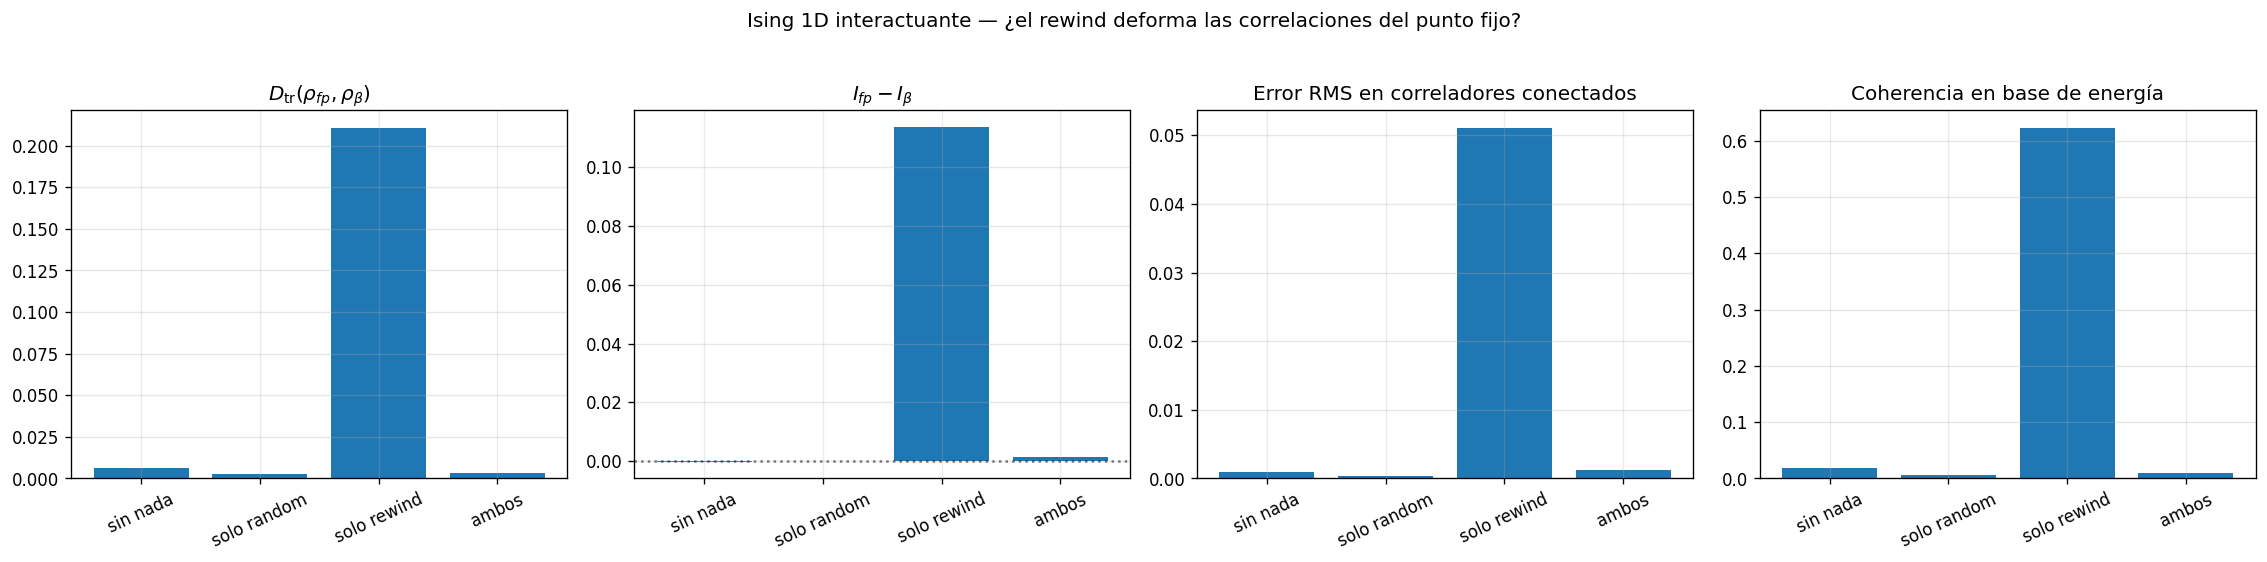

In [ ]:
# ============================================================
# ¿El rewind rompe la estructura de correlaciones?
# Ising interactuante: comparación de variantes del protocolo
# ============================================================

variants_rewind = {
    "sin nada": dict(randomize=False, randomization_lambda=0.0, rewind=False),
    "solo random": dict(randomize=True, randomization_lambda=1.0, rewind=False),
    "solo rewind": dict(randomize=False, randomization_lambda=0.0, rewind=True),
    "ambos": dict(randomize=True, randomization_lambda=1.0, rewind=True),
}

# Caso interactuante manejable
N_S_test = 4
pairs_nn = [(0, 1), (1, 2), (2, 3)]

p_base_corr = make_params_1d(
    Lx=N_S_test,
    J=1.0,
    beta=1.0,
    theta=0.25,
    n_cycles=180,
)

rows_corr = []

# Primero calculamos Gibbs de referencia
out_ref = run_ising_case(
    p_base_corr,
    rho0=maximally_mixed(N_S_test),
    compute_fp=True,
    fp_mode="late_time",
    late_fp_burn=120,
    late_fp_keep=40,
)

rho_g = out_ref["rho_g"]
Hs = out_ref["Hs"]

I_g = mutual_information_partition(rho_g, list(range(N_S_test // 2)), N_S_test)
Dcorr_g = total_correlation_distance(rho_g, N_S_test)
Cvec_g = connected_corr_vector_ising(rho_g, N_S_test, pairs=pairs_nn)

rows_corr.append({
    "variante": "Gibbs exacto",
    "Dtr(fp,Gibbs)": 0.0,
    "E/N": expect(Hs, rho_g) / N_S_test,
    "I_halves": I_g,
    "ΔI vs Gibbs": 0.0,
    "Dcorr_total": Dcorr_g,
    "ΔDcorr": 0.0,
    "corr_RMSE": 0.0,
    "coh_energy": 0.0,
})

for name, extra in variants_rewind.items():
    p = dict(p_base_corr)
    p.update(extra)

    out = run_ising_case(
        p,
        rho0=maximally_mixed(N_S_test),
        compute_fp=True,
        fp_mode="late_time",
        late_fp_burn=180,
        late_fp_keep=60,
    )

    rho_fp = out["rho_fp"]
    Hs = out["Hs"]

    I_fp = mutual_information_partition(
        rho_fp,
        list(range(N_S_test // 2)),
        N_S_test,
    )
    Dcorr_fp = total_correlation_distance(rho_fp, N_S_test)
    Cvec_fp = connected_corr_vector_ising(rho_fp, N_S_test, pairs=pairs_nn)

    corr_rmse = float(np.sqrt(np.mean((Cvec_fp - Cvec_g) ** 2)))

    rows_corr.append({
        "variante": name,
        "Dtr(fp,Gibbs)": trace_distance_dm(rho_fp, rho_g),
        "E/N": expect(Hs, rho_fp) / N_S_test,
        "I_halves": I_fp,
        "ΔI vs Gibbs": I_fp - I_g,
        "Dcorr_total": Dcorr_fp,
        "ΔDcorr": Dcorr_fp - Dcorr_g,
        "corr_RMSE": corr_rmse,
        "coh_energy": coherence_norm_in_energy_basis(rho_fp, Hs, norm="l1"),
    })

df_rewind_corr = pd.DataFrame(rows_corr)
display(df_rewind_corr.round(6))

fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))

sub = df_rewind_corr[df_rewind_corr["variante"] != "Gibbs exacto"]

axes[0].bar(sub["variante"], sub["Dtr(fp,Gibbs)"])
axes[0].set_title(r"$D_{\rm tr}(\rho_{fp},\rho_\beta)$")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(sub["variante"], sub["ΔI vs Gibbs"])
axes[1].axhline(0, ls=":", color="k", alpha=0.5)
axes[1].set_title(r"$I_{fp}-I_{\beta}$")
axes[1].tick_params(axis="x", rotation=25)

axes[2].bar(sub["variante"], sub["corr_RMSE"])
axes[2].set_title("Error RMS en correladores conectados")
axes[2].tick_params(axis="x", rotation=25)

axes[3].bar(sub["variante"], sub["coh_energy"])
axes[3].set_title("Coherencia en base de energía")
axes[3].tick_params(axis="x", rotation=25)

for ax in axes:
    ax.grid(alpha=0.3, axis="y")

plt.suptitle("Ising 1D interactuante — ¿el rewind deforma las correlaciones del punto fijo?", y=1.03)
plt.tight_layout()
plt.show()

## A.7 Tiempo de mezcla y análisis negativo de efecto Mpemba
En esta sección estudiamos cuántos ciclos necesita el protocolo para alcanzar una tolerancia fija frente al Gibbs objetivo. Para cada $\beta$ definimos

$$
n_\star(\epsilon)=\min\{n:\,D_{\rm tr}(\rho_n,\rho_\beta)\leq \epsilon\}.
$$

El objetivo es comprobar si aparece una no-monotonicidad tipo Mpemba: un objetivo más frío, con mayor $\beta$, alcanzado en menos ciclos que otro más caliente. Si $n_\star(\beta)$ crece de forma monótona, el comportamiento es el esperado: temperaturas más bajas requieren más ciclos.

La distancia traza es la métrica principal. La energía se usa solo como diagnóstico complementario.

### A.7.1 Tiempo de mezcla vs $\beta$ desde $\rho_0=I/d$

Primero hacemos el análisis cuantitativo principal en Ising 1D con $N_S=4$, partiendo de $\rho_0=I/d$. Para cada $\beta$ medimos la distancia traza a Gibbs durante la evolución y extraemos el primer ciclo $n_\star$ que cruza la tolerancia.

Este bloque es el test principal de no-monotonicidad. Si existiera una señal Mpemba-like, aparecería como un par $\beta_{\rm cold}>\beta_{\rm hot}$ con $n_\star(\beta_{\rm cold})<n_\star(\beta_{\rm hot})$.

In [ ]:
# A.7.1 — Tiempo de mezcla vs beta desde rho0 = I/d

# Columnas derivadas
df_beta_mix["N_S"] = 4
df_beta_mix["bias_E_final"] = np.abs(df_beta_mix["E_final"] - df_beta_mix["E_gibbs"])
df_beta_mix["bias_E_final_per_site"] = df_beta_mix["bias_E_final"] / df_beta_mix["N_S"]

display(df_beta_mix.round(6))

,geometry,rho0,beta,J,theta,MT,n_cycles,eps,n_star,D_initial,D_final,E_initial,E_final,E_gibbs,N_S,bias_E_final,bias_E_final_per_site
0,1d4,I/d,0.4,0.5,0.25,30,300,0.05,22,0.336474,0.009908,0.0,-1.767200,-1.761692,4,0.005508,0.001377
1,1d4,I/d,0.6,0.5,0.25,30,300,0.05,29,0.464815,0.014047,0.0,-2.439391,-2.433439,4,0.005952,0.001488
2,1d4,I/d,0.8,0.5,0.25,30,300,0.05,38,0.571586,0.016030,0.0,-2.945838,-2.939970,4,0.005868,0.001467
3,1d4,I/d,1.0,0.5,0.25,30,300,0.05,45,0.655115,0.016185,0.0,-3.310881,-3.305535,4,0.005346,0.001337
4,1d4,I/d,1.3,0.5,0.25,30,300,0.05,54,0.736037,0.014472,0.0,-3.665542,-3.661530,4,0.004012,0.001003
5,1d4,I/d,1.7,0.5,0.25,30,300,0.05,63,0.810242,0.011161,0.0,-3.919763,-3.917611,4,0.002152,0.000538
6,1d4,I/d,2.2,0.5,0.25,30,300,0.05,70,0.855763,0.007609,0.0,-4.065906,-4.065257,4,0.000649,0.000162
7,1d4,I/d,2.8,0.5,0.25,30,300,0.05,76,0.901599,0.004795,0.0,-4.137754,-4.137841,4,0.000087,0.000022
8,1d4,I/d,3.5,0.5,0.25,30,300,0.05,80,0.923468,0.002970,0.0,-4.169204,-4.169508,4,0.000304,0.000076


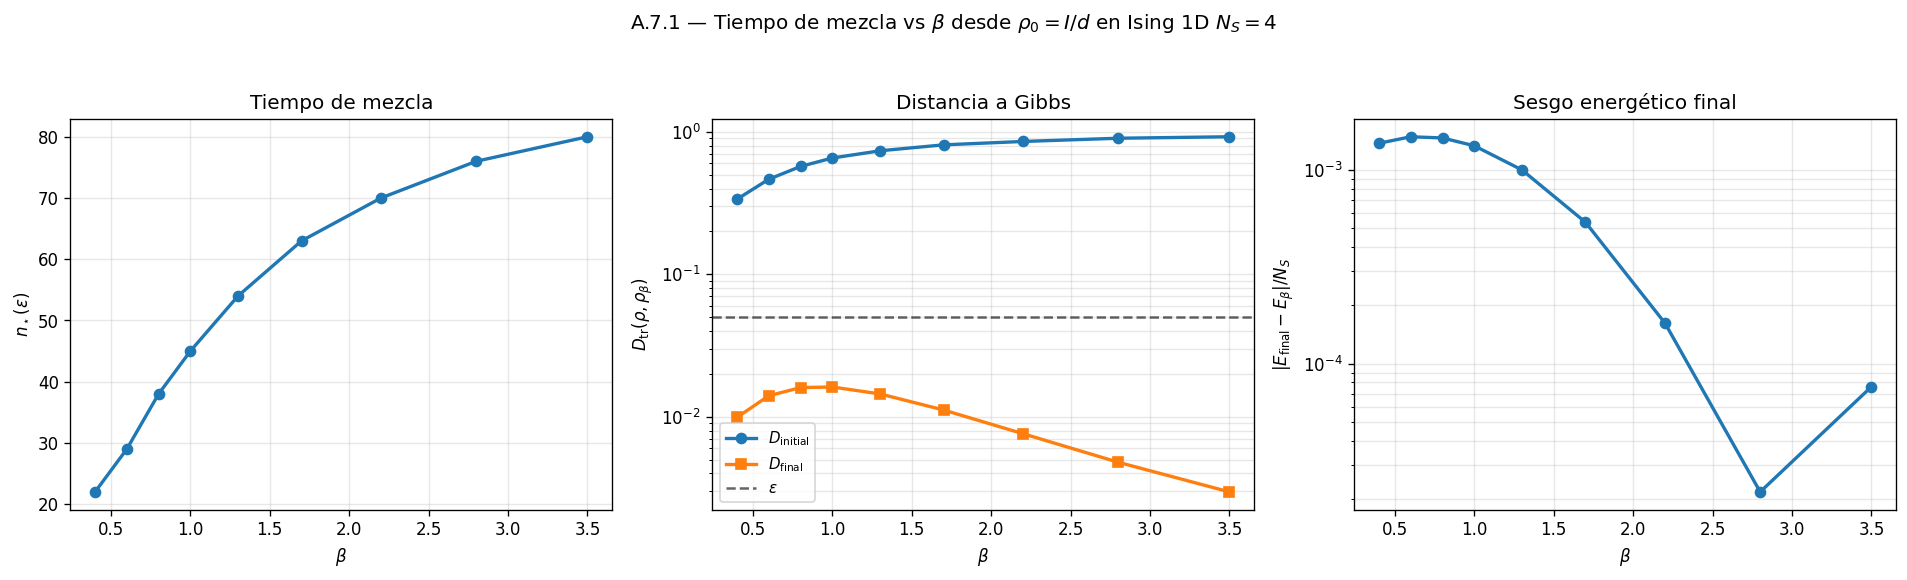

In [12]:
# A.7.1 — Figura principal: tiempo de mezcla, distancia y sesgo energético

dfp_A7 = df_beta_mix.sort_values("beta").copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

axes[0].plot(dfp_A7["beta"], dfp_A7["n_star"], "o-", lw=2)
axes[0].set_xlabel(r"$\beta$")
axes[0].set_ylabel(r"$n_\star(\epsilon)$")
axes[0].set_title("Tiempo de mezcla")
axes[0].grid(alpha=0.3)

axes[1].plot(dfp_A7["beta"], dfp_A7["D_initial"], "o-", lw=2, label=r"$D_{\rm initial}$")
axes[1].plot(dfp_A7["beta"], dfp_A7["D_final"], "s-", lw=2, label=r"$D_{\rm final}$")
axes[1].axhline(dfp_A7["eps"].iloc[0], ls="--", color="k", alpha=0.6, label=r"$\epsilon$")
axes[1].set_xlabel(r"$\beta$")
axes[1].set_ylabel(r"$D_{\rm tr}(\rho,\rho_\beta)$")
axes[1].set_yscale("log")
axes[1].set_title("Distancia a Gibbs")
axes[1].grid(alpha=0.3, which="both")
axes[1].legend(fontsize=9)

axes[2].plot(dfp_A7["beta"], dfp_A7["bias_E_final_per_site"], "o-", lw=2)
axes[2].set_xlabel(r"$\beta$")
axes[2].set_ylabel(r"$|E_{\rm final}-E_\beta|/N_S$")
axes[2].set_yscale("log")
axes[2].set_title("Sesgo energético final")
axes[2].grid(alpha=0.3, which="both")

plt.suptitle(
    r"A.7.1 — Tiempo de mezcla vs $\beta$ desde $\rho_0=I/d$ en Ising 1D $N_S=4$",
    y=1.04,
)
plt.tight_layout()
plt.show()

In [5]:
# A.7.2 — Test explícito de inversión Mpemba-like

df_clean = df_beta_mix.dropna(subset=["n_star"]).sort_values("beta")
inversions = []

for _, hot in df_clean.iterrows():
    for _, cold in df_clean.iterrows():
        if cold["beta"] <= hot["beta"]:
            continue
        if cold["n_star"] < hot["n_star"]:
            inversions.append({
                "beta_hot": hot["beta"],
                "beta_cold": cold["beta"],
                "n_hot": hot["n_star"],
                "n_cold": cold["n_star"],
                "delta_n": cold["n_star"] - hot["n_star"],
            })

df_inversions_A7 = pd.DataFrame(inversions)

if len(df_inversions_A7) == 0:
    display(pd.DataFrame([{
        "resultado": "sin inversiones",
        "criterio": "no hay beta_cold > beta_hot con n_star(cold) < n_star(hot)",
        "n_betas": len(df_clean),
        "eps": df_clean["eps"].iloc[0],
    }]))
else:
    display(df_inversions_A7.round(6))

,resultado,criterio,n_betas,eps
0,sin inversiones,no hay beta_cold > beta_hot con n_star(cold) <...,9,0.05




Desde $\rho_0=I/d$, el Gibbs objetivo se aleja del estado inicial al aumentar $\beta$, y el tiempo de mezcla $n_\star(\epsilon)$ crece de forma monótona. No aparece ningún par de temperaturas con $\beta_{\rm cold}>\beta_{\rm hot}$ tal que el objetivo frío se alcance antes que el caliente.

Por tanto, en este régimen no observamos una inversión Mpemba-like. El resultado es negativo respecto a Mpemba, pero positivo respecto a la estabilidad del protocolo: el barrido largo alcanza la tolerancia para todas las temperaturas estudiadas.

El sesgo energético final por sitio es pequeño en todo el rango y especialmente bajo en el régimen frío. Esto indica que la energía térmica se reproduce bien, aunque el criterio principal de convergencia sigue siendo $D_{\rm tr}(\rho_n,\rho_\beta)$.

### A.7.2 Abanico de trayectorias térmicas

Para complementar el test cuantitativo de A.7.1, mostramos directamente las trayectorias de convergencia para muchas temperaturas objetivo. Esta figura no sustituye al barrido principal: su función es visualizar cómo decae $D_{\rm tr}(\rho_n,\rho_\beta)$ con los ciclos.

Usamos una versión ligera en Ising 1D con $N_S=3$, de modo que el bloque sea ejecutable en el notebook sin problemas de memoria. La primera figura muestra la distancia absoluta a Gibbs; la segunda normaliza por la distancia inicial, $D_n/D_0$, para separar el hecho de estar inicialmente más lejos de la rapidez relativa de convergencia.

[A.7.2] beta=0.40
[A.7.2] beta=0.60
[A.7.2] beta=0.80
[A.7.2] beta=1.00
[A.7.2] beta=1.30
[A.7.2] beta=1.70
[A.7.2] beta=2.20
[A.7.2] beta=2.80
[A.7.2] beta=3.50
Guardado: data\A7_thermalization_fan_light.pkl


,beta,N_S,J,theta,MT,n_cycles,eps,D_initial,D_final,n_star,E_initial,E_final,E_gibbs,bias_E_final_per_site
0,0.4,3,0.5,0.25,18,180,0.05,0.293592,0.002266,19,0.0,-1.305789,-1.301052,0.001579
1,0.6,3,0.5,0.25,18,180,0.05,0.408662,0.002932,29,0.0,-1.806056,-1.801014,0.001681
2,0.8,3,0.5,0.25,18,180,0.05,0.511881,0.003340,36,0.0,-2.185170,-2.180588,0.001527
3,1.0,3,0.5,0.25,18,180,0.05,0.590203,0.003571,43,0.0,-2.460181,-2.456308,0.001291
4,1.3,3,0.5,0.25,18,180,0.05,0.665346,0.003672,50,0.0,-2.729493,-2.726489,0.001001
5,1.7,3,0.5,0.25,18,180,0.05,0.753373,0.003614,57,0.0,-2.924557,-2.921769,0.000929
6,2.2,3,0.5,0.25,18,180,0.05,0.816576,0.003644,62,0.0,-3.037821,-3.034216,0.001202
7,2.8,3,0.5,0.25,18,180,0.05,0.850515,0.003791,65,0.0,-3.093375,-3.088821,0.001518
8,3.5,3,0.5,0.25,18,180,0.05,0.865958,0.003518,68,0.0,-3.116215,-3.112014,0.001400


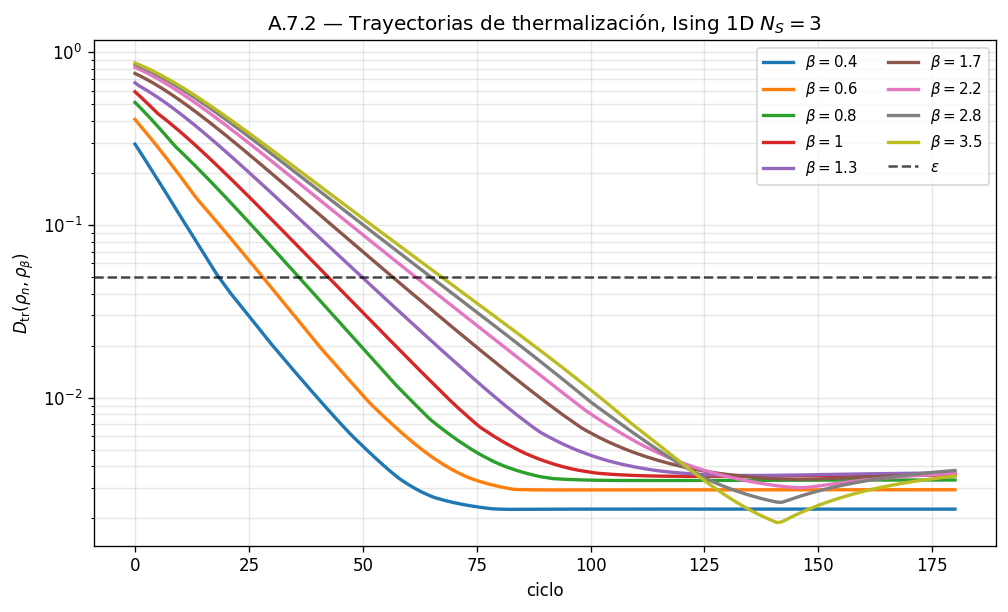

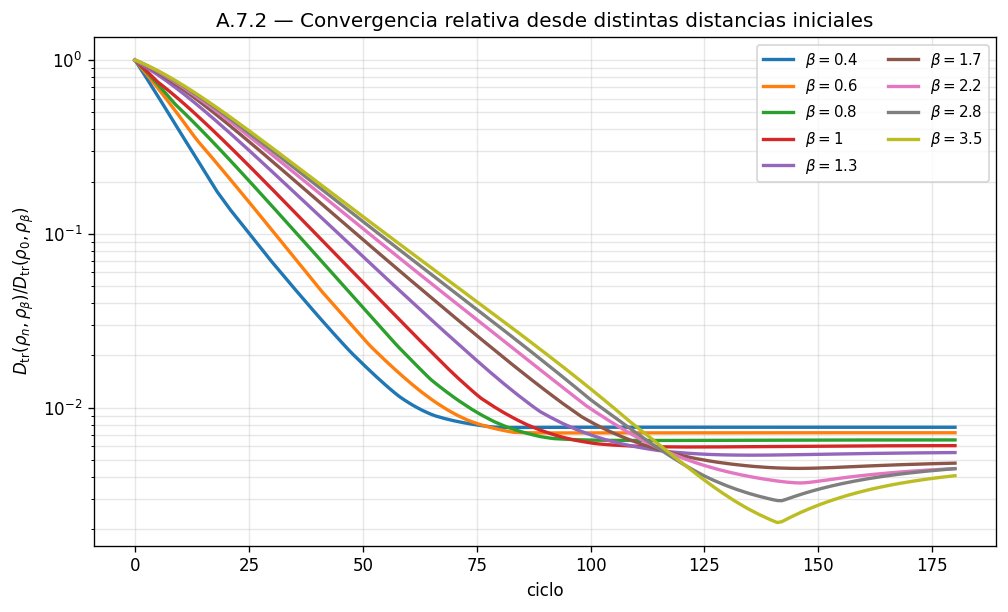

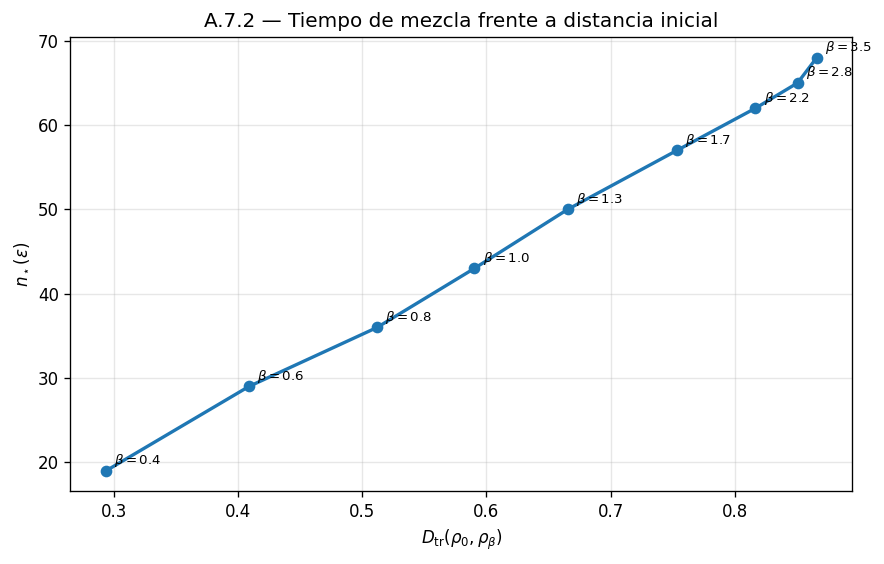

In [ ]:
# A.7.2 — Abanico de trayectorias térmicas para muchas beta
# Versión ligera y cacheada para visualizar thermalización sin explotar memoria.


DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

cache_A72 = DATA_DIR / "A7_thermalization_fan_light.pkl"

RUN_A72 = not cache_A72.exists()

# Barrido visual: bastantes beta, pero problema ligero.
betas_A72 = np.array([0.4, 0.6, 0.8, 1.0, 1.3, 1.7, 2.2, 2.8, 3.5])

params_A72_base = dict(
    N=3,             # ligero: evita problemas de memoria
    J=0.5,
    theta=0.25,
    MT=18,
    n_cycles=180,
    eps=0.05,
)


def make_params_A72(beta, N=3, J=0.5, theta=0.25, MT=18, n_cycles=180):
    """
    Parámetros ligeros para visualizar trayectorias térmicas.
    Usa la misma familia de protocolo que A.7, pero con menor coste.
    """
    g = 1.0
    h = max(2.0 * g, 4.0 * float(J))

    return dict(
        Lx=int(N),
        Ly=1,
        J=float(J),
        g=float(g),
        h=float(h),
        beta=float(beta),
        theta=float(theta),
        delta=np.pi / 40.0,
        MT=int(MT),
        n_cycles=int(n_cycles),
        periodic=False,
        randomize=False,
        sys_A="Y",
        bath_A="Y",
    )


def first_hit_A72(values, eps):
    values = np.asarray(values, dtype=float)
    hits = np.where(values <= float(eps))[0]
    return int(hits[0]) if len(hits) else np.nan


def run_beta_trajectory_A72(beta, params_base):
    """
    Devuelve trayectoria de distancia traza y energía para una beta.
    """
    N = params_base["N"]
    params = make_params_A72(
        beta=beta,
        N=N,
        J=params_base["J"],
        theta=params_base["theta"],
        MT=params_base["MT"],
        n_cycles=params_base["n_cycles"],
    )

    out = run_ising_case(
        params,
        rho0=maximally_mixed(N),
        compute_fp=False,
    )

    rho_g = out["rho_g"]
    Hs = out["Hs"]
    rhos = out["res"]["rhos"]

    dtr = np.array(
        [trace_distance_dm(rho, rho_g) for rho in rhos],
        dtype=float,
    )

    energies = np.array(
        [expect(Hs, rho) for rho in rhos],
        dtype=float,
    )

    E_g = float(expect(Hs, rho_g))
    err_E = np.abs(energies - E_g)
    err_E_rel = err_E / max(err_E[0], 1e-15)

    row = {
        "beta": float(beta),
        "N_S": int(N),
        "J": float(params["J"]),
        "theta": float(params["theta"]),
        "MT": int(params["MT"]),
        "n_cycles": int(params["n_cycles"]),
        "eps": float(params_base["eps"]),
        "D_initial": float(dtr[0]),
        "D_final": float(dtr[-1]),
        "n_star": first_hit_A72(dtr, params_base["eps"]),
        "E_initial": float(energies[0]),
        "E_final": float(energies[-1]),
        "E_gibbs": float(E_g),
        "bias_E_final_per_site": float(abs(energies[-1] - E_g) / N),
    }

    traj = {
        "beta": float(beta),
        "dtr": dtr,
        "dtr_rel": dtr / max(dtr[0], 1e-15),
        "energies": energies,
        "err_E_rel": err_E_rel,
    }

    return row, traj


if RUN_A72:
    rows_A72 = []
    trajectories_A72 = {}

    for beta in betas_A72:
        print(f"[A.7.2] beta={beta:.2f}")

        row, traj = run_beta_trajectory_A72(beta, params_A72_base)

        rows_A72.append(row)
        trajectories_A72[float(beta)] = traj

        # Limpieza defensiva entre betas
        gc.collect()

    df_A72 = pd.DataFrame(rows_A72)

    with open(cache_A72, "wb") as f:
        pickle.dump(
            {
                "df_A72": df_A72,
                "trajectories_A72": trajectories_A72,
                "params_A72_base": params_A72_base,
            },
            f,
        )

    df_A72.to_csv(DATA_DIR / "A7_thermalization_fan_light.csv", index=False)
    print(f"Guardado: {cache_A72}")

else:
    with open(cache_A72, "rb") as f:
        payload_A72 = pickle.load(f)

    df_A72 = payload_A72["df_A72"]
    trajectories_A72 = payload_A72["trajectories_A72"]
    params_A72_base = payload_A72["params_A72_base"]

    print(f"Cargado: {cache_A72}")


display(df_A72.round(6))


# ============================================================
# Figura 1: trayectorias absolutas de distancia traza
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 5.2))

for beta in sorted(trajectories_A72.keys()):
    traj = trajectories_A72[beta]
    ax.semilogy(
        traj["dtr"],
        lw=2,
        label=rf"$\beta={beta:g}$",
    )

ax.axhline(
    params_A72_base["eps"],
    ls="--",
    color="k",
    alpha=0.7,
    label=r"$\epsilon$",
)

ax.set_xlabel("ciclo")
ax.set_ylabel(r"$D_{\rm tr}(\rho_n,\rho_\beta)$")
ax.set_title(
    rf"A.7.2 — Trayectorias de thermalización, Ising 1D $N_S={params_A72_base['N']}$"
)
ax.grid(alpha=0.3, which="both")
ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()


# ============================================================
# Figura 2: distancia normalizada D_n / D_0
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 5.2))

for beta in sorted(trajectories_A72.keys()):
    traj = trajectories_A72[beta]
    ax.semilogy(
        traj["dtr_rel"],
        lw=2,
        label=rf"$\beta={beta:g}$",
    )

ax.set_xlabel("ciclo")
ax.set_ylabel(r"$D_{\rm tr}(\rho_n,\rho_\beta)/D_{\rm tr}(\rho_0,\rho_\beta)$")
ax.set_title("A.7.2 — Convergencia relativa desde distintas distancias iniciales")
ax.grid(alpha=0.3, which="both")
ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()


# ============================================================
# Figura 3: n_star frente a distancia inicial
# ============================================================

dfp_A72 = df_A72.sort_values("beta").copy()

fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(
    dfp_A72["D_initial"],
    dfp_A72["n_star"],
    "o-",
    lw=2,
)

for _, row in dfp_A72.iterrows():
    ax.annotate(
        rf"$\beta={row['beta']:.1f}$",
        (row["D_initial"], row["n_star"]),
        textcoords="offset points",
        xytext=(5, 4),
        fontsize=8,
    )

ax.set_xlabel(r"$D_{\rm tr}(\rho_0,\rho_\beta)$")
ax.set_ylabel(r"$n_\star(\epsilon)$")
ax.set_title("A.7.2 — Tiempo de mezcla frente a distancia inicial")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



El abanico de trayectorias confirma visualmente el comportamiento observado en A.7.1. Para todas las temperaturas del barrido ligero, la distancia traza cae por debajo de la tolerancia, lo que muestra que el protocolo alcanza el entorno térmico del Gibbs objetivo.

Al aumentar $\beta$, el Gibbs objetivo está más lejos de $\rho_0=I/d$ y el tiempo de mezcla aumenta. La representación normalizada $D_n/D_0$ muestra que las curvas frías no presentan una ventaja dinámica robusta: no aparecen cruces sistemáticos que indiquen una inversión Mpemba-like.

La relación casi monótona entre $D_{\rm tr}(\rho_0,\rho_\beta)$ y $n_\star$ resume el resultado: en este régimen, cuanto más lejos está el objetivo térmico, más ciclos hacen falta. Por tanto, A.7.2 actúa como diagnóstico visual de mezcla normal y complementa el test cuantitativo de A.7.1.

## A.8 Apéndice: límite free-fermion y conexión con el caso integrable

Esta sección se incluye como apéndice conceptual dentro del notebook de Ising. Aunque el flujo principal del notebook está centrado en el modelo de Ising cuántico, existe un límite relacionado con cadenas de fermiones libres en el que la preparación térmica puede describirse mediante estados gaussianos.

El objetivo de esta parte no es cambiar de modelo principal, sino ilustrar una situación integrable donde la preparación térmica puede tratarse de forma más eficiente y servir como punto de comparación. En particular, el caso free-fermion permite separar mejor qué aspectos del protocolo dependen de la estructura general de baños repetidos y cuáles dependen de la interacción específica del modelo de Ising.

El Apéndice A del paper estudia el mismo protocolo de preparación térmica en una cadena free-fermion, equivalente al Ising 1D por Jordan-Wigner. La ventaja es que la dinámica puede simularse a tamaños grandes propagando la matriz de covarianza fermiónica, siempre que el Hamiltoniano sea cuadrático y los operadores de enfriamiento sean lineales en Majoranas.

### A.8.1 Referencia free-fermion y validación contra ED

,beta,N,E_beta_per_site,S_beta_per_site,cov_norm,antisym_error
0,0.2,32,-0.097476,0.683447,0.017368,0.0
1,0.4,32,-0.189473,0.655980,0.033762,0.0
2,0.6,32,-0.271794,0.615006,0.048445,0.0
3,0.8,32,-0.342191,0.565935,0.061034,0.0
4,1.0,32,-0.400279,0.513856,0.071480,0.0
5,1.2,32,-0.446977,0.462666,0.079956,0.0
6,1.4,32,-0.483869,0.414856,0.086747,0.0
7,1.6,32,-0.512716,0.371704,0.092160,0.0
8,1.8,32,-0.535170,0.333627,0.096478,0.0
9,2.0,32,-0.552642,0.300503,0.099939,0.0


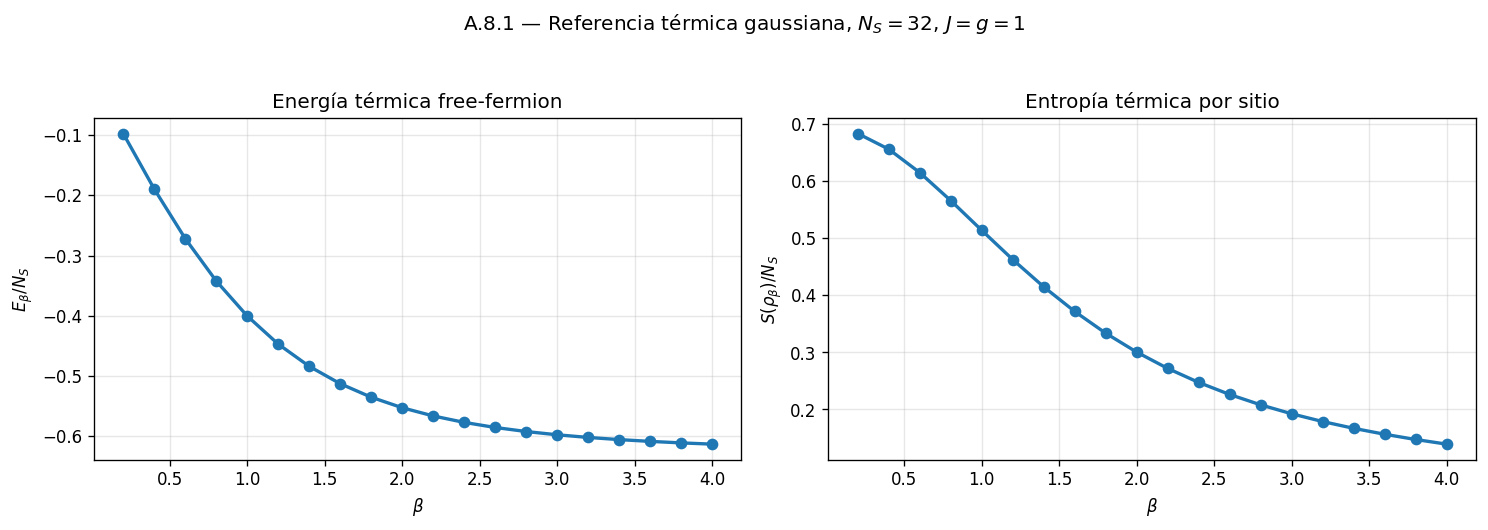

In [6]:
# A.8.1 — Referencia térmica free-fermion

N_ref = 32
J_ref = 1.0
g_ref = 1.0

betas_ref = np.linspace(0.2, 4.0, 20)

rows_ref = []

for beta in betas_ref:
    A_ref = majorana_chain_A(N_ref, J=J_ref, g=g_ref)
    Cb_ref = thermal_covariance_majorana(A_ref, beta=beta)

    rows_ref.append({
        "beta": float(beta),
        "N": int(N_ref),
        "E_beta_per_site": gaussian_energy(A_ref, Cb_ref) / N_ref,
        "S_beta_per_site": gaussian_entropy(Cb_ref) / N_ref,
        "cov_norm": np.linalg.norm(Cb_ref) / np.sqrt(Cb_ref.size),
        "antisym_error": np.linalg.norm(Cb_ref + Cb_ref.T),
    })

df_ff_ref = pd.DataFrame(rows_ref)

display(df_ff_ref.round(6))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].plot(df_ff_ref["beta"], df_ff_ref["E_beta_per_site"], "o-", lw=2)
axes[0].set_xlabel(r"$\beta$")
axes[0].set_ylabel(r"$E_\beta/N_S$")
axes[0].set_title("Energía térmica free-fermion")
axes[0].grid(alpha=0.3)

axes[1].plot(df_ff_ref["beta"], df_ff_ref["S_beta_per_site"], "o-", lw=2)
axes[1].set_xlabel(r"$\beta$")
axes[1].set_ylabel(r"$S(\rho_\beta)/N_S$")
axes[1].set_title("Entropía térmica por sitio")
axes[1].grid(alpha=0.3)

plt.suptitle(
    rf"A.8.1 — Referencia térmica gaussiana, $N_S={N_ref}$, $J=g=1$",
    y=1.04,
)
plt.tight_layout()
plt.show()

### A.8.2 Protocolo gaussiano de cooling

,N,beta,theta,theta2,h,a,T_factor,T_eff,MT,lambda,n_cycles_used,converged,E_per_site,E_beta_per_site,bias_E_per_site,cov_fro,sqrt_rel_entropy_bound
0,40,1.0,0.1,0.01,2.0,2.828427,10.0,3.534292,90,2.0,2000,False,-0.401838,-0.401391,0.000447,0.000079,0.00287


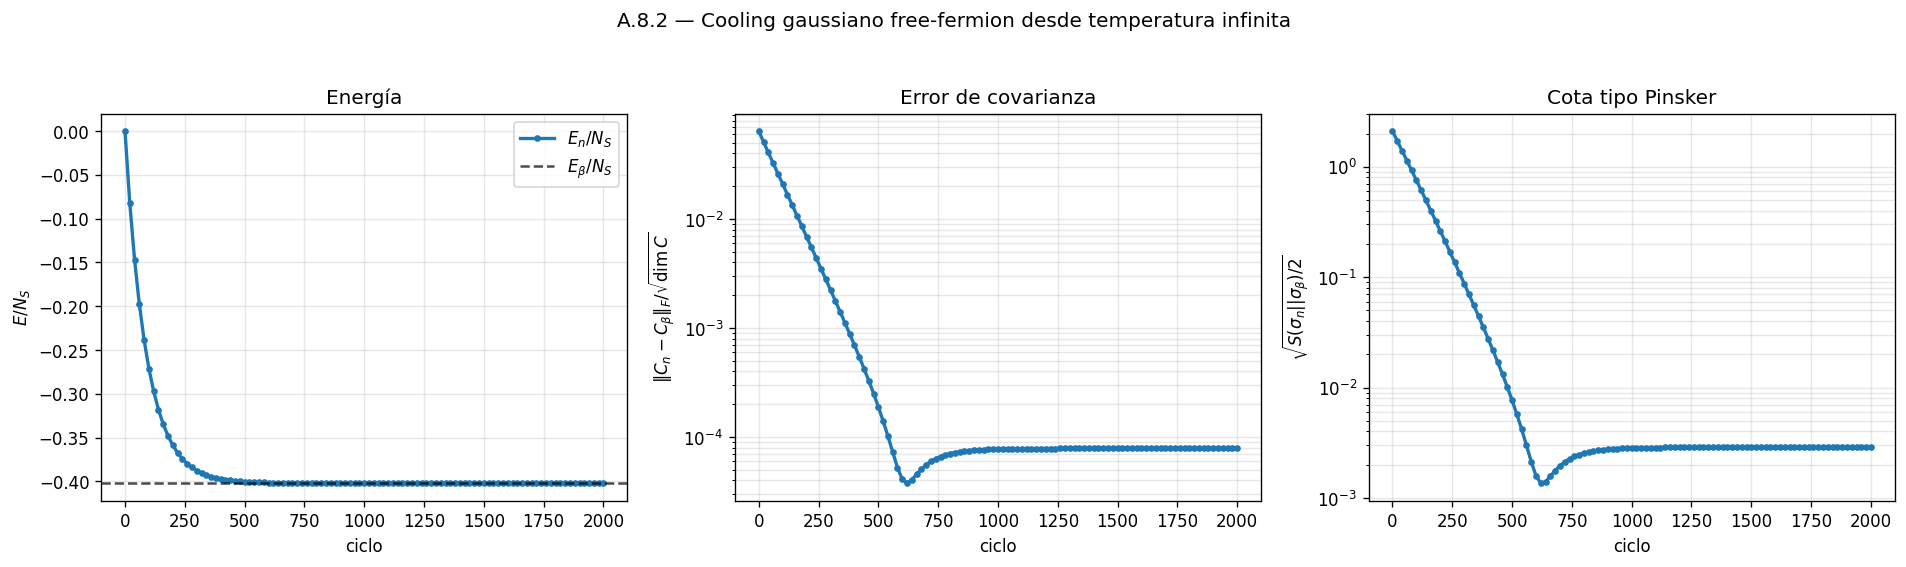

In [7]:
# A.8.2 — Protocolo gaussiano de cooling: trayectoria ilustrativa

out_ff_single = run_ff_protocol_to_stationary(
    N=40,
    J=1.0,
    g=1.0,
    beta=1.0,
    theta=0.10,
    delta=np.pi / 80,
    T_factor=10.0,
    randomization_lambda=2.0,
    max_cycles=2000,
    min_cycles=400,
    check_every=20,
    tol_step=1e-11,
    tol_metric=1e-8,
)

df_ff_single = out_ff_single["traj"]
metrics_ff_single = pd.DataFrame([out_ff_single["metrics"]])

display(metrics_ff_single[
    [
        "N",
        "beta",
        "theta",
        "theta2",
        "h",
        "a",
        "T_factor",
        "T_eff",
        "MT",
        "lambda",
        "n_cycles_used",
        "converged",
        "E_per_site",
        "E_beta_per_site",
        "bias_E_per_site",
        "cov_fro",
        "sqrt_rel_entropy_bound",
    ]
].round(8))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(
    df_ff_single["cycle"],
    df_ff_single["E_per_site"],
    "o-",
    lw=2,
    ms=3,
    label=r"$E_n/N_S$",
)
axes[0].axhline(
    out_ff_single["metrics"]["E_beta_per_site"],
    ls="--",
    color="k",
    alpha=0.7,
    label=r"$E_\beta/N_S$",
)
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel(r"$E/N_S$")
axes[0].set_title("Energía")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].semilogy(
    df_ff_single["cycle"],
    df_ff_single["cov_fro"],
    "o-",
    lw=2,
    ms=3,
)
axes[1].set_xlabel("ciclo")
axes[1].set_ylabel(r"$\|C_n-C_\beta\|_F/\sqrt{\dim C}$")
axes[1].set_title("Error de covarianza")
axes[1].grid(alpha=0.3, which="both")

axes[2].semilogy(
    df_ff_single["cycle"],
    df_ff_single["sqrt_rel_entropy_bound"],
    "o-",
    lw=2,
    ms=3,
)
axes[2].set_xlabel("ciclo")
axes[2].set_ylabel(r"$\sqrt{S(\sigma_n||\sigma_\beta)/2}$")
axes[2].set_title("Cota tipo Pinsker")
axes[2].grid(alpha=0.3, which="both")

plt.suptitle(
    r"A.8.2 — Cooling gaussiano free-fermion desde temperatura infinita",
    y=1.04,
)
plt.tight_layout()
plt.show()

,E,E_beta,E_per_site,E_beta_per_site,bias_E,bias_E_per_site,cov_fro,sqrt_rel_entropy_bound,entropy,entropy_beta,...,g,beta,theta,theta2,delta,MT,T_eff,h,lambda,n_cycles
0,-16.050647,-16.055636,-0.401266,-0.401391,0.004989,0.000125,0.000159,0.005891,20.540884,20.535964,...,1.0,1.0,0.1,0.01,0.08,18,1.44,2.0,2.0,600


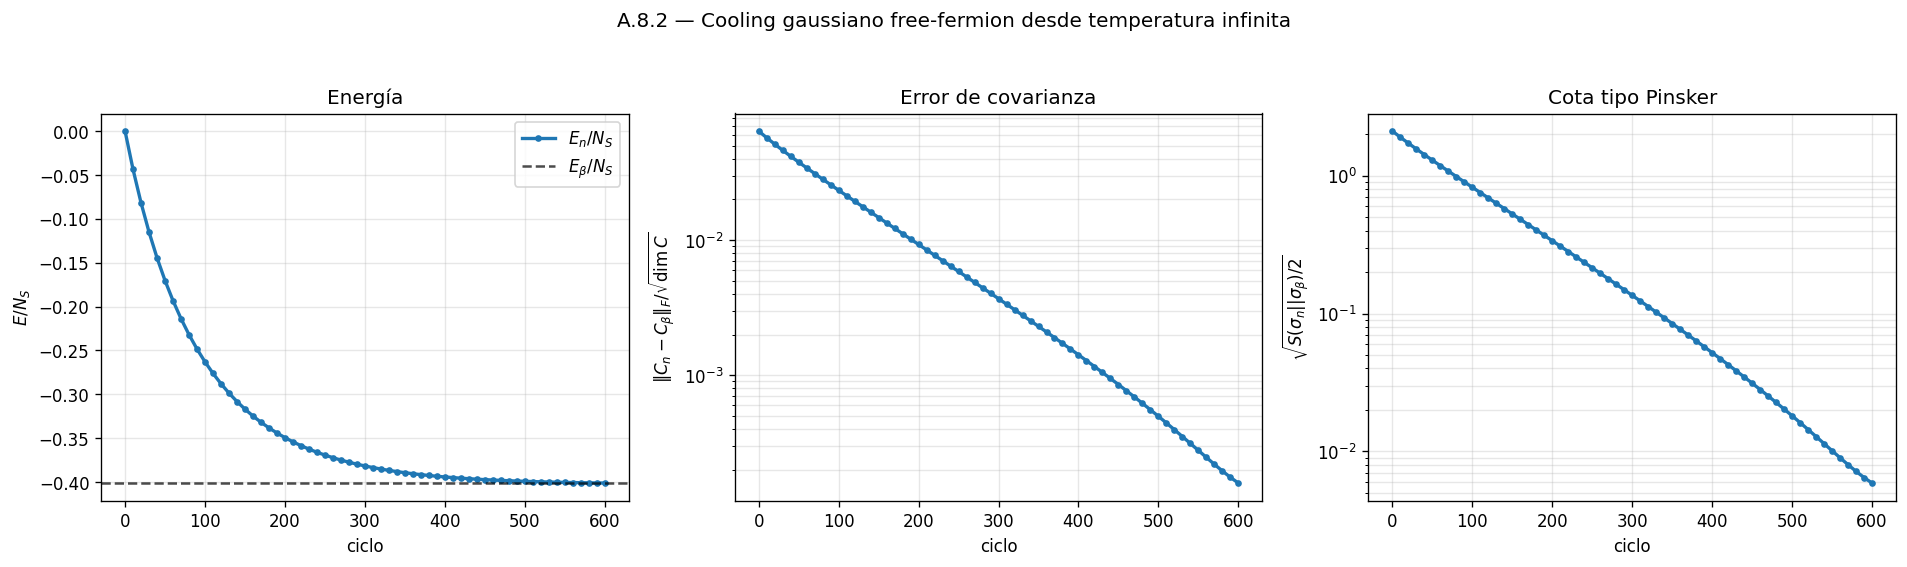

In [8]:
# A.8.2 — Protocolo gaussiano de cooling para una cadena free-fermion

out_ff_single = run_ff_protocol_case(
    N=40,
    J=1.0,
    g=1.0,
    beta=1.0,
    theta=0.1,
    delta=0.08,
    T_factor=4.0,
    n_cycles=600,
    randomization_lambda=2.0,
    store_every=10,
)

df_ff_single = out_ff_single["traj"]
metrics_ff_single = pd.DataFrame([out_ff_single["metrics"]])

display(metrics_ff_single.round(6))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(
    df_ff_single["cycle"],
    df_ff_single["E_per_site"],
    "o-",
    lw=2,
    ms=3,
    label=r"$E_n/N_S$",
)
axes[0].axhline(
    out_ff_single["metrics"]["E_beta_per_site"],
    ls="--",
    color="k",
    alpha=0.7,
    label=r"$E_\beta/N_S$",
)
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel(r"$E/N_S$")
axes[0].set_title("Energía")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].semilogy(
    df_ff_single["cycle"],
    df_ff_single["cov_fro"],
    "o-",
    lw=2,
    ms=3,
)
axes[1].set_xlabel("ciclo")
axes[1].set_ylabel(r"$\|C_n-C_\beta\|_F/\sqrt{\dim C}$")
axes[1].set_title("Error de covarianza")
axes[1].grid(alpha=0.3, which="both")

axes[2].semilogy(
    df_ff_single["cycle"],
    df_ff_single["sqrt_rel_entropy_bound"],
    "o-",
    lw=2,
    ms=3,
)
axes[2].set_xlabel("ciclo")
axes[2].set_ylabel(r"$\sqrt{S(\sigma_n||\sigma_\beta)/2}$")
axes[2].set_title("Cota tipo Pinsker")
axes[2].grid(alpha=0.3, which="both")

plt.suptitle(
    r"A.8.2 — Cooling gaussiano free-fermion desde temperatura infinita",
    y=1.04,
)
plt.tight_layout()
plt.show()

### A.8.3 Escalado del error con $\theta^2$

In [ ]:
# A.8.3.1 — Barrido estacionario en theta^2

theta_list_A103 = np.array([0.045, 0.060, 0.080, 0.110, 0.150, 0.200])

params_A103 = dict(
    N=28,
    J=0.7,
    g=1.0,
    beta=1.0,
    delta=np.pi / 80,
    T_factor=15.0,
    randomization_lambda=2.0,
)

rows_A103 = []
outs_A103 = {}

for theta in theta_list_A103:
    print(f"[A.10.3] theta={theta:.4f}")

    out = run_ff_fixed_point_case(
        **params_A103,
        theta=float(theta),
        rtol=2e-10,
        maxiter=1000,
    )

    rows_A103.append(out["metrics"])
    outs_A103[float(theta)] = out

df_A103 = pd.DataFrame(rows_A103).sort_values("theta2")

display(df_A103[
    [
        "N",
        "J",
        "beta",
        "theta",
        "theta2",
        "T_factor",
        "T_eff",
        "MT",
        "lambda",
        "solver_info",
        "solver_residual",
        "bias_E_per_site",
        "cov_fro",
        "sqrt_rel_entropy_bound",
    ]
].round(10))

[A.10.3] theta=0.0450
[A.10.3] theta=0.0600
[A.10.3] theta=0.0800
[A.10.3] theta=0.1100
[A.10.3] theta=0.1500
[A.10.3] theta=0.2000


,N,J,beta,theta,theta2,T_factor,T_eff,MT,lambda,solver_info,solver_residual,bias_E_per_site,cov_fro,sqrt_rel_entropy_bound
0,28,0.7,1.0,0.045,0.002025,15.0,5.301438,135,2.0,0,2.000000e-10,0.000264,0.000059,0.001457
1,28,0.7,1.0,0.060,0.003600,15.0,5.301438,135,2.0,0,2.000000e-10,0.000285,0.000064,0.001577
2,28,0.7,1.0,0.080,0.006400,15.0,5.301438,135,2.0,0,2.000000e-10,0.000323,0.000073,0.001790
3,28,0.7,1.0,0.110,0.012100,15.0,5.301438,135,2.0,0,2.000000e-10,0.000398,0.000092,0.002223
4,28,0.7,1.0,0.150,0.022500,15.0,5.301438,135,2.0,0,2.000000e-10,0.000534,0.000125,0.003008
5,28,0.7,1.0,0.200,0.040000,15.0,5.301438,135,2.0,0,2.000000e-10,0.000757,0.000179,0.004311


In [15]:
# A.10.3.2 — Ajuste con piso de error independiente de theta

cols_A103_fit = {
    "bias_E_per_site": r"$|E_\sigma-E_\beta|/N_S$",
    "cov_fro": r"$\|C_\sigma-C_\beta\|_F/\sqrt{\dim C}$",
    "sqrt_rel_entropy_bound": r"$\sqrt{S(\sigma||\sigma_\beta)/2}$",
}

fit_results_A103 = {}

for col in cols_A103_fit:
    fit_results_A103[col] = fit_offset_power_law(df_A103, col)

df_fit_A103 = pd.DataFrame([
    {
        "observable": col,
        "y0_floor": fit_results_A103[col]["y0"],
        "A": fit_results_A103[col]["A"],
        "p_offset_model": fit_results_A103[col]["p_offset_model"],
        "p_after_floor_subtraction": fit_results_A103[col]["p_after_floor_subtraction"],
    }
    for col in cols_A103_fit
])

display(df_fit_A103.round(8))

,observable,y0_floor,A,p_offset_model,p_after_floor_subtraction
0,bias_E_per_site,0.000222,0.012381,0.970500,0.858671
1,cov_fro,0.000050,0.003035,0.974972,0.876920
2,sqrt_rel_entropy_bound,0.001296,0.072042,0.985901,0.984056


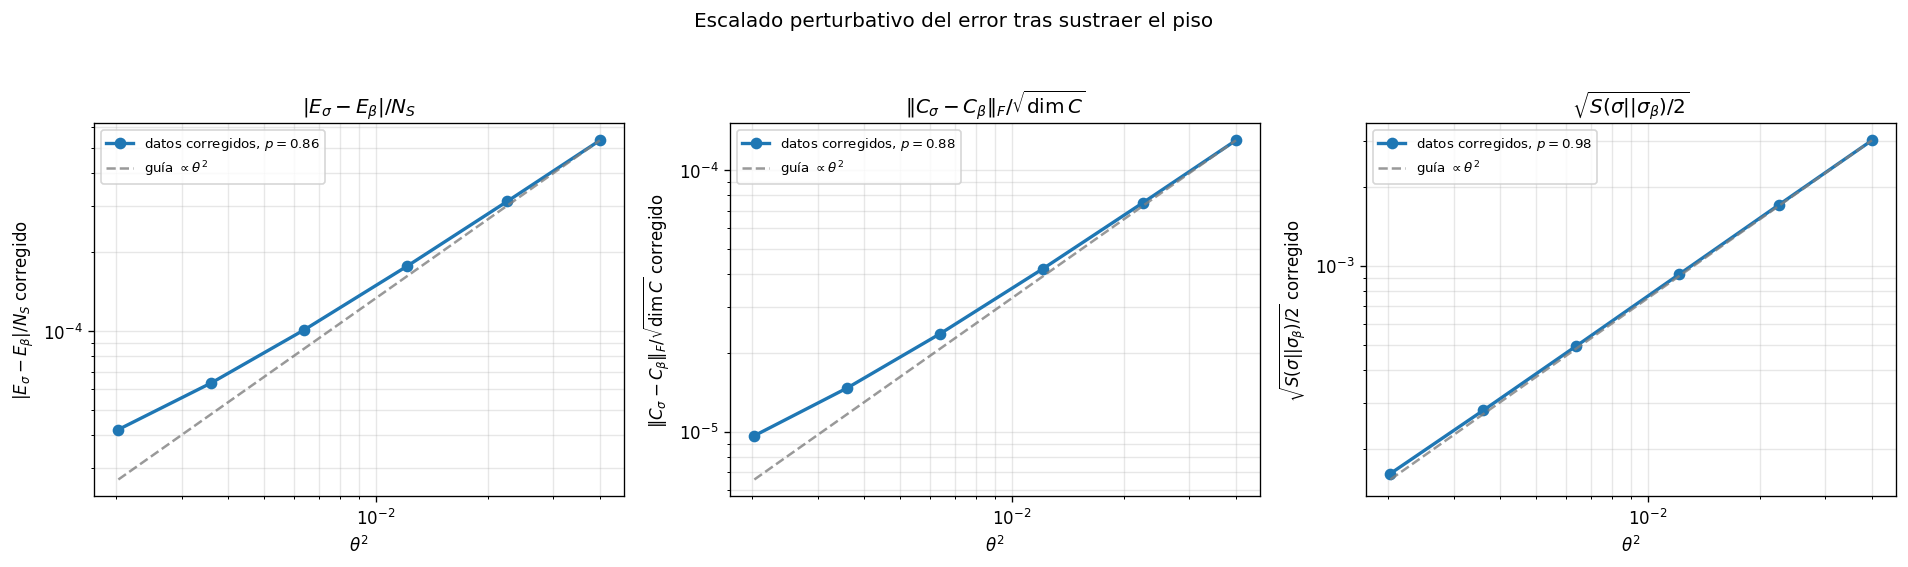

In [ ]:
# A.8.3.3 — Figura principal: componente dependiente de theta

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (col, ylabel) in zip(axes, cols_A103_fit.items()):
    res = fit_results_A103[col]

    x = res["x"]
    y_corr = res["y_corr"]
    mask = res["mask_corr"]

    ax.loglog(
        x[mask],
        y_corr[mask],
        "o-",
        lw=2,
        label=rf"datos corregidos, $p={res['p_after_floor_subtraction']:.2f}$",
    )

    # Guía proporcional a theta^2.
    # Como el eje x ya es theta^2, la guía esperada tiene pendiente 1.
    xg = x[mask]
    yg = y_corr[mask]

    if len(xg) > 0:
        guide = yg[-1] * (xg / xg[-1])
        ax.loglog(
            xg,
            guide,
            "--",
            color="gray",
            alpha=0.8,
            label=r"guía $\propto \theta^2$",
        )

    ax.set_xlabel(r"$\theta^2$")
    ax.set_ylabel(ylabel + " corregido")
    ax.set_title(ylabel)
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=8)

plt.suptitle(
    r"Escalado perturbativo del error tras sustraer el piso",
    y=1.04,
)

plt.tight_layout()
plt.show()

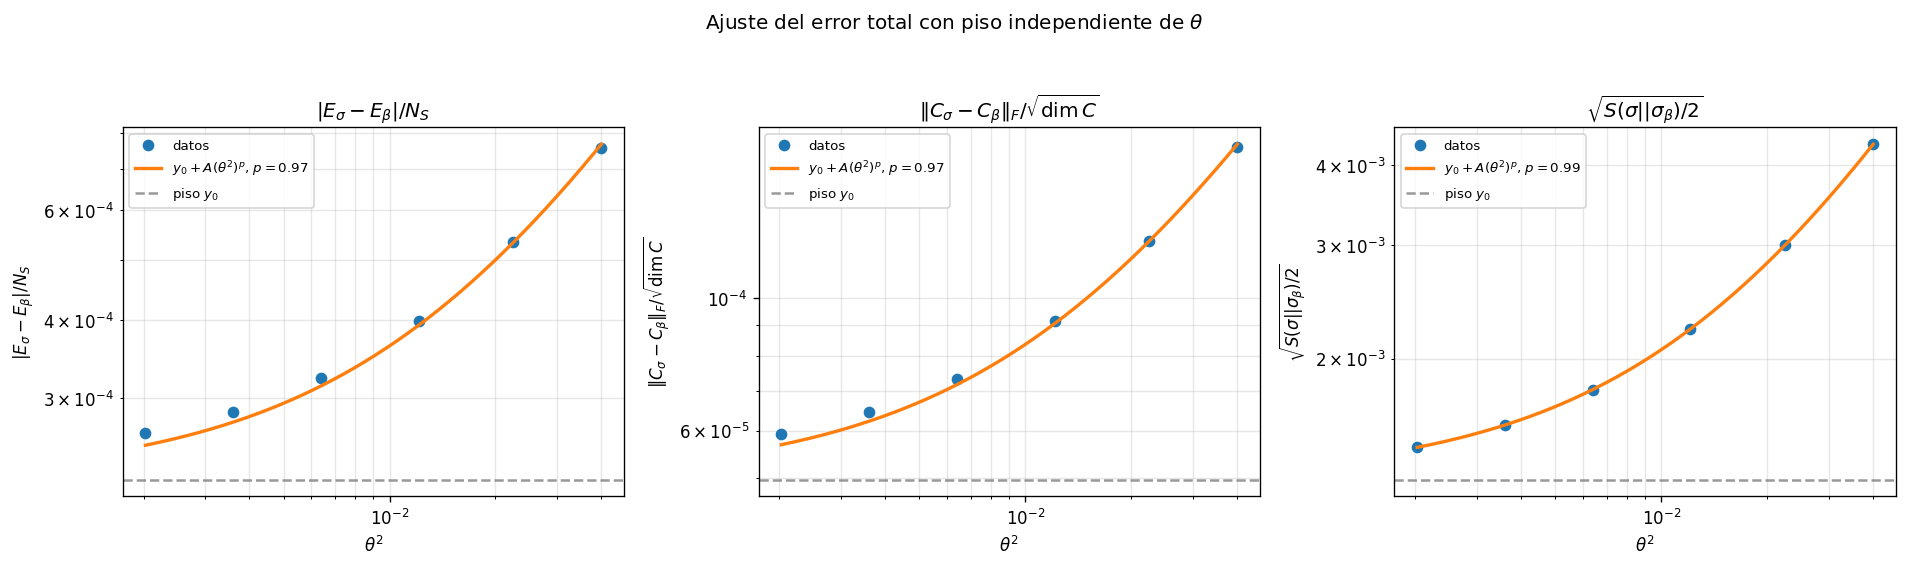

In [ ]:
# A.8.3.4 — Figura auxiliar: ajuste total con piso

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (col, ylabel) in zip(axes, cols_A103_fit.items()):
    res = fit_results_A103[col]

    x = res["x"]
    y = res["y"]

    xx = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 300)
    yy = offset_power_law(
        xx,
        res["y0"],
        res["A"],
        res["p_offset_model"],
    )

    ax.loglog(
        x,
        y,
        "o",
        lw=2,
        label="datos",
    )

    ax.loglog(
        xx,
        yy,
        "-",
        lw=2,
        label=rf"$y_0+A(\theta^2)^p$, $p={res['p_offset_model']:.2f}$",
    )

    ax.axhline(
        res["y0"],
        ls="--",
        color="gray",
        alpha=0.8,
        label=r"piso $y_0$",
    )

    ax.set_xlabel(r"$\theta^2$")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=8)

plt.suptitle(
    r"Ajuste del error total con piso independiente de $\theta$",
    y=1.04,
)

plt.tight_layout()
plt.show()

### A.8.4 Escalado con $N_S$

[A.10.4] N=12
[A.10.4] N=16
[A.10.4] N=20
[A.10.4] N=24
[A.10.4] N=28
[A.10.4] N=36
[A.10.4] N=48


,N,J,beta,theta,T_factor,MT,solver_info,solver_residual,bias_E,bias_E_per_site,cov_fro,sqrt_rel_entropy_bound
0,12,0.7,1.0,0.1,15.0,135,0,2.000000e-10,0.004412,0.000368,0.000129,0.001340
1,16,0.7,1.0,0.1,15.0,135,0,2.000000e-10,0.005910,0.000369,0.000112,0.001553
2,20,0.7,1.0,0.1,15.0,135,0,2.000000e-10,0.007404,0.000370,0.000100,0.001740
3,24,0.7,1.0,0.1,15.0,135,0,2.000000e-10,0.008894,0.000371,0.000092,0.001909
4,28,0.7,1.0,0.1,15.0,135,0,2.000000e-10,0.010379,0.000371,0.000085,0.002063
5,36,0.7,1.0,0.1,15.0,135,0,2.000000e-10,0.013334,0.000370,0.000075,0.002342
6,48,0.7,1.0,0.1,15.0,135,0,2.000000e-10,0.017727,0.000369,0.000065,0.002703


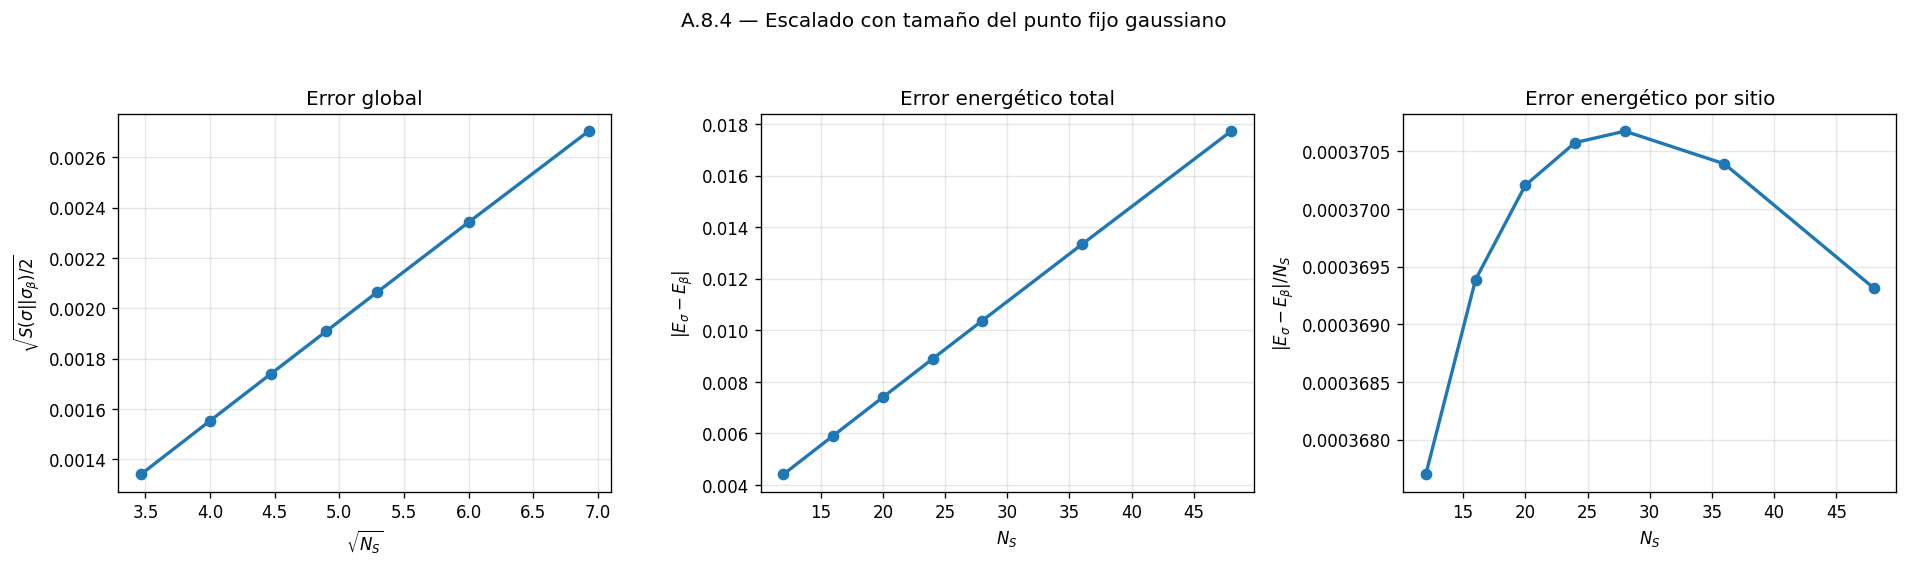

In [9]:
# A.8.4 — Escalado con N_S usando punto fijo gaussiano

N_list_A104 = [12, 16, 20, 24, 28, 36, 48]

params_A104 = dict(
    J=0.7,
    g=1.0,
    beta=1.0,
    theta=0.10,
    delta=np.pi / 80,
    T_factor=15.0,
    randomization_lambda=2.0,
)

rows_A104 = []
outs_A104 = {}

for N in N_list_A104:
    print(f"[A.10.4] N={N}")

    out = run_ff_fixed_point_case(
        N=int(N),
        **params_A104,
        rtol=2e-10,
        maxiter=1200,
    )

    rows_A104.append(out["metrics"])
    outs_A104[int(N)] = out

df_A104 = pd.DataFrame(rows_A104).sort_values("N")

display(df_A104[
    [
        "N",
        "J",
        "beta",
        "theta",
        "T_factor",
        "MT",
        "solver_info",
        "solver_residual",
        "bias_E",
        "bias_E_per_site",
        "cov_fro",
        "sqrt_rel_entropy_bound",
    ]
].round(10))


fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(
    np.sqrt(df_A104["N"]),
    df_A104["sqrt_rel_entropy_bound"],
    "o-",
    lw=2,
)
axes[0].set_xlabel(r"$\sqrt{N_S}$")
axes[0].set_ylabel(r"$\sqrt{S(\sigma||\sigma_\beta)/2}$")
axes[0].set_title("Error global")
axes[0].grid(alpha=0.3)

axes[1].plot(
    df_A104["N"],
    df_A104["bias_E"],
    "o-",
    lw=2,
)
axes[1].set_xlabel(r"$N_S$")
axes[1].set_ylabel(r"$|E_\sigma-E_\beta|$")
axes[1].set_title("Error energético total")
axes[1].grid(alpha=0.3)

axes[2].plot(
    df_A104["N"],
    df_A104["bias_E_per_site"],
    "o-",
    lw=2,
)
axes[2].set_xlabel(r"$N_S$")
axes[2].set_ylabel(r"$|E_\sigma-E_\beta|/N_S$")
axes[2].set_title("Error energético por sitio")
axes[2].grid(alpha=0.3)

plt.suptitle(
    r"A.8.4 — Escalado con tamaño del punto fijo gaussiano",
    y=1.04,
)
plt.tight_layout()
plt.show()

### A.8.5 Randomización y resonancias

[A.10.5] punto fijo sin randomización
[A.10.5] punto fijo con randomización


,N,J,beta,theta,theta2,lambda,T_factor,T_eff,MT,solver_info,solver_residual,bias_E_per_site,cov_fro,sqrt_rel_entropy_bound
0,64,1.0,1.0,0.02,0.0004,0.0,15.0,5.301438,135,1200,2.020000e-08,0.000277,0.000036,0.002170
1,64,1.0,1.0,0.02,0.0004,2.0,15.0,5.301438,135,0,3.000000e-10,0.000277,0.000036,0.002165


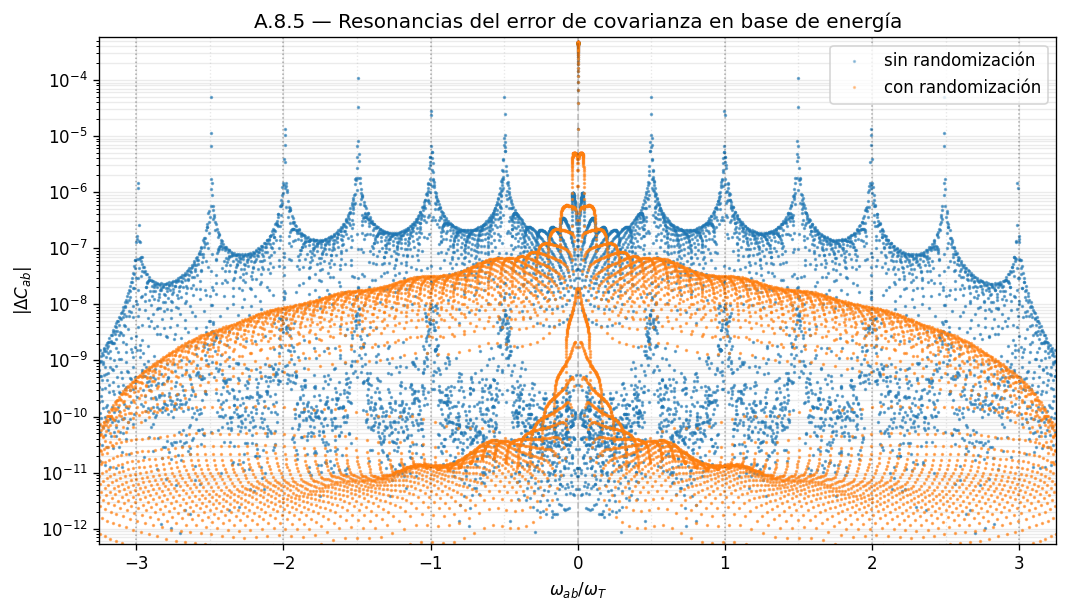

In [ ]:
# A.8.5 — Randomización y resonancias: figura única estilo Fig. 6a


params_A105 = dict(
    N=64,
    J=1.0,
    g=1.0,
    beta=1.0,
    theta=0.020,          # más parecido al régimen débil del paper
    delta=np.pi / 80,     # prueba np.pi/120 si no tarda demasiado
    T_factor=15.0,        # paper usa T=15/a para enfatizar resonancias
)

print("[A.10.5] punto fijo sin randomización")
out_unrand_A105 = run_ff_fixed_point_case(
    **params_A105,
    randomization_lambda=0.0,
    rtol=2e-10,
    maxiter=1200,
)

print("[A.10.5] punto fijo con randomización")
out_rand_A105 = run_ff_fixed_point_case(
    **params_A105,
    randomization_lambda=2.0,
    rtol=2e-10,
    maxiter=1200,
)

df_A105 = pd.DataFrame([
    out_unrand_A105["metrics"],
    out_rand_A105["metrics"],
])

display(df_A105[
    [
        "N",
        "J",
        "beta",
        "theta",
        "theta2",
        "lambda",
        "T_factor",
        "T_eff",
        "MT",
        "solver_info",
        "solver_residual",
        "bias_E_per_site",
        "cov_fro",
        "sqrt_rel_entropy_bound",
    ]
].round(10))


x_un, y_un = covariance_error_energy_basis_fig6a(
    out_unrand_A105,
    subtract_population_blocks=True,
)

x_ra, y_ra = covariance_error_energy_basis_fig6a(
    out_rand_A105,
    subtract_population_blocks=True,
)

# Submuestreo si hay demasiados puntos
rng_A105 = np.random.default_rng(1234)

def subsample_xy(x, y, max_points=45000):
    if len(x) <= max_points:
        return x, y
    idx = rng_A105.choice(len(x), size=max_points, replace=False)
    return x[idx], y[idx]

x_un_p, y_un_p = subsample_xy(x_un, y_un)
x_ra_p, y_ra_p = subsample_xy(x_ra, y_ra)


fig, ax = plt.subplots(figsize=(9.0, 5.2))

ax.semilogy(
    x_un_p,
    y_un_p,
    ".",
    ms=2.0,
    alpha=0.35,
    label="sin randomización",
)

ax.semilogy(
    x_ra_p,
    y_ra_p,
    ".",
    ms=2.0,
    alpha=0.35,
    label="con randomización",
)

# Resonancias enteras y semienteras.
for c in np.arange(-3.0, 3.01, 0.5):
    if abs(c) < 1e-12:
        ax.axvline(c, color="k", ls="--", alpha=0.22, lw=1.0)
    elif abs(c - round(c)) < 1e-12:
        ax.axvline(c, color="k", ls=":", alpha=0.30, lw=0.9)
    else:
        ax.axvline(c, color="gray", ls=":", alpha=0.18, lw=0.8)

ax.set_xlim(-3.25, 3.25)

# Ajuste automático de y para que no lo domine un solo pico.
all_y = np.concatenate([y_un_p, y_ra_p])
y_low = max(np.percentile(all_y, 0.5), 1e-13)
y_high = min(np.percentile(all_y, 99.7) * 5.0, np.max(all_y) * 1.2)

ax.set_ylim(y_low, y_high)

ax.set_xlabel(r"$\omega_{ab}/\omega_T$")
ax.set_ylabel(r"$|\Delta C_{ab}|$")
ax.set_title(
    r"A.8.5 — Resonancias del error de covarianza en base de energía"
)
ax.grid(alpha=0.25, which="both")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()



El análisis espectral de $\Delta C=C_\sigma-C_\beta$ muestra picos resonantes en la base de energía. Sin randomización aparecen estructuras pronunciadas en frecuencias conmensuradas con $\omega_T=2\pi/T$. Al introducir randomización, estas resonancias coherentes se suavizan.

El pico central en $\omega\simeq0$ no desaparece porque corresponde a poblaciones o coherencias casi degeneradas. Esas componentes acumulan poca fase bajo la evolución aleatoria y, por tanto, no se dephasan eficientemente.

# B. Validación Qiskit ideal y coste de implementación

La capa exacta NumPy valida la física del protocolo, pero no garantiza que la construcción Qiskit implemente el mismo canal. En esta sección hacemos tres pruebas compactas:

1. comparar Qiskit `density_matrix` contra NumPy exacto en Ising 1D para varios tamaños;
2. repetir la validación en Ising 2D $2\times2$;
3. estimar recursos Qiskit para una cadena free-fermion, donde la simulación gaussiana de A.10 evita construir matrices densas.

No usamos shots ni ruido aquí. Eso queda para las capas C y D.

In [ ]:
# B.0 — Setup Qiskit compacto

def make_params_B_ising(
    Lx,
    Ly=1,
    J=0.5,
    g=1.0,
    beta=1.0,
    theta=0.25,
    MT=6,
    n_cycles=12,
    periodic=False,
):
    """
    Parámetros compactos para validaciones Qiskit.
    """
    h = max(2.0 * g, 4.0 * J)

    return dict(
        Lx=int(Lx),
        Ly=int(Ly),
        J=float(J),
        g=float(g),
        h=float(h),
        beta=float(beta),
        theta=float(theta),
        delta=np.pi / 40.0,
        MT=int(MT),
        n_cycles=int(n_cycles),
        sys_A="Y",
        bath_A="Y",
        periodic=periodic,
        randomize=False,
        randomization_lambda=0.0,
        seed=1234,
        rewind=False,
    )


def compare_qiskit_dm_vs_numpy_B(params, label):
    """
    Compara Qiskit density_matrix contra NumPy exacto.

    Qiskit devuelve estados después de cada ciclo.
    NumPy suele incluir también rho0. Por eso alineamos índices.
    """
    cfg = build_ising_cfg(**params)
    compiled = compile_protocol(cfg)

    rho0 = maximally_mixed(cfg.n_sys)

    out_np = run_protocol_case(
        cfg,
        rho0=rho0,
        compute_fp=False,
    )

    out_qk = run_qiskit_density_matrix(
        compiled,
        n_cycles=params["n_cycles"],
        rho0_sys=rho0,
    )

    E_np_all = np.asarray(out_np["res"]["energies"], dtype=float)
    E_qk = np.asarray(out_qk["energies"], dtype=float)

    if len(E_np_all) == len(E_qk) + 1:
        E_np = E_np_all[1:]
        rhos_np = out_np["res"]["rhos"][1:]
    else:
        E_np = E_np_all[:len(E_qk)]
        rhos_np = out_np["res"]["rhos"][:len(E_qk)]

    D_np = np.array(
        [trace_distance_dm(rho, out_np["rho_g"]) for rho in rhos_np],
        dtype=float,
    )
    D_qk = np.asarray(out_qk["trace_dists"], dtype=float)

    n = min(len(E_np), len(E_qk), len(D_np), len(D_qk))

    df_traj = pd.DataFrame({
        "cycle": np.arange(1, n + 1),
        "E_numpy": E_np[:n],
        "E_qiskit_dm": E_qk[:n],
        "D_numpy": D_np[:n],
        "D_qiskit_dm": D_qk[:n],
    })

    df_traj["abs_dE"] = np.abs(df_traj["E_numpy"] - df_traj["E_qiskit_dm"])
    df_traj["abs_dD"] = np.abs(df_traj["D_numpy"] - df_traj["D_qiskit_dm"])

    row = {
        "case": label,
        "Lx": params["Lx"],
        "Ly": params["Ly"],
        "N_S": cfg.n_sys,
        "N_total": 2 * cfg.n_sys,
        "J": params["J"],
        "beta": params["beta"],
        "MT": params["MT"],
        "n_cycles": params["n_cycles"],
        "max_abs_dE": float(df_traj["abs_dE"].max()),
        "max_abs_dD": float(df_traj["abs_dD"].max()),
        "E_final_qiskit": float(df_traj["E_qiskit_dm"].iloc[-1]),
        "E_gibbs": float(out_qk["E_gibbs"]),
        "D_final_qiskit": float(df_traj["D_qiskit_dm"].iloc[-1]),
    }

    return {
        "cfg": cfg,
        "compiled": compiled,
        "out_np": out_np,
        "out_qk": out_qk,
        "traj": df_traj,
        "row": row,
    }


def twoq_count_B(ops):
    return int(
        ops.get("cx", 0)
        + ops.get("ecr", 0)
        + ops.get("cz", 0)
        + ops.get("iswap", 0)
    )


def circuit_resource_row_B(qc, label, model, stage):
    ops = dict(qc.count_ops())

    return {
        "label": label,
        "model": model,
        "stage": stage,
        "n_qubits": qc.num_qubits,
        "n_clbits": qc.num_clbits,
        "depth": qc.depth(),
        "size": qc.size(),
        "twoq": twoq_count_B(ops),
        "cx": ops.get("cx", 0),
        "ecr": ops.get("ecr", 0),
        "rz": ops.get("rz", 0),
        "sx": ops.get("sx", 0),
        "x": ops.get("x", 0),
        "measure": ops.get("measure", 0),
        "reset": ops.get("reset", 0),
        "unitary": ops.get("unitary", 0),
    }


backend_bundle_B = get_ising_backend_bundle(min_total_qubits=12)
print("Backend recursos:", backend_bundle_B["label"])

Backend recursos: FakeSherbrooke (snapshot calibraciones reales)


## B.1 Ising 1D: Qiskit DM vs NumPy para varios tamaños

Validamos el builder Qiskit en cadenas Ising 1D con $N_S=2,3,4$. La comparación se hace ciclo a ciclo entre:

- evolución exacta NumPy;
- simulación Qiskit `density_matrix`.

El objetivo es comprobar que Qiskit implementa el mismo mapa ideal que la capa exacta antes de pasar a shots o ruido.

[B.1] Ising 1D N=2
[B.1] Ising 1D N=3
[B.1] Ising 1D N=4
Tiempo B.1: 36.8s


,case,Lx,Ly,N_S,N_total,J,beta,MT,n_cycles,max_abs_dE,max_abs_dD,E_final_qiskit,E_gibbs,D_final_qiskit
0,Ising 1D N=2,2,1,2,4,0.5,1.0,6,12,0.0,0.0,-0.737175,-1.607196,0.326274
1,Ising 1D N=3,3,1,3,6,0.5,1.0,6,12,0.0,0.0,-1.139971,-2.456308,0.375825
2,Ising 1D N=4,4,1,4,8,0.5,1.0,6,12,0.0,0.0,-1.542345,-3.305535,0.416256


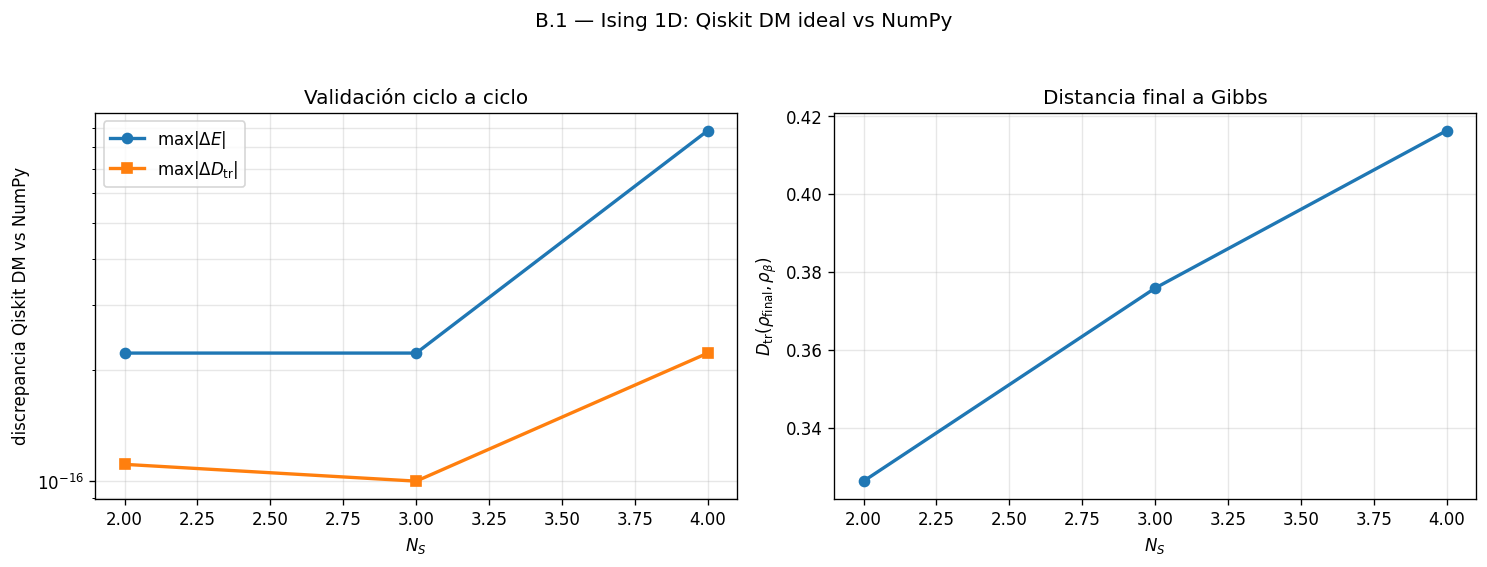

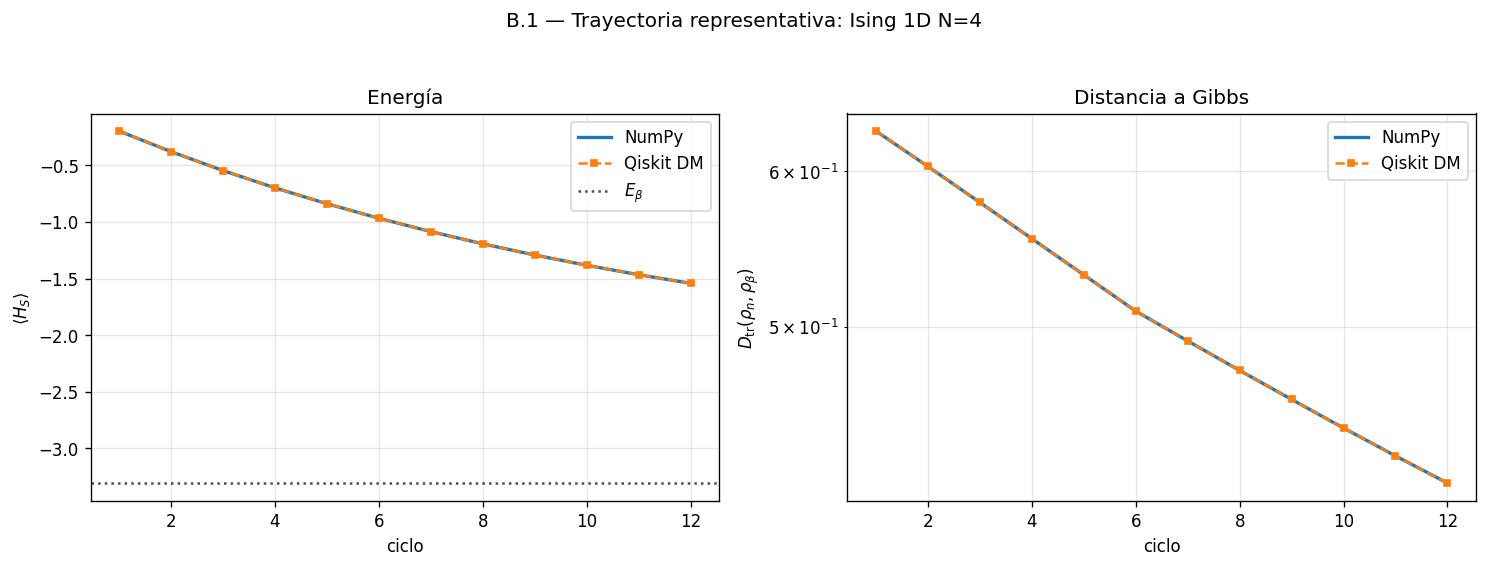

In [13]:
# B.1 — Ising 1D: Qiskit density_matrix vs NumPy para N_S=2,3,4

cases_B1 = []

for N in [2, 3, 4]:
    params = make_params_B_ising(
        Lx=N,
        Ly=1,
        J=0.5,
        beta=1.0,
        MT=6,
        n_cycles=12,
        theta=0.25,
    )
    cases_B1.append((f"Ising 1D N={N}", params))

results_B1 = {}
rows_B1 = []

t0 = time.time()

for label, params in cases_B1:
    print(f"[B.1] {label}")

    res = compare_qiskit_dm_vs_numpy_B(params, label)
    results_B1[label] = res
    rows_B1.append(res["row"])

    gc.collect()

df_B1 = pd.DataFrame(rows_B1)

print(f"Tiempo B.1: {time.time() - t0:.1f}s")
display(df_B1.round(10))


fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

axes[0].semilogy(
    df_B1["N_S"],
    np.maximum(df_B1["max_abs_dE"], 1e-16),
    "o-",
    lw=2,
    label=r"$\max|\Delta E|$",
)
axes[0].semilogy(
    df_B1["N_S"],
    np.maximum(df_B1["max_abs_dD"], 1e-16),
    "s-",
    lw=2,
    label=r"$\max|\Delta D_{\rm tr}|$",
)
axes[0].set_xlabel(r"$N_S$")
axes[0].set_ylabel("discrepancia Qiskit DM vs NumPy")
axes[0].set_title("Validación ciclo a ciclo")
axes[0].grid(alpha=0.3, which="both")
axes[0].legend()

axes[1].plot(
    df_B1["N_S"],
    df_B1["D_final_qiskit"],
    "o-",
    lw=2,
)
axes[1].set_xlabel(r"$N_S$")
axes[1].set_ylabel(r"$D_{\rm tr}(\rho_{\rm final},\rho_\beta)$")
axes[1].set_title("Distancia final a Gibbs")
axes[1].grid(alpha=0.3)

plt.suptitle("B.1 — Ising 1D: Qiskit DM ideal vs NumPy", y=1.04)
plt.tight_layout()
plt.show()


# Figura de trayectoria solo para el mayor tamaño, para no saturar.
label_plot_B1 = "Ising 1D N=4"
traj_B1 = results_B1[label_plot_B1]["traj"]
E_gibbs_B1 = results_B1[label_plot_B1]["out_qk"]["E_gibbs"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

axes[0].plot(traj_B1["cycle"], traj_B1["E_numpy"], "-", lw=2, label="NumPy")
axes[0].plot(traj_B1["cycle"], traj_B1["E_qiskit_dm"], "s--", ms=4, label="Qiskit DM")
axes[0].axhline(E_gibbs_B1, ls=":", color="k", alpha=0.7, label=r"$E_\beta$")
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel(r"$\langle H_S\rangle$")
axes[0].set_title("Energía")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].semilogy(traj_B1["cycle"], traj_B1["D_numpy"], "-", lw=2, label="NumPy")
axes[1].semilogy(traj_B1["cycle"], traj_B1["D_qiskit_dm"], "s--", ms=4, label="Qiskit DM")
axes[1].set_xlabel("ciclo")
axes[1].set_ylabel(r"$D_{\rm tr}(\rho_n,\rho_\beta)$")
axes[1].set_title("Distancia a Gibbs")
axes[1].grid(alpha=0.3, which="both")
axes[1].legend()

plt.suptitle("B.1 — Trayectoria representativa: Ising 1D N=4", y=1.04)
plt.tight_layout()
plt.show()



La simulación Qiskit `density_matrix` reproduce la evolución exacta NumPy para cadenas Ising 1D con $N_S=2,3,4$. Las discrepancias máximas en energía y distancia traza son de precisión numérica, lo que valida el builder ideal en 1D.

La distancia final a Gibbs aumenta con el tamaño para estos parámetros porque el número de ciclos y el filtro se mantienen fijos; no es un fallo de Qiskit, sino una limitación del protocolo finito.

## B.2 Ising 2D $2\times2$: Qiskit DM vs NumPy

Repetimos la validación en el primer caso 2D no trivial, $N_S=4$. Usamos dos puntos del plano físico:

- régimen caliente con interacción moderada;
- régimen más frío e interactuante.

Esto comprueba que el builder Qiskit maneja correctamente la geometría 2D y no solo cadenas.

[B.2] 2D 2x2 caliente
[B.2] 2D 2x2 frío/interactuante
Tiempo B.2: 32.8s


,case,Lx,Ly,N_S,N_total,J,beta,MT,n_cycles,max_abs_dE,max_abs_dD,E_final_qiskit,E_gibbs,D_final_qiskit
0,2D 2x2 caliente,2,2,4,8,0.3,0.5,5,10,0.0,0.0,-1.110945,-1.981789,0.185920
1,2D 2x2 frío/interactuante,2,2,4,8,1.0,1.0,5,10,0.0,0.0,-2.889235,-4.756150,0.413066


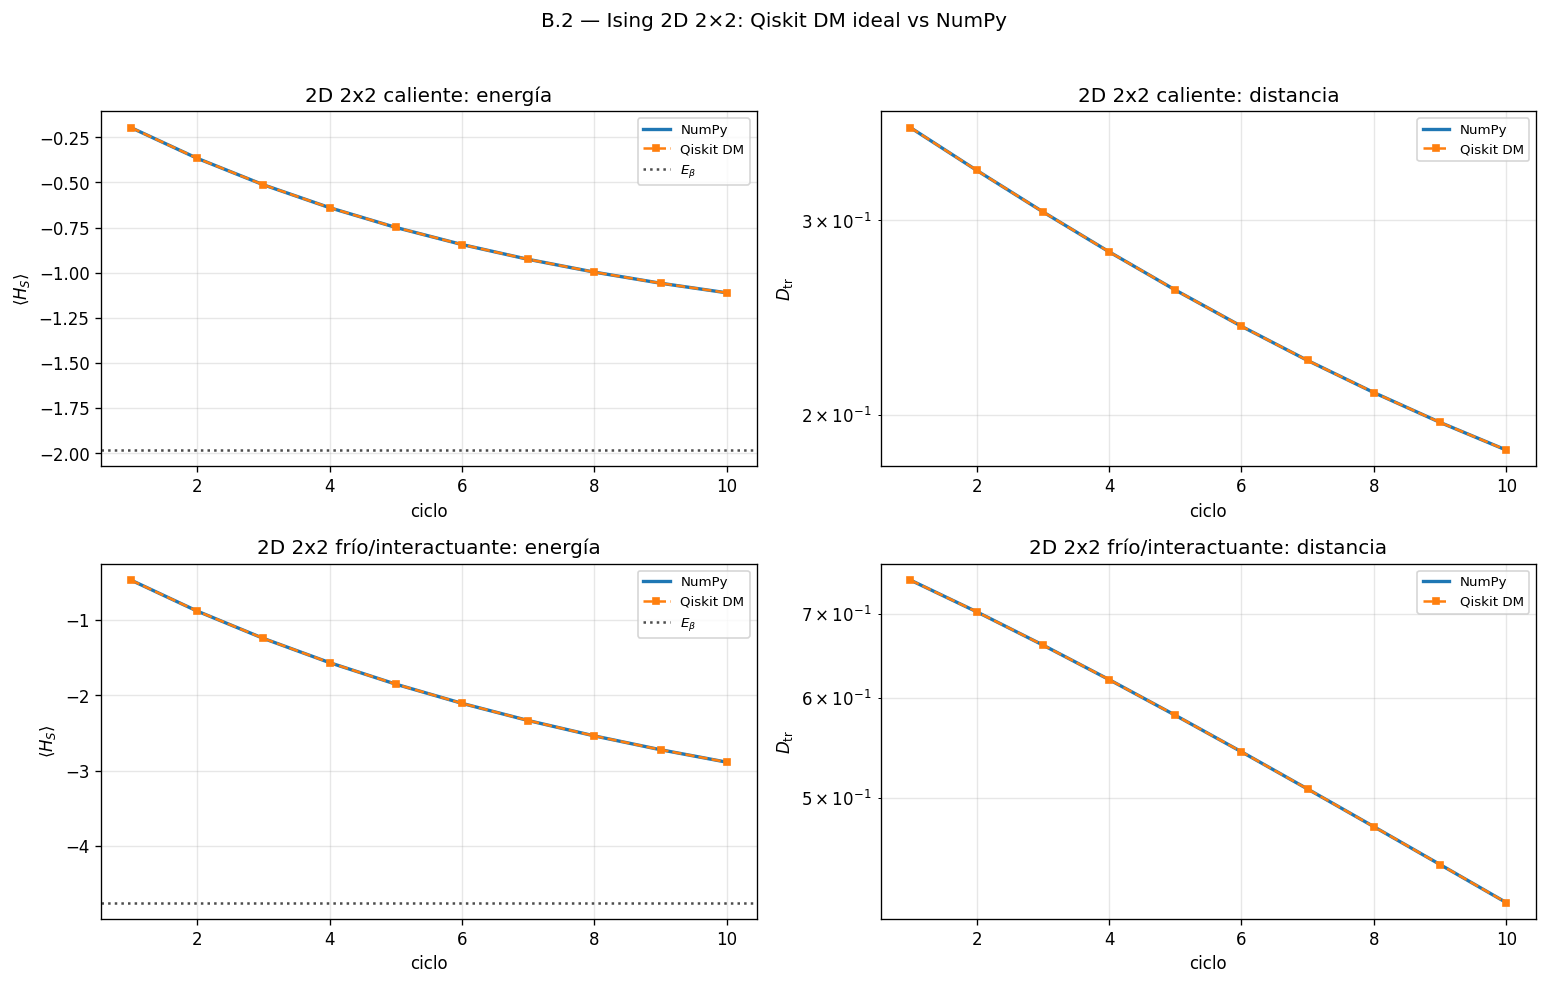

In [14]:
# B.2 — Ising 2D 2×2: Qiskit density_matrix vs NumPy

cases_B2 = [
    (
        "2D 2x2 caliente",
        make_params_B_ising(
            Lx=2,
            Ly=2,
            J=0.3,
            beta=0.5,
            MT=5,
            n_cycles=10,
            theta=0.30,
        ),
    ),
    (
        "2D 2x2 frío/interactuante",
        make_params_B_ising(
            Lx=2,
            Ly=2,
            J=1.0,
            beta=1.0,
            MT=5,
            n_cycles=10,
            theta=0.30,
        ),
    ),
]

results_B2 = {}
rows_B2 = []

t0 = time.time()

for label, params in cases_B2:
    print(f"[B.2] {label}")

    res = compare_qiskit_dm_vs_numpy_B(params, label)
    results_B2[label] = res
    rows_B2.append(res["row"])

    gc.collect()

df_B2 = pd.DataFrame(rows_B2)

print(f"Tiempo B.2: {time.time() - t0:.1f}s")
display(df_B2.round(10))


fig, axes = plt.subplots(2, 2, figsize=(13, 8.0))

for row_idx, (label, _) in enumerate(cases_B2):
    traj = results_B2[label]["traj"]
    E_gibbs = results_B2[label]["out_qk"]["E_gibbs"]

    axE = axes[row_idx, 0]
    axD = axes[row_idx, 1]

    axE.plot(traj["cycle"], traj["E_numpy"], "-", lw=2, label="NumPy")
    axE.plot(traj["cycle"], traj["E_qiskit_dm"], "s--", ms=4, label="Qiskit DM")
    axE.axhline(E_gibbs, ls=":", color="k", alpha=0.7, label=r"$E_\beta$")
    axE.set_title(f"{label}: energía")
    axE.set_xlabel("ciclo")
    axE.set_ylabel(r"$\langle H_S\rangle$")
    axE.grid(alpha=0.3)
    axE.legend(fontsize=8)

    axD.semilogy(traj["cycle"], traj["D_numpy"], "-", lw=2, label="NumPy")
    axD.semilogy(traj["cycle"], traj["D_qiskit_dm"], "s--", ms=4, label="Qiskit DM")
    axD.set_title(f"{label}: distancia")
    axD.set_xlabel("ciclo")
    axD.set_ylabel(r"$D_{\rm tr}$")
    axD.grid(alpha=0.3, which="both")
    axD.legend(fontsize=8)

plt.suptitle("B.2 — Ising 2D 2×2: Qiskit DM ideal vs NumPy", y=1.02)
plt.tight_layout()
plt.show()



La simulación Qiskit `density_matrix` reproduce la evolución exacta NumPy para cadenas Ising 1D con $N_S=2,3,4$. Las discrepancias máximas en energía y distancia traza son de precisión numérica, lo que valida el builder ideal en 1D.

La distancia final a Gibbs aumenta con el tamaño para estos parámetros porque el número de ciclos y el filtro se mantienen fijos; no es un fallo de Qiskit, sino una limitación del protocolo finito.

## B.3 Free-fermion chain: coste Qiskit del bloque gaussiano

La sección A.10 simula cadenas free-fermion mediante matrices de covarianza. Aquí preguntamos cuánto costaría implementar un bloque análogo en Qiskit bajo Jordan–Wigner.

No ejecutamos `density_matrix` para estos tamaños: el objetivo es estimar recursos. La comparación muestra por qué el método gaussiano es esencial para estudiar tamaños mayores.

In [ ]:
# B.3 — Recursos Qiskit para free-fermion chain bajo Jordan-Wigner

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter




# Barrido de recursos free-fermion
ff_N_list_B3 = [2, 3, 4, 5]

rows_B3_ff = []

hw_backend_B = backend_bundle_B["hw_backend"]

for N in ff_N_list_B3:
    print(f"[B.3] free-fermion N={N}")

    qc_ff_logical = build_free_fermion_protocol_resource_circuit_B(
        N=N,
        J=1.0,
        g=1.0,
        h=2.0,
        beta=1.0,
        theta=0.05,
        MT=2,
        n_cycles=1,
        measure_bath=True,
    )

    qc_ff_isa = safe_transpile_B(
        qc_ff_logical,
        backend=hw_backend_B,
        optimization_level=1,
    )

    rows_B3_ff.append(
        circuit_resource_row_B(
            qc_ff_logical,
            label=f"free fermion N={N}",
            model="free-fermion JW",
            stage="logical",
        )
    )

    rows_B3_ff.append(
        circuit_resource_row_B(
            qc_ff_isa,
            label=f"free fermion N={N}",
            model="free-fermion JW",
            stage="ISA",
        )
    )

    gc.collect()

df_B3_ff_resources = pd.DataFrame(rows_B3_ff)
df_B3_ff_resources["N_active_logical"] = (
    df_B3_ff_resources["label"].str.extract(r"N=(\d+)").astype(int)[0] * 2
)

display(df_B3_ff_resources[
    [
        "label",
        "model",
        "stage",
        "N_active_logical",
        "n_qubits",
        "n_clbits",
        "depth",
        "size",
        "twoq",
        "cx",
        "measure",
        "reset",
    ]
])

[B.3] free-fermion N=2
[B.3] free-fermion N=3
[B.3] free-fermion N=4
[B.3] free-fermion N=5


,label,model,stage,N_active_logical,n_qubits,n_clbits,depth,size,twoq,cx,measure,reset
0,free fermion N=2,free-fermion JW,logical,4,4,2,18,21,0,0,2,2
1,free fermion N=2,free-fermion JW,ISA,4,127,2,254,415,70,0,2,2
2,free fermion N=3,free-fermion JW,logical,6,6,3,18,24,0,0,3,3
3,free fermion N=3,free-fermion JW,ISA,6,127,3,440,821,140,0,3,3
4,free fermion N=4,free-fermion JW,logical,8,8,4,18,27,0,0,4,4
5,free fermion N=4,free-fermion JW,ISA,8,127,4,1002,1786,320,0,4,4
6,free fermion N=5,free-fermion JW,logical,10,10,5,18,30,0,0,5,5
7,free fermion N=5,free-fermion JW,ISA,10,127,5,1132,2448,454,0,5,5


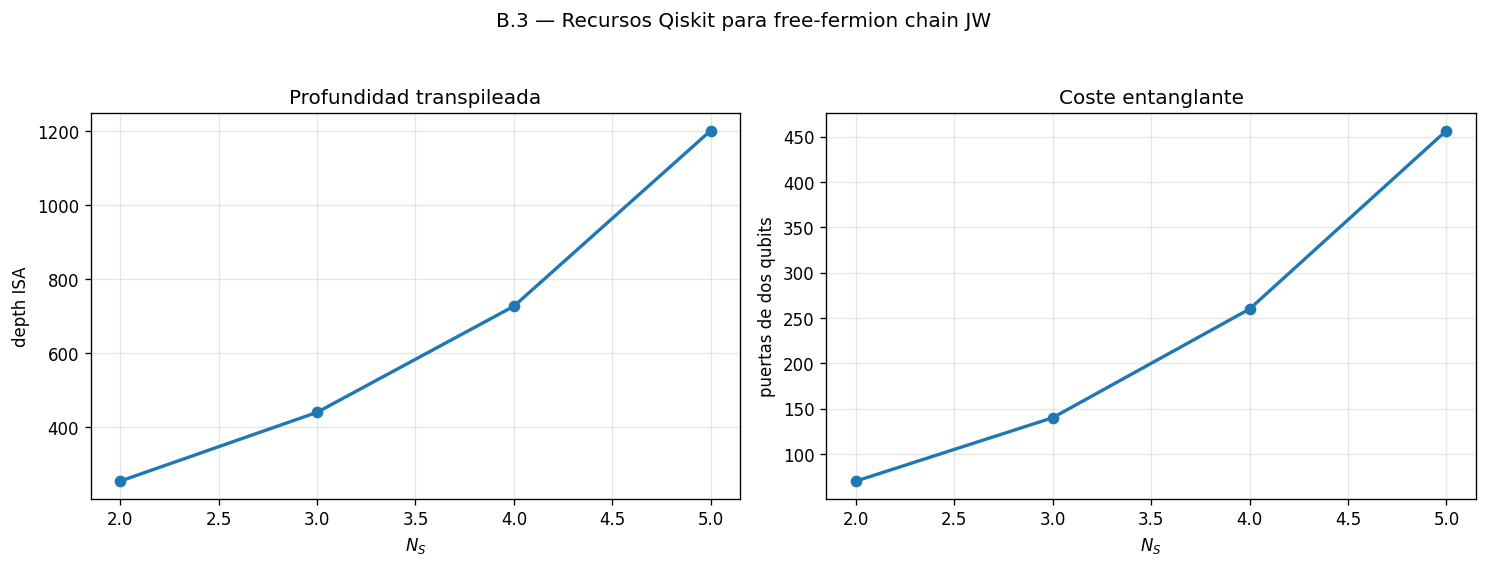

In [8]:
# B.3 — Figura de recursos free-fermion

df_ff_isa_B3 = df_B3_ff_resources[df_B3_ff_resources["stage"] == "ISA"].copy()
df_ff_isa_B3["N_S"] = df_ff_isa_B3["label"].str.extract(r"N=(\d+)").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

axes[0].plot(
    df_ff_isa_B3["N_S"],
    df_ff_isa_B3["depth"],
    "o-",
    lw=2,
)
axes[0].set_xlabel(r"$N_S$")
axes[0].set_ylabel("depth ISA")
axes[0].set_title("Profundidad transpileada")
axes[0].grid(alpha=0.3)

axes[1].plot(
    df_ff_isa_B3["N_S"],
    df_ff_isa_B3["twoq"],
    "o-",
    lw=2,
)
axes[1].set_xlabel(r"$N_S$")
axes[1].set_ylabel("puertas de dos qubits")
axes[1].set_title("Coste entanglante")
axes[1].grid(alpha=0.3)

plt.suptitle("B.3 — Recursos Qiskit para free-fermion chain JW", y=1.04)
plt.tight_layout()
plt.show()



La implementación directa de una cadena free-fermion bajo Jordan–Wigner introduce strings de Pauli crecientes. Aunque el modelo es eficiente en covarianzas gaussianas, su traducción directa a circuitos Qiskit no escala de forma igual de favorable.

Por eso esta celda no sustituye a A.10: solo estima el coste de una implementación Qiskit directa del bloque free-fermion. El resultado justifica usar la capa gaussiana para tamaños grandes.

## B.4 Síntesis de validación y recursos

La capa B separa dos mensajes:

1. Para Ising 1D y 2D pequeños, Qiskit `density_matrix` reproduce la evolución exacta NumPy a precisión numérica.
2. Para free-fermion, la representación gaussiana de A.10 es eficiente, pero una implementación directa bajo Jordan–Wigner en Qiskit genera un coste de circuito creciente.

No usamos aquí la transpilación ISA completa de los bloques densos Ising como resultado principal, porque produce una estimación demasiado dependiente de la descomposición de unitarios densos. La geometría hardware y los recursos dinámicos compactos se estudian en la capa C.

,family,case,N_S,N_total,J,beta,MT,n_cycles,max_abs_dE,max_abs_dD,D_final_qiskit
0,Ising 1D,Ising 1D N=2,2,4,0.500,1.000,6,12,2.22e-16,1.11e-16,0.326274
1,Ising 1D,Ising 1D N=3,3,6,0.500,1.000,6,12,2.22e-16,5.55e-17,0.375825
2,Ising 1D,Ising 1D N=4,4,8,0.500,1.000,6,12,8.88e-16,2.22e-16,0.416256
3,Ising 2D,2D 2x2 caliente,4,8,0.300,0.500,5,10,3.33e-16,1.67e-16,0.185920
4,Ising 2D,2D 2x2 frío/interactuante,4,8,1.000,1.000,5,10,8.88e-16,2.22e-16,0.413066


,label,N_S,N_active_logical,n_qubits,depth,size,twoq,cx,measure,reset
0,free fermion N=2,2,4,127,254,415,70,0,2,2
1,free fermion N=3,3,6,127,440,821,140,0,3,3
2,free fermion N=4,4,8,127,1002,1786,320,0,4,4
3,free fermion N=5,5,10,127,1132,2448,454,0,5,5


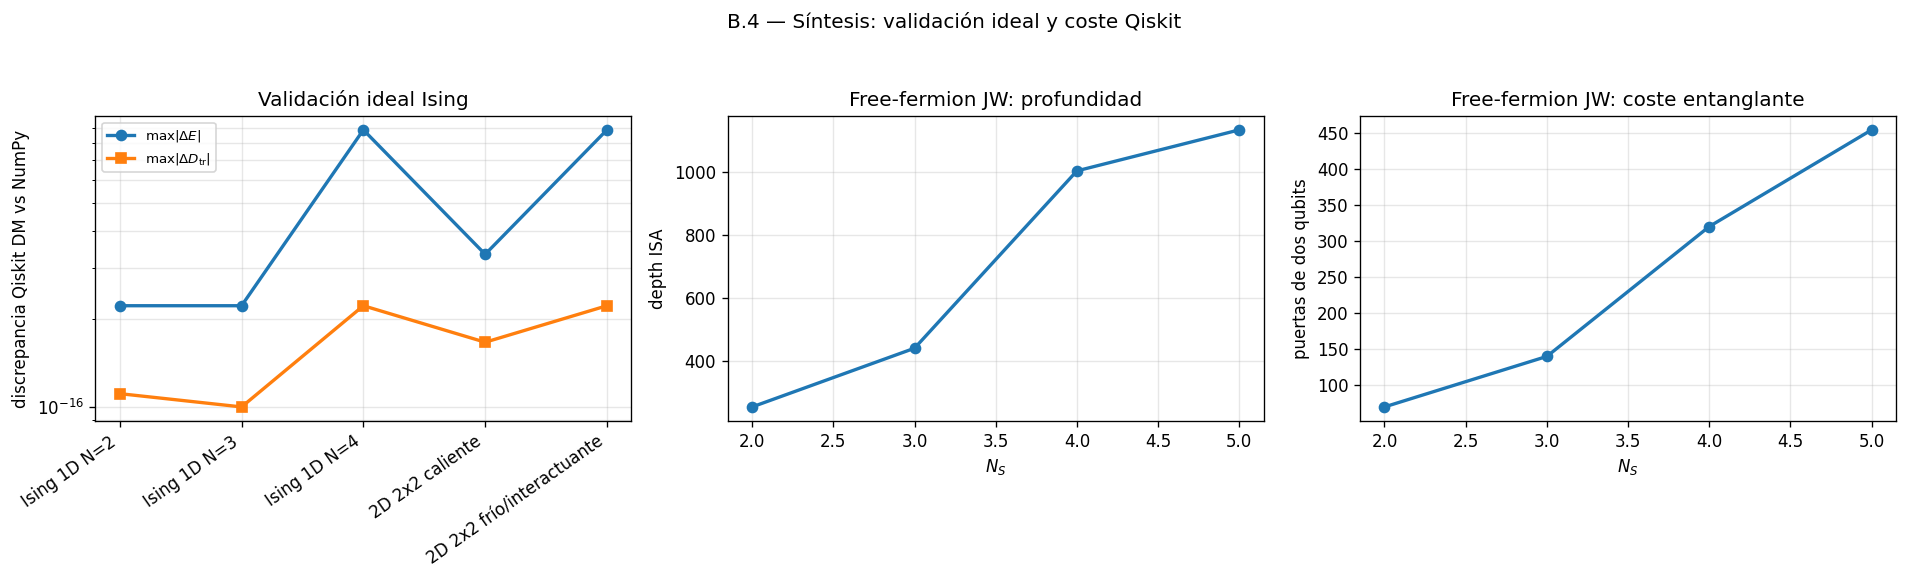

In [21]:
# B.4 — Síntesis limpia de validación y recursos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Tabla de validación Ising: B.1 + B.2
# ------------------------------------------------------------

df_B4_validation = pd.concat(
    [
        df_B1.assign(family="Ising 1D"),
        df_B2.assign(family="Ising 2D"),
    ],
    ignore_index=True,
)

df_B4_validation = df_B4_validation[
    [
        "family",
        "case",
        "N_S",
        "N_total",
        "J",
        "beta",
        "MT",
        "n_cycles",
        "max_abs_dE",
        "max_abs_dD",
        "D_final_qiskit",
    ]
]

display(
    df_B4_validation.style.format({
        "max_abs_dE": "{:.2e}",
        "max_abs_dD": "{:.2e}",
        "D_final_qiskit": "{:.6f}",
        "J": "{:.3f}",
        "beta": "{:.3f}",
    })
)


# ------------------------------------------------------------
# Tabla de recursos free-fermion JW: usar resultados de B.3
# ------------------------------------------------------------

df_B4_ff = df_B3_ff_resources.copy()
df_B4_ff["N_S"] = df_B4_ff["label"].str.extract(r"N=(\d+)").astype(int)
df_B4_ff["N_active_logical"] = 2 * df_B4_ff["N_S"]

df_B4_ff_isa = (
    df_B4_ff[df_B4_ff["stage"] == "ISA"]
    .sort_values("N_S")
    .reset_index(drop=True)
)

display(df_B4_ff_isa[
    [
        "label",
        "N_S",
        "N_active_logical",
        "n_qubits",
        "depth",
        "size",
        "twoq",
        "cx",
        "measure",
        "reset",
    ]
])


# ------------------------------------------------------------
# Figura resumen
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# Panel 1: discrepancia Qiskit vs NumPy
x = np.arange(len(df_B4_validation))

axes[0].semilogy(
    x,
    np.maximum(df_B4_validation["max_abs_dE"], 1e-16),
    "o-",
    lw=2,
    label=r"$\max|\Delta E|$",
)

axes[0].semilogy(
    x,
    np.maximum(df_B4_validation["max_abs_dD"], 1e-16),
    "s-",
    lw=2,
    label=r"$\max|\Delta D_{\rm tr}|$",
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(df_B4_validation["case"], rotation=35, ha="right")
axes[0].set_ylabel("discrepancia Qiskit DM vs NumPy")
axes[0].set_title("Validación ideal Ising")
axes[0].grid(alpha=0.3, which="both")
axes[0].legend(fontsize=8)


# Panel 2: profundidad free-fermion JW
axes[1].plot(
    df_B4_ff_isa["N_S"],
    df_B4_ff_isa["depth"],
    "o-",
    lw=2,
)

axes[1].set_xlabel(r"$N_S$")
axes[1].set_ylabel("depth ISA")
axes[1].set_title("Free-fermion JW: profundidad")
axes[1].grid(alpha=0.3)


# Panel 3: coste entanglante free-fermion JW
axes[2].plot(
    df_B4_ff_isa["N_S"],
    df_B4_ff_isa["twoq"],
    "o-",
    lw=2,
)

axes[2].set_xlabel(r"$N_S$")
axes[2].set_ylabel("puertas de dos qubits")
axes[2].set_title("Free-fermion JW: coste entanglante")
axes[2].grid(alpha=0.3)

plt.suptitle("B.4 — Síntesis: validación ideal y coste Qiskit", y=1.04)
plt.tight_layout()
plt.show()



La capa B deja dos mensajes. Primero, la simulación ideal de Qiskit reproduce la evolución exacta NumPy para los casos Ising analizados, con discrepancias de precisión numérica. Segundo, una implementación directa de la cadena free-fermion bajo Jordan–Wigner en Qiskit presenta un coste creciente en profundidad y puertas de dos qubits. Esto justifica el uso de la capa gaussiana para el benchmark free-fermion y reserva Qiskit para validación ideal y análisis de recursos.

# C. Shots ISA y recursos hardware

## C.0 Geometría hardware: sistema + baños

Antes de ejecutar circuitos ISA, fijamos una asignación física orientativa de qubits de sistema y qubits baño sobre el backend. El objetivo no es imponer manualmente un layout óptimo, sino visualizar si la geometría lógica del protocolo puede colocarse de forma razonable sobre el grafo de conectividad.

Mostramos dos casos:

- Ising 1D, donde el sistema se asigna a una cadena de qubits físicos y cada sitio recibe un baño cercano;
- Ising 2D $2\times2$, donde el sistema se asigna a un parche conectado y los baños se colocan como qubits auxiliares cercanos.

Las líneas continuas indican acoplos físicos nativos disponibles; las líneas discontinuas indican acoplos lógicos que el transpiler deberá resolver mediante routing.

Backend: fake_sherbrooke
n_qubits: 127
n_edges: 144


,caso,system_qubits,bath_qubits,logical_edges_native,logical_edges_total,bath_distances,direct_baths,max_bath_distance,total_swaps_one_way
0,Ising 1D N=4,"(23, 22, 15, 4)","(24, 21, 3, 5)",3,3,"(1, 1, 2, 1)",3/4,2,1
1,Ising 2D 2x2,"(3, 4, 6, 5)","(2, 15, 7, 22)",3,4,"(1, 1, 1, 3)",3/4,3,2


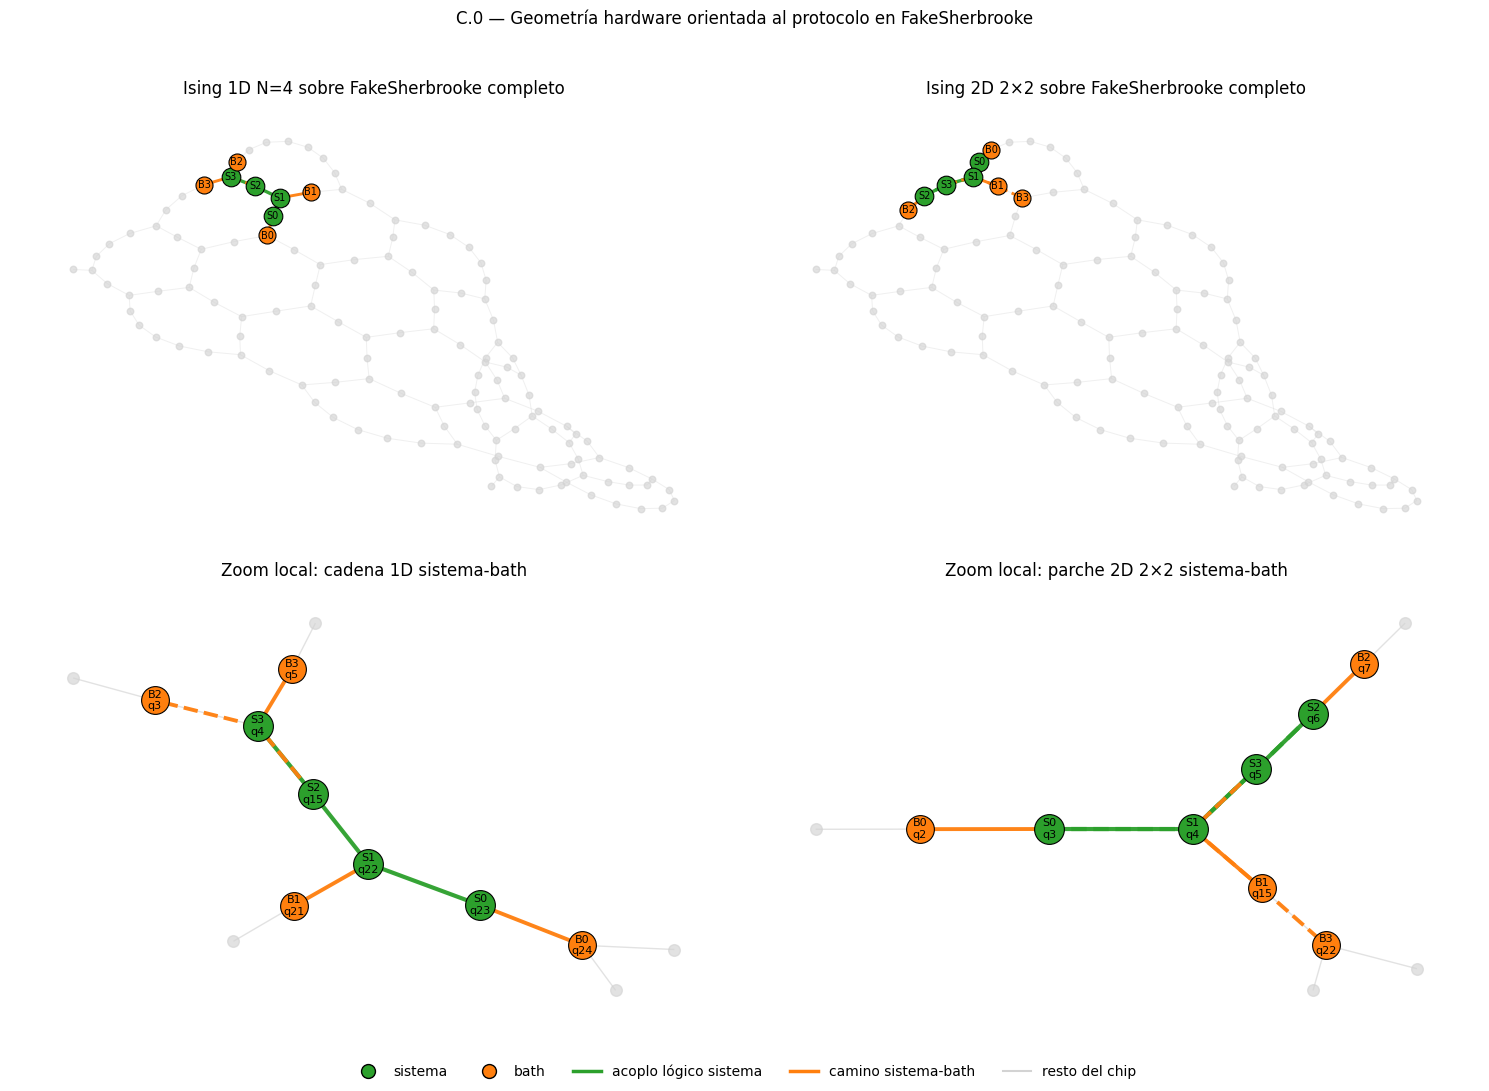

In [4]:
# C.0 — FakeSherbrooke completo + zoom local con embeddings manuales curados

backend_sherbrooke_C0 = load_fake_sherbrooke_C0()
G_sherbrooke_C0 = backend_graph_C0(backend_sherbrooke_C0)

print("Backend:", backend_name_C0(backend_sherbrooke_C0))
print("n_qubits:", backend_num_qubits_C0(backend_sherbrooke_C0))
print("n_edges:", G_sherbrooke_C0.number_of_edges())

# ------------------------------------------------------------------
# Embeddings manuales: usa estos como versión final compacta.
# Si quieres, luego puedes cambiar los qubits por los de tu notebook viejo.
# ------------------------------------------------------------------

# 1D: cadena clara
embedding_1d_C0 = make_manual_embedding_C0(
    G_sherbrooke_C0,
    case="Ising 1D N=4",
    system_qubits=[23, 22, 15, 4],
    bath_qubits=[24, 21, 3, 5],
    logical_edges=[(0, 1), (1, 2), (2, 3)],
)

# 2D 2x2: parche distinto del 1D, visualmente más claro
embedding_2d_C0 = make_manual_embedding_C0(
    G_sherbrooke_C0,
    case="Ising 2D 2x2",
    system_qubits=[3, 4, 6, 5],
    bath_qubits=[2, 15, 7, 22],
    logical_edges=[(0, 1), (0, 2), (1, 3), (2, 3)],
)

df_C0_geometry = pd.DataFrame([
    embedding_summary_C0(embedding_1d_C0),
    embedding_summary_C0(embedding_2d_C0),
])

display(df_C0_geometry)

# layout global del chip completo
pos_full_C0 = nx.spring_layout(
    G_sherbrooke_C0,
    seed=7,
    iterations=300,
)

# zooms locales
pos_zoom_1d_C0 = make_zoom_pos_C0(G_sherbrooke_C0, embedding_1d_C0)
pos_zoom_2d_C0 = make_zoom_pos_C0(G_sherbrooke_C0, embedding_2d_C0)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

draw_embedding_C0(
    axes[0, 0],
    G_sherbrooke_C0,
    embedding_1d_C0,
    pos_full_C0,
    full_chip=True,
    title="Ising 1D N=4 sobre FakeSherbrooke completo",
)

draw_embedding_C0(
    axes[0, 1],
    G_sherbrooke_C0,
    embedding_2d_C0,
    pos_full_C0,
    full_chip=True,
    title="Ising 2D 2×2 sobre FakeSherbrooke completo",
)

draw_embedding_C0(
    axes[1, 0],
    G_sherbrooke_C0,
    embedding_1d_C0,
    pos_zoom_1d_C0,
    full_chip=False,
    title="Zoom local: cadena 1D sistema-bath",
)

draw_embedding_C0(
    axes[1, 1],
    G_sherbrooke_C0,
    embedding_2d_C0,
    pos_zoom_2d_C0,
    full_chip=False,
    title="Zoom local: parche 2D 2×2 sistema-bath",
)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", label="sistema",
           markerfacecolor="tab:green", markeredgecolor="black", markersize=10),
    Line2D([0], [0], marker="o", color="w", label="bath",
           markerfacecolor="tab:orange", markeredgecolor="black", markersize=10),
    Line2D([0], [0], color="tab:green", lw=2.5, label="acoplo lógico sistema"),
    Line2D([0], [0], color="tab:orange", lw=2.5, label="camino sistema-bath"),
    Line2D([0], [0], color="lightgray", lw=1.5, label="resto del chip"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
)

plt.suptitle(
    "C.0 — Geometría hardware orientada al protocolo en FakeSherbrooke",
    y=0.98,
)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

## C.1 Setup ISA y régimen base

Fijamos un caso pequeño de Ising 1D para ejecutar circuitos dinámicos con reset de baños. Este caso se usa como referencia para las celdas de shots posteriores.

In [12]:
# C.1 — Setup ISA y régimen base

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from tfm_ising.model import (
    make_compiled_ising,
    get_ising_backend_bundle,
    get_isa_dynamic_circuit_ising,
    run_isa_dynamic_shots_ising,
)

# Caso base compacto
params_C_base = dict(
    Lx=3,
    Ly=1,
    J=0.5,
    g=1.0,
    h=2.0,
    beta=1.0,
    theta=0.25,
    delta=np.pi / 40,
    MT=8,
    n_cycles=6,
    sys_A="Y",
    bath_A="Y",
    periodic=False,
    randomize=False,
    randomization_lambda=0.0,
    seed=1234,
    rewind=False,
)

_, compiled_C_base = make_compiled_ising(params_C_base)

backend_bundle_C = get_ising_backend_bundle(
    min_total_qubits=2 * compiled_C_base["cfg"].n_sys,
)

qc_isa_C_base = get_isa_dynamic_circuit_ising(
    compiled_C_base,
    n_cycles=params_C_base["n_cycles"],
    init_label="0" * compiled_C_base["cfg"].n_sys,
    final_basis="Z",
    optimization_level=1,
    backend_bundle=backend_bundle_C,
)

ops_C_base = dict(qc_isa_C_base.count_ops())

df_C1 = pd.DataFrame([{
    "backend": backend_bundle_C["label"],
    "N_S": compiled_C_base["cfg"].n_sys,
    "N_B": compiled_C_base["cfg"].n_bath,
    "n_cycles": params_C_base["n_cycles"],
    "MT": params_C_base["MT"],
    "theta": params_C_base["theta"],
    "beta": params_C_base["beta"],
    "depth": qc_isa_C_base.depth(),
    "size": qc_isa_C_base.size(),
    "width": qc_isa_C_base.width(),
    "cx": ops_C_base.get("cx", 0),
    "ecr": ops_C_base.get("ecr", 0),
    "rz": ops_C_base.get("rz", 0),
    "sx": ops_C_base.get("sx", 0),
    "measure": ops_C_base.get("measure", 0),
    "reset": ops_C_base.get("reset", 0),
}])

display(df_C1)

,backend,N_S,N_B,n_cycles,MT,theta,beta,depth,size,width,cx,ecr,rz,sx,measure,reset
0,FakeSherbrooke (snapshot calibraciones reales),3,3,6,8,0.25,1.0,98584,168605,148,0,26172,81327,57086,21,18


## C.2 Baño antes del reset

Medimos la probabilidad de excitación del baño justo antes del reset en cada ciclo. Esta señal es una comprobación directa de que el baño absorbe energía/información del sistema antes de ser reinicializado.

[C.2] shots=128
[C.2] shots=512
[C.2] shots=2048


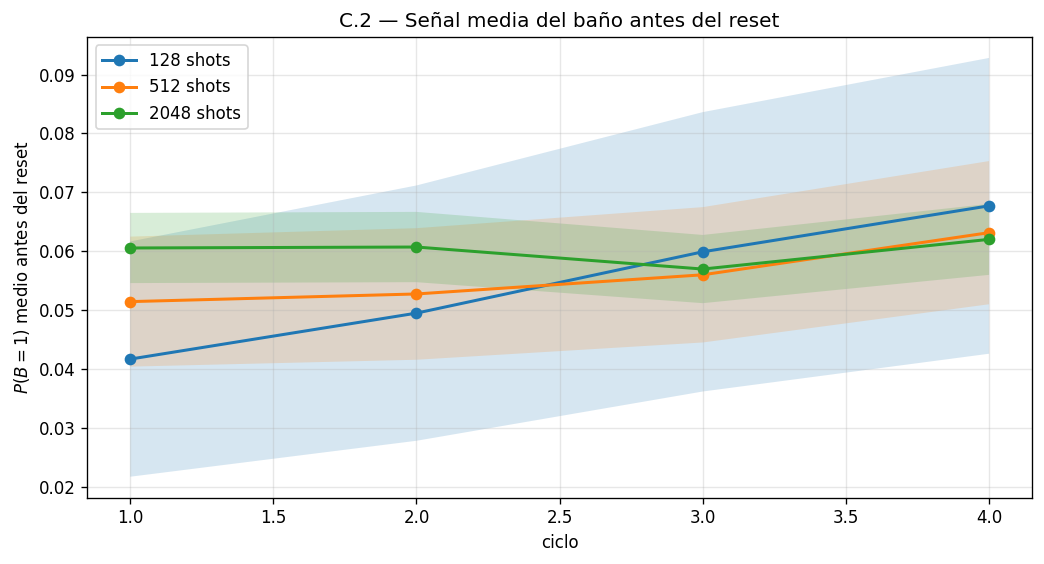

,shots,bath_p1_first,bath_p1_last,bath_p1_mean,mean_95ci_halfwidth
0,128,0.041667,0.067708,0.054688,0.022635
1,512,0.051432,0.063151,0.055827,0.011471
2,2048,0.060547,0.062012,0.060059,0.005940


In [7]:
# C.2 — Baño antes del reset por shots ideales (versión ligera y robusta)

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

shots_list_C2 = [128, 512, 2048]
n_cycles_C2 = min(4, params_C_base["n_cycles"])   # más ligero que usar todos
seed0_C2 = 1234

runs_C2_small = {}
rows_C2 = []

fig, ax = plt.subplots(figsize=(8.8, 4.8))
cycles_C2 = np.arange(1, n_cycles_C2 + 1)

for k, shots in enumerate(shots_list_C2):
    print(f"[C.2] shots={shots}")

    out = run_isa_dynamic_shots_ising(
        compiled_C_base,
        n_cycles=n_cycles_C2,
        shots=shots,
        init_mode="mm",
        sim_mode="ideal",
        final_basis=None,
        seed_base=seed0_C2 + 100*k,
        optimization_level=0,   # importante: más ligero
        backend_bundle=backend_bundle_C,
    )

    p = np.asarray(out["bath_p1_per_cycle"], dtype=float)

    # Error binomial aproximado del promedio sobre baths
    n_bath_C2 = compiled_C_base["cfg"].n_bath
    sigma = np.sqrt(np.maximum(p * (1.0 - p), 0.0) / (shots * n_bath_C2))

    runs_C2_small[shots] = {
        "p": p.copy(),
        "sigma": sigma.copy(),
    }

    ax.plot(
        cycles_C2,
        p,
        marker="o",
        lw=1.8,
        label=f"{shots} shots",
    )
    ax.fill_between(
        cycles_C2,
        p - 1.96 * sigma,
        p + 1.96 * sigma,
        alpha=0.18,
    )

    rows_C2.append({
        "shots": shots,
        "bath_p1_first": float(p[0]),
        "bath_p1_last": float(p[-1]),
        "bath_p1_mean": float(np.mean(p)),
        "mean_95ci_halfwidth": float(np.mean(1.96 * sigma)),
    })

    # liberar memoria
    del out
    gc.collect()

ax.set_xlabel("ciclo")
ax.set_ylabel(r"$P(B=1)$ medio antes del reset")
ax.set_title("C.2 — Señal media del baño antes del reset")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

df_C2 = pd.DataFrame(rows_C2)
display(df_C2.round(6))

## C.3 Energía total por shots: bases $Z$ y $X$

Para Ising,

$$
H_S=-J\sum_{\langle i,j\rangle}X_iX_j-g\sum_i Z_i.
$$

Por tanto, la energía no se obtiene con una única base de medida. Usamos dos estimadores de shots:

- base $Z$, para estimar $\langle Z_i\rangle$;
- base $X$, para estimar $\langle X_iX_j\rangle$.

Para evitar que la simulación dinámica ISA consuma demasiada memoria, en esta celda no volvemos a ejecutar el circuito completo. Tomamos el estado final ideal de la capa exacta y simulamos únicamente el muestreo de medidas. Así aislamos el error estadístico de shots del coste de transpilación/simulación.

[C.3] shots por base = 256
[C.3] shots por base = 1024
[C.3] shots por base = 4096
[C.3] shots por base = 8192


,shots_por_base,E_Z_mean,E_X_mean,E_total_mean,E_total_std,endian,E_exact_final,E_Gibbs,bias_shots_vs_exact,bias_exact_vs_Gibbs
0,256,-0.706836,-0.115674,-0.822510,0.124121,big,-0.824558,-2.456308,0.002048,1.63175
1,1024,-0.709521,-0.111670,-0.821191,0.053893,big,-0.824558,-2.456308,0.003367,1.63175
2,4096,-0.712054,-0.112643,-0.824698,0.030032,big,-0.824558,-2.456308,0.000140,1.63175
3,8192,-0.710394,-0.112044,-0.822438,0.020595,big,-0.824558,-2.456308,0.002120,1.63175


Comprobación endian: [(9.547918011776346e-15, 'big', -0.8245582131552613), (9.547918011776346e-15, 'little', -0.8245582131552613)]


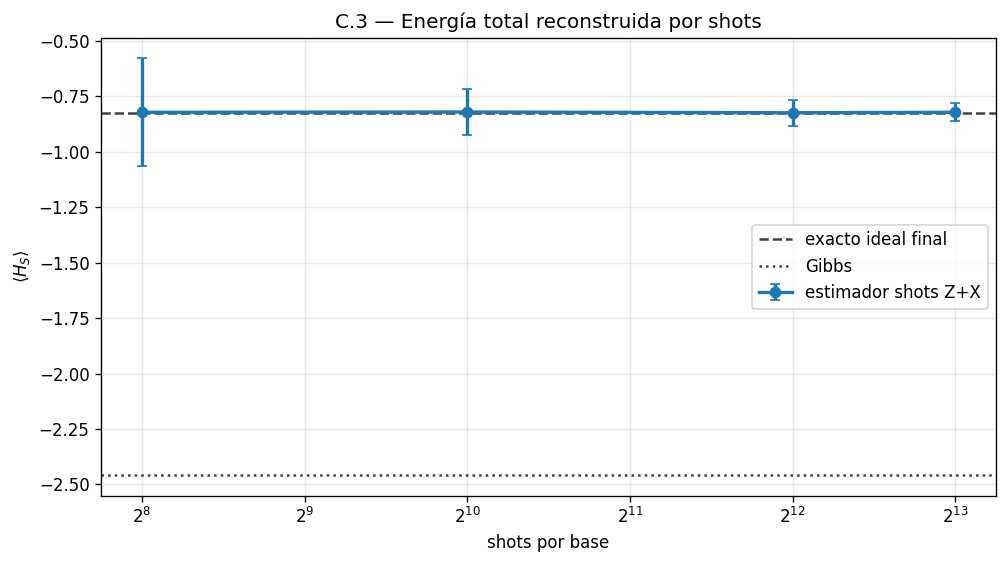

In [ ]:
# C.3 — Energía total por shots desde el estado final ideal exacto
# Versión segura: no ejecuta Aer ni transpila circuitos dinámicos.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tfm_shared.core import run_protocol_case, maximally_mixed, expect


# ------------------------------------------------------------
# Caso base C.3
# ------------------------------------------------------------

params_C3 = dict(params_C_base)
params_C3["n_cycles"] = min(6, params_C_base["n_cycles"])

# Usamos el cfg ya compilado en C.1.
cfg_C3 = compiled_C_base["cfg"]

out_exact_C3 = run_protocol_case(
    cfg_C3,
    rho0=maximally_mixed(cfg_C3.n_sys),
    compute_fp=False,
)

rho_final_C3 = out_exact_C3["res"]["rhos"][-1]
E_exact_final_C3 = float(expect(out_exact_C3["Hs"], rho_final_C3))
E_gibbs_C3 = float(expect(out_exact_C3["Hs"], out_exact_C3["rho_g"]))

shots_list_C3 = [256, 1024, 4096, 8192]

dfs_C3 = []
endian_info_C3 = None

for shots in shots_list_C3:
    print(f"[C.3] shots por base = {shots}")

    df_rep, endian_candidates = sample_energy_shots_C3(
        rho=rho_final_C3,
        cfg=cfg_C3,
        shots=shots,
        n_reps=80,
        seed=2025 + shots,
    )

    dfs_C3.append(df_rep)

    if endian_info_C3 is None:
        endian_info_C3 = endian_candidates

df_reps_C3 = pd.concat(dfs_C3, ignore_index=True)

df_C3 = (
    df_reps_C3
    .groupby("shots_por_base")
    .agg(
        E_Z_mean=("E_Z", "mean"),
        E_X_mean=("E_X", "mean"),
        E_total_mean=("E_total", "mean"),
        E_total_std=("E_total", "std"),
        endian=("endian", "first"),
    )
    .reset_index()
)

df_C3["E_exact_final"] = E_exact_final_C3
df_C3["E_Gibbs"] = E_gibbs_C3
df_C3["bias_shots_vs_exact"] = np.abs(df_C3["E_total_mean"] - E_exact_final_C3)
df_C3["bias_exact_vs_Gibbs"] = abs(E_exact_final_C3 - E_gibbs_C3)

display(df_C3.round(6))

print("Comprobación endian:", endian_info_C3)

fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.errorbar(
    df_C3["shots_por_base"],
    df_C3["E_total_mean"],
    yerr=1.96 * df_C3["E_total_std"],
    marker="o",
    lw=2,
    capsize=3,
    label="estimador shots Z+X",
)

ax.axhline(
    E_exact_final_C3,
    ls="--",
    color="k",
    alpha=0.75,
    label="exacto ideal final",
)

ax.axhline(
    E_gibbs_C3,
    ls=":",
    color="k",
    alpha=0.75,
    label="Gibbs",
)

ax.set_xscale("log", base=2)
ax.set_xlabel("shots por base")
ax.set_ylabel(r"$\langle H_S\rangle$")
ax.set_title("C.3 — Energía total reconstruida por shots")
ax.grid(alpha=0.3, which="both")
ax.legend()

plt.tight_layout()
plt.show()



La reconstrucción de la energía por shots requiere combinar dos bases de medida: la base $Z$ para la parte de campo y la base $X$ para los términos $X_iX_j$. Al aumentar el número de shots por base, la estimación converge hacia la energía exacta final.

La diferencia entre la energía final exacta y la energía Gibbs no procede del muestreo, sino del protocolo finito usado en el caso base. Por tanto, esta celda separa el error estadístico de medida del sesgo físico de preparación.

## C.4 Recursos dinámicos compactos

El barrido completo ISA para muchos tamaños puede tardar mucho porque cada punto requiere construir y transpilar un circuito dinámico con resets. Para evitar que el notebook sea inejecutable, aquí hacemos una estimación compacta de recursos lógicos.

Contamos profundidad, tamaño, medidas, resets y número de bloques unitarios para cadenas Ising 1D pequeñas y para Ising $2\times2$. La geometría hardware ya se analizó en C.0; esta celda mide el crecimiento estructural del circuito.

[C.4] Ising 1D N=2
[C.4] Ising 1D N=3
[C.4] Ising 1D N=4
[C.4] Ising 2D 2x2


,label,model,N_S,N_total_logical,n_cycles,MT,n_qubits,n_clbits,depth,size,unitary,measure,reset,twoq_like
0,Ising 1D N=2,Ising 1D,2,4,2,3,4,6,6,12,2,6,4,0
1,Ising 1D N=3,Ising 1D,3,6,2,3,6,9,6,17,2,9,6,0
2,Ising 1D N=4,Ising 1D,4,8,2,3,8,12,6,22,2,12,8,0
3,Ising 2D 2x2,Ising 2D,4,8,2,3,8,12,6,22,2,12,8,0


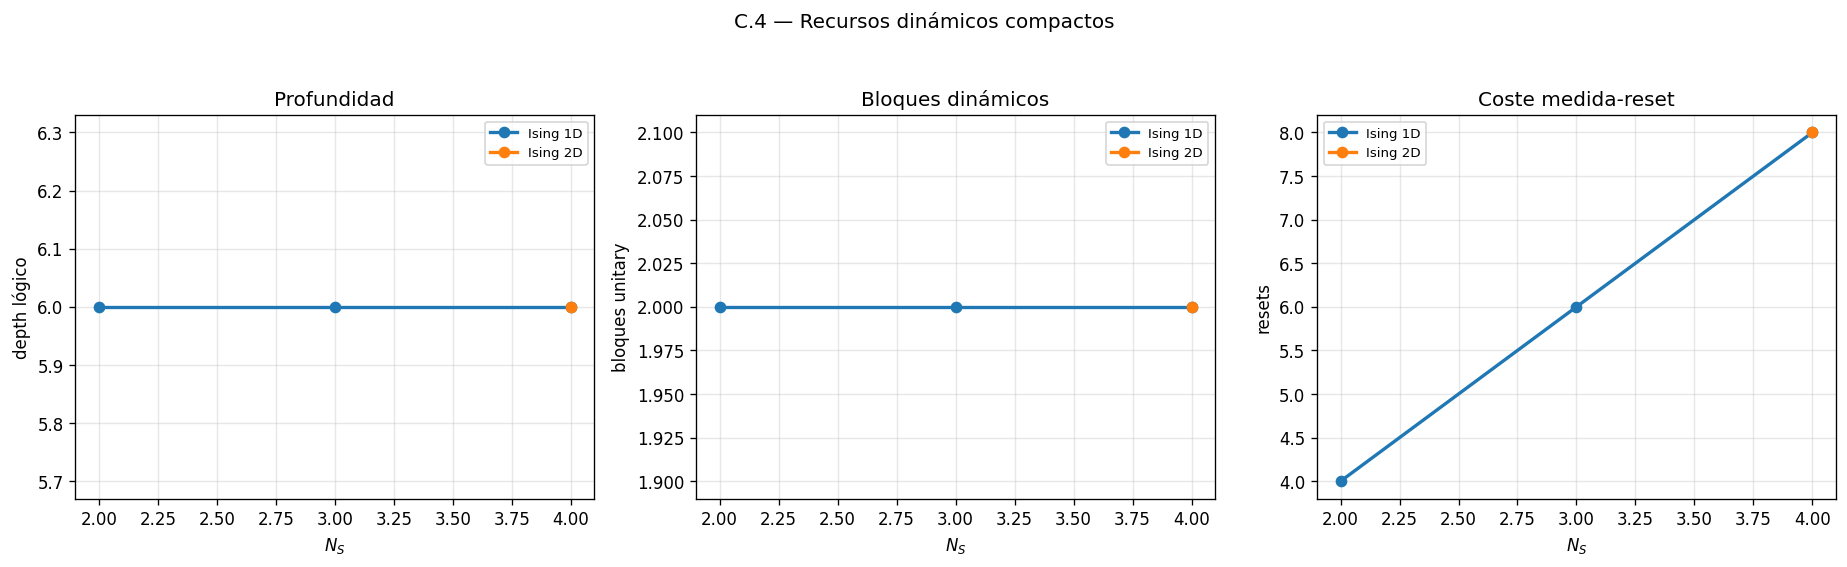

In [ ]:
# C.4 — Recursos dinámicos compactos sin retranspilar barridos ISA pesados

resource_cases_C4 = [
    ("Ising 1D N=2", "Ising 1D", make_params_C4_resource(2, 1, n_cycles=2, MT=3)),
    ("Ising 1D N=3", "Ising 1D", make_params_C4_resource(3, 1, n_cycles=2, MT=3)),
    ("Ising 1D N=4", "Ising 1D", make_params_C4_resource(4, 1, n_cycles=2, MT=3)),
    ("Ising 2D 2x2", "Ising 2D", make_params_C4_resource(2, 2, n_cycles=2, MT=3)),
]

rows_C4 = []

for label, model, params in resource_cases_C4:
    print(f"[C.4] {label}")

    cfg, compiled = make_compiled_ising(params)

    qc = build_dynamic_protocol_circuit_ising(
        compiled,
        n_cycles=params["n_cycles"],
        init_label="0" * cfg.n_sys,
        final_basis="Z",
    )

    rows_C4.append(
        circuit_resource_row_C4(
            qc,
            label=label,
            model=model,
            N_S=cfg.n_sys,
            n_cycles=params["n_cycles"],
            MT=params["MT"],
        )
    )

    del qc
    gc.collect()

df_C4 = pd.DataFrame(rows_C4)

display(df_C4[
    [
        "label",
        "model",
        "N_S",
        "N_total_logical",
        "n_cycles",
        "MT",
        "n_qubits",
        "n_clbits",
        "depth",
        "size",
        "unitary",
        "measure",
        "reset",
        "twoq_like",
    ]
])


fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))

for model, sub in df_C4.groupby("model"):
    sub = sub.sort_values("N_S")

    axes[0].plot(
        sub["N_S"],
        sub["depth"],
        "o-",
        lw=2,
        label=model,
    )

    axes[1].plot(
        sub["N_S"],
        sub["unitary"],
        "o-",
        lw=2,
        label=model,
    )

    axes[2].plot(
        sub["N_S"],
        sub["reset"],
        "o-",
        lw=2,
        label=model,
    )

axes[0].set_xlabel(r"$N_S$")
axes[0].set_ylabel("depth lógico")
axes[0].set_title("Profundidad")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_xlabel(r"$N_S$")
axes[1].set_ylabel("bloques unitary")
axes[1].set_title("Bloques dinámicos")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

axes[2].set_xlabel(r"$N_S$")
axes[2].set_ylabel("resets")
axes[2].set_title("Coste medida-reset")
axes[2].grid(alpha=0.3)
axes[2].legend(fontsize=8)

plt.suptitle("C.4 — Recursos dinámicos compactos", y=1.04)
plt.tight_layout()
plt.show()



El conteo compacto de recursos muestra que el coste dinámico crece rápidamente con el tamaño del sistema incluso antes de una transpilación ISA completa. El número de resets escala con el número de baños y ciclos, mientras que los bloques unitarios recogen el coste de aplicar el filtro térmico.

Esta sección no pretende predecir fidelidades ni costes calibrados de hardware. Su objetivo es mostrar la estructura de recursos del protocolo y justificar por qué los barridos físicos largos se mantienen en la capa exacta o gaussiana.

# D. Capa con ruido: circuito dinámico ideal vs noisy

En NB03 la capa con ruido debe responder una pregunta práctica: si el protocolo Ising ya funciona en la capa exacta y en Qiskit ideal, ¿la señal sigue siendo visible cuando ejecutamos el mismo circuito dinámico con un modelo de ruido calibrado del backend?

A diferencia de la capa exacta, aquí no buscamos caracterizar el canal físico completo ni optimizar parámetros. El objetivo es más limitado y comparable con NB01, NB02 y NB04:

1. ejecutar el mismo circuito dinámico en modo `ideal` y `noisy`;
2. comparar la energía reconstruida por shots;
3. comparar la señal del baño antes del reset;
4. relacionar la degradación con el coste del circuito.

Para Ising la energía total requiere dos bases de medida,

$$
H_S=-J\sum_{\langle i,j\rangle}X_iX_j-g\sum_i Z_i,
$$

por lo que en el spot-check pequeño reconstruimos la energía total combinando una pasada en base $Z$ y otra en base $X$. En el barrido compacto de escalado usamos además la parte diagonal $E_Z$ y la señal del baño como observables robustos y baratos, igual que en las capas shot-based de los otros notebooks.

## D.1 Ruido calibrado

Backend: FakeSherbrooke (snapshot calibraciones reales)
Noise model disponible: True

[D.1] sim_mode=ideal

[D.1] sim_mode=noisy


,mode,cycle,E_Z,E_X,E_total,bias_total,bath_last
0,ideal,1,-0.162109,-0.005859,-0.167969,1.439227,0.074219
1,ideal,2,-0.201172,0.009766,-0.191406,1.415790,0.089355
2,ideal,3,-0.238281,-0.003906,-0.242187,1.365009,0.067871
3,ideal,4,-0.294922,0.005859,-0.289063,1.318134,0.075195
4,noisy,1,-0.039063,-0.002930,-0.041992,1.565204,0.447266
5,noisy,2,-0.039063,0.021484,-0.017578,1.589618,0.471191
6,noisy,3,-0.019531,0.007813,-0.011719,1.595477,0.454102
7,noisy,4,0.029297,0.001953,0.031250,1.638446,0.441406


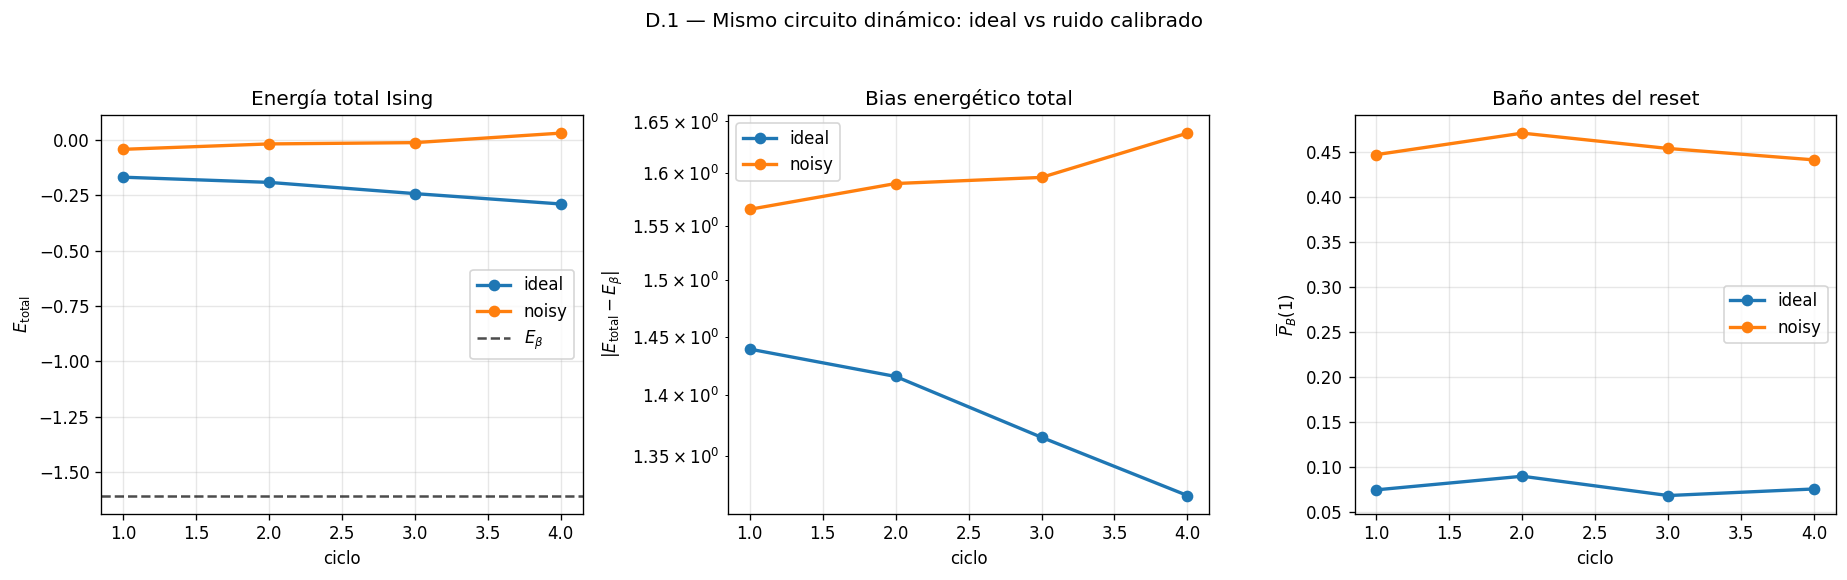

In [ ]:
# ============================================================
# D.1 — Ising con ruido calibrado: energía total por bases Z/X
# ============================================================
#
# Objetivo:
#   Comparar ideal vs noisy usando el MISMO circuito dinámico ISA.
#   Para Ising reconstruimos la energía total combinando:
#       - base Z para <Z_i>
#       - base X para <X_i X_j>
#
# Esta celda es deliberadamente pequeña para que sea ejecutable.




# ------------------------------------------------------------
# Caso pequeño para que noisy sea ejecutable
# ------------------------------------------------------------

params_D1 = dict(
    Lx=2,
    Ly=1,
    J=0.5,
    g=1.0,
    h=2.0,
    beta=1.0,
    theta=0.25,
    delta=np.pi / 40,
    MT=6,
    n_cycles=4,
    sys_A="Y",
    bath_A="Y",
    periodic=False,
    randomize=False,
    randomization_lambda=0.0,
    seed=1234,
    rewind=False,
)

_, compiled_D1 = make_compiled_ising(params_D1)

backend_bundle_D = get_ising_backend_bundle(
    min_total_qubits=2 * compiled_D1["cfg"].n_sys,
)

print("Backend:", backend_bundle_D["label"])
print("Noise model disponible:", backend_bundle_D["have_noise_model"])

rho_g_D1 = gibbs_state(compiled_D1["Hs_mat"], params_D1["beta"])
E_gibbs_D1 = float(expect(compiled_D1["Hs_mat"], rho_g_D1))

shots_D1 = 1024
cycles_D1 = list(range(1, params_D1["n_cycles"] + 1))

sim_modes_D1 = ["ideal"]
if backend_bundle_D["have_noise_model"]:
    sim_modes_D1.append("noisy")

rows_D1 = []

for sim_mode in sim_modes_D1:
    print(f"\n[D.1] sim_mode={sim_mode}")

    for ncyc in cycles_D1:
        out = run_ising_total_energy_shots_D(
            compiled_D1,
            n_cycles=ncyc,
            shots=shots_D1,
            init_mode="mm",
            sim_mode=sim_mode,
            seed_base=4000 + 100 * ncyc + (0 if sim_mode == "ideal" else 10_000),
            optimization_level=0,
            backend_bundle=backend_bundle_D,
        )

        rows_D1.append({
            "mode": sim_mode,
            "cycle": int(ncyc),
            "E_Z": out["E_Z"],
            "E_X": out["E_X"],
            "E_total": out["E_total"],
            "bias_total": abs(out["E_total"] - E_gibbs_D1),
            "bath_last": out["bath_p1_last"],
        })

        gc.collect()

df_D1_noise = pd.DataFrame(rows_D1)
display(df_D1_noise.round(6))

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

for mode, sub in df_D1_noise.groupby("mode"):
    sub = sub.sort_values("cycle")

    axes[0].plot(
        sub["cycle"],
        sub["E_total"],
        "o-",
        lw=2,
        label=mode,
    )

    axes[1].semilogy(
        sub["cycle"],
        sub["bias_total"],
        "o-",
        lw=2,
        label=mode,
    )

    axes[2].plot(
        sub["cycle"],
        sub["bath_last"],
        "o-",
        lw=2,
        label=mode,
    )

axes[0].axhline(E_gibbs_D1, ls="--", color="k", alpha=0.7, label=r"$E_\beta$")
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel(r"$E_{\rm total}$")
axes[0].set_title("Energía total Ising")

axes[1].set_xlabel("ciclo")
axes[1].set_ylabel(r"$|E_{\rm total}-E_\beta|$")
axes[1].set_title("Bias energético total")

axes[2].set_xlabel("ciclo")
axes[2].set_ylabel(r"$\overline{P}_B(1)$")
axes[2].set_title("Baño antes del reset")

for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("D.1 — Mismo circuito dinámico: ideal vs ruido calibrado", y=1.04)
plt.tight_layout()
plt.show()

## D.2 Ruido artificial

Modelamos el efecto acumulado del ruido como una despolarización efectiva por ciclo. No pretende reproducir un backend puerta a puerta, sino estimar la frontera de tolerancia: cuánto ruido por ciclo puede añadirse antes de que el error domine sobre el sesgo ideal del protocolo.

,p_eff_per_cycle,p_total_equiv,E_final_noisy,bias_E,bias_E_per_site,D_to_Gibbs,extra_bias_vs_ideal
0,0.000000,0.000000,-3.323139,0.111467,0.027867,0.044816,0.000000
1,0.000010,0.000600,-3.321146,0.113460,0.028365,0.045069,0.001993
2,0.000015,0.000880,-3.320214,0.114392,0.028598,0.045187,0.002925
3,0.000022,0.001292,-3.318846,0.115760,0.028940,0.045360,0.004293
4,0.000032,0.001896,-3.316840,0.117766,0.029441,0.045615,0.006299
5,0.000046,0.002781,-3.313897,0.120709,0.030177,0.045989,0.009242
6,0.000068,0.004080,-3.309582,0.125023,0.031256,0.046582,0.013557
7,0.000100,0.005982,-3.303259,0.131347,0.032837,0.047475,0.019880
8,0.000147,0.008769,-3.293999,0.140606,0.035152,0.048784,0.029140
9,0.000215,0.012845,-3.280454,0.154152,0.038538,0.050698,0.042685


bias ideal = 0.11146655617745838
p_eff umbral aproximado para duplicar bias = 0.0006812920690579609


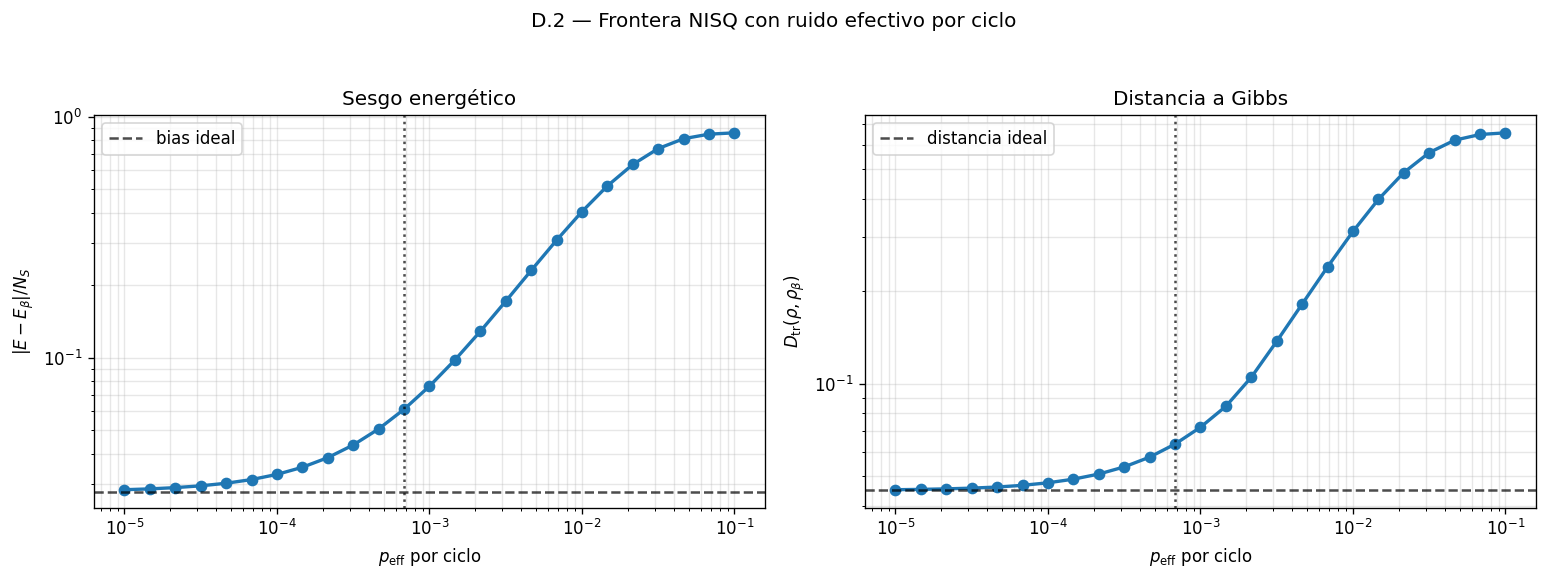

In [19]:
# D.2 — Bias vs ruido efectivo por ciclo

def depolarize_dm(rho, p):
    d = rho.shape[0]
    return (1.0 - p) * rho + p * np.eye(d, dtype=complex) / d


def effective_depol_after_cycles(rho_ideal_final, p_eff, n_cycles):
    """
    Modelo fenomenológico:
        rho_noisy ≈ (1-p_eff)^n rho_ideal + [1-(1-p_eff)^n] I/d
    """
    d = rho_ideal_final.shape[0]
    q = (1.0 - float(p_eff)) ** int(n_cycles)
    return q * rho_ideal_final + (1.0 - q) * np.eye(d, dtype=complex) / d


p_eff_list_D2 = np.concatenate([
    [0.0],
    np.logspace(-5, -1, 25),
])

rows_D2 = []

for p_eff in p_eff_list_D2:
    rho_eff = effective_depol_after_cycles(
        rho_final_D,
        p_eff=p_eff,
        n_cycles=params_D_base["n_cycles"],
    )

    E_eff = float(expect(Hs_D, rho_eff))
    D_eff = float(trace_distance_dm(rho_eff, rho_g_D))

    rows_D2.append({
        "p_eff_per_cycle": float(p_eff),
        "p_total_equiv": float(1.0 - (1.0 - p_eff) ** params_D_base["n_cycles"]),
        "E_final_noisy": E_eff,
        "bias_E": abs(E_eff - E_g_D),
        "bias_E_per_site": abs(E_eff - E_g_D) / compiled_D_base["cfg"].n_sys,
        "D_to_Gibbs": D_eff,
        "extra_bias_vs_ideal": abs(E_eff - E_g_D) - abs(E_final_D - E_g_D),
    })

df_D2 = pd.DataFrame(rows_D2)

display(df_D2.round(8))

# Umbral aproximado: cuando el bias energético duplica el ideal
ideal_bias_D = abs(E_final_D - E_g_D)

df_pos_D2 = df_D2[df_D2["p_eff_per_cycle"] > 0].copy()
above = df_pos_D2[df_pos_D2["bias_E"] >= 2.0 * ideal_bias_D]

if len(above) > 0:
    p_threshold_D2 = above.iloc[0]["p_eff_per_cycle"]
else:
    p_threshold_D2 = np.nan

print("bias ideal =", ideal_bias_D)
print("p_eff umbral aproximado para duplicar bias =", p_threshold_D2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

df_plot_D2 = df_D2[df_D2["p_eff_per_cycle"] > 0]

axes[0].loglog(
    df_plot_D2["p_eff_per_cycle"],
    df_plot_D2["bias_E_per_site"],
    "o-",
    lw=2,
)
axes[0].axhline(
    ideal_bias_D / compiled_D_base["cfg"].n_sys,
    ls="--",
    color="k",
    alpha=0.7,
    label="bias ideal",
)
if np.isfinite(p_threshold_D2):
    axes[0].axvline(p_threshold_D2, ls=":", color="k", alpha=0.7)
axes[0].set_xlabel(r"$p_{\rm eff}$ por ciclo")
axes[0].set_ylabel(r"$|E-E_\beta|/N_S$")
axes[0].set_title("Sesgo energético")
axes[0].grid(alpha=0.3, which="both")
axes[0].legend()

axes[1].loglog(
    df_plot_D2["p_eff_per_cycle"],
    df_plot_D2["D_to_Gibbs"],
    "o-",
    lw=2,
)
axes[1].axhline(
    trace_distance_dm(rho_final_D, rho_g_D),
    ls="--",
    color="k",
    alpha=0.7,
    label="distancia ideal",
)
if np.isfinite(p_threshold_D2):
    axes[1].axvline(p_threshold_D2, ls=":", color="k", alpha=0.7)
axes[1].set_xlabel(r"$p_{\rm eff}$ por ciclo")
axes[1].set_ylabel(r"$D_{\rm tr}(\rho,\rho_\beta)$")
axes[1].set_title("Distancia a Gibbs")
axes[1].grid(alpha=0.3, which="both")
axes[1].legend()

plt.suptitle("D.2 — Frontera NISQ con ruido efectivo por ciclo", y=1.04)
plt.tight_layout()
plt.show()

# E. Conclusiones

En este notebook se ha estudiado el protocolo térmico tipo Lloyd-Abanin aplicado al modelo de Ising cuántico en 1D y 2D. La capa exacta permite separar los distintos efectos físicos y numéricos: convergencia hacia el estado de Gibbs, dependencia con la geometría, sensibilidad a resonancias, efecto de la randomización y coste asociado al número de ciclos y pasos internos.

Los resultados muestran que el protocolo reproduce correctamente una dinámica de termalización efectiva cuando los parámetros del baño y del acoplo se escogen en un régimen no resonante. En particular, la comparación entre cadenas 1D y redes 2D muestra que la geometría modifica tanto el espectro como las escalas de mezcla, pero no cambia la estructura general del protocolo: el sistema se acerca a Gibbs mediante interacciones repetidas con baños auxiliares reinicializados.

También se observa que la randomización puede suavizar resonancias y reducir oscilaciones no deseadas, aunque no garantiza una mejora universal. En el análisis de tiempo de mezcla no se encuentra una señal robusta de efecto Mpemba para los casos estudiados; más bien, la relajación parece estar dominada por el acoplo, la estructura espectral y el régimen de parámetros elegido.

En la parte Qiskit se traduce el protocolo a circuitos dinámicos con medidas y resets, lo que permite estimar el coste de implementación en términos de profundidad, número de puertas, qubits auxiliares y shots. La estimación de energía requiere medir en bases complementarias, ya que el Hamiltoniano de Ising contiene tanto términos diagonales en $Z$ como acoplos $XX$.

Finalmente, el análisis de ruido efectivo muestra que el error energético crece rápidamente al introducir una despolarización acumulada por ciclo. Este estudio no pretende reproducir un backend real puerta a puerta, sino dar una cota fenomenológica de tolerancia: para que el protocolo sea útil en hardware NISQ, el ruido efectivo por ciclo debe mantenerse por debajo de la escala en la que domina sobre el sesgo ideal del protocolo.

En conjunto, el notebook valida la coherencia física del protocolo para Ising, identifica sus principales limitaciones prácticas y conecta la simulación exacta con una estimación razonable de recursos y sensibilidad al ruido en una implementación cuántica dinámica.